# **AS-IS Processs — 3LoD Scenario for a Suspicious Transaction Case**

The AS-IS simulation demonstrates that while roles are formally separated, capability asymmetry emerges due to restricted data visibility.

## **Definition of Suspiciousness Labels**

In this research, I create suspicious levels in the three levels—low, medium, and high—based on the degree of deviation from historical transaction behavior and the customer's profile, rather than on absolute transaction values or as confirmation of fraud. These levels represent early operational risk signals and are used to support grouping, review, and escalation within the Three Lines of Defense. The definitions applied to each level of suspiciousness are summarized below:


### **Table 1. Definition of Suspiciousness Labels Based on Deviation from Customer-Specific Historical & Profile Base line Baselines**

| Suspiciousness Label | Definition                                                                                                                                                                 | Deviation Logic (Conceptual)                                                                                                              | Operational Implication                                                                  |
| -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Low**              | Transaction behavior remains consistent with the customer’s historical transaction patterns and reflects normal operational variation for the customer profile.            | Minor or no deviation from the customer-specific historical transaction baseline, interpreted within the context of the customer profile. | No escalation required. Transaction treated as normal operational activity.              |
| **Medium**           | Transaction behavior shows a noticeable deviation from historical patterns but may still be explainable by business or contextual factors related to the customer profile. | Moderate deviation from the customer-specific historical baseline, indicating a potential early risk signal.                              | Requires increased attention or monitoring by the first line. Escalation is conditional. |
| **High**             | Transaction behavior exhibits an extreme and unusual deviation from historical patterns that is unlikely to represent normal variation for the given customer profile.     | Significant deviation from the customer-specific historical baseline, indicating elevated risk.                                           | Triggers escalation to the second line for independent review and risk assessment.       |


## **Definition of Suspiciousness Labels**

In this research, I create suspicious levels in the three levels—low, medium, and high—based on the degree of deviation from historical transaction behavior and the customer's profile, rather than on absolute transaction values or as confirmation of fraud. These levels represent early operational risk signals and are used to support grouping, review, and escalation within the Three Lines of Defense. The definitions applied to each level of suspiciousness are summarized below:


### **Table 1. Definition of Suspiciousness Labels Based on Deviation from Customer-Specific Historical & Profile Base line Baselines**

| Suspiciousness Label | Definition                                                                                                                                                                 | Deviation Logic (Conceptual)                                                                                                              | Operational Implication                                                                  |
| -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Low**              | Transaction behavior remains consistent with the customer’s historical transaction patterns and reflects normal operational variation for the customer profile.            | Minor or no deviation from the customer-specific historical transaction baseline, interpreted within the context of the customer profile. | No escalation required. Transaction treated as normal operational activity.              |
| **Medium**           | Transaction behavior shows a noticeable deviation from historical patterns but may still be explainable by business or contextual factors related to the customer profile. | Moderate deviation from the customer-specific historical baseline, indicating a potential early risk signal.                              | Requires increased attention or monitoring by the first line. Escalation is conditional. |
| **High**             | Transaction behavior exhibits an extreme and unusual deviation from historical patterns that is unlikely to represent normal variation for the given customer profile.     | Significant deviation from the customer-specific historical baseline, indicating elevated risk.                                           | Triggers escalation to the second line for independent review and risk assessment.       |


## **Operational Thresholds for Suspiciousness Labels**

### **Table 2. Threshold Definition for Mapping Deviations to Suspiciousness Levels**

| Dimension                            | Metric                                                                      | Baseline Definition                               | Threshold Logic            | Notes                                                                                                             |
| ------------------------------------ | --------------------------------------------------------------------------- | ------------------------------------------------- | -------------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **Transaction Frequency (Velocity)** | Ratio of daily transaction count to customer historical daily average       | Customer-specific historical transaction behavior | ≤ 1.2× / 1.2–2.0× / > 2.0× | Threshold interpretation is contextualized by customer profile (e.g., customer segment, product characteristics). |
| **Transaction Amount (Value)**       | Ratio of daily or monthly transaction amount to customer historical average | Customer-specific historical transaction behavior | ≤ 1.2× / 1.2–2.0× / > 2.0× | Baseline reflects transaction sizes that are typical for the customer profile.                                    |


**Note:**

Baselines are calculated using customer-specific historical transaction data. Customer profiles are used to contextualize the interpretation of deviations, rather than to define separate numerical baselines or thresholds. The thresholds presented are illustrative and intended to support transparent and explainable risk labeling.  The Heuristic threshold 1.2 is based on 20% operational variance, which means the transaction is within risk appetite for the customer profil tolerance.

## **Methodology (Step by Step) For Grouping & Labeling of Suspicious Transactions**

This study adopts a simple, deviation-based approach to illustrate how suspiciousness labels are generated and propagated within the Three Lines of Defense (3LoD). The objective is governance transparency and interpretability rather than detection accuracy.

### **Step 1 — Transaction Grouping**

The input data consist of transaction-level records (one row per `txn_id`). Transactions are aggregated to the **customer-day** level to capture velocity-based anomalies.

For each `client_id` and `date`, the following daily indicators are computed:

**1) Daily transaction frequency (velocity)**  

`daily_txn_count = number of transactions per customer per day`


- **Formula:**

$$
daily\_txn\_count_{i,t} = \#(\text{transactions of customer } i \text{ on day } t)
$$



**2) Daily transaction value (amount)**  

`daily_total_amount = sum of amount_eur per customer per day`

- **Formula:**

$$
daily\_total\_amount_{i,t} = \sum(\text{amount\_eur of customer } i \text{ on day } t)
$$

**3) (Optional) Daily average amount**  

`daily_avg_amount = daily_total_amount / daily_txn_count`

- **Formula:**

$$
daily\_avg\_amount_{i,t} = \frac{daily\_total\_amount_{i,t}}{daily\_txn\_count_{i,t}}
$$


**Rationale:** Velocity spikes are most visible at the daily aggregation level.

### **Step 2 — Customer-Specific Historical Baselines**

For each customer $i$, a historical baseline is calculated from prior observations to represent the customer’s “normal” behavior. Two baselines are defined:

**1) Baseline daily frequency**  

`baseline_txn_count = historical average of daily_txn_count`
  
- **Formula:**

$$ baseline\_txn\_count_{i,t} = \text{historical average of } daily\_txn\_count_{i,\tau} \text{ for } \tau < t
$$

**2) Baseline daily amount**  

- `baseline_total_amount = historical average of daily_total_amount`

- **Formula:**
$$
baseline\_total\_amount_{i,t} = \text{historical average of } daily\_total\_amount_{i,\tau} \text{ for } \tau < t
$$


Baselines may be calculated using:
- rolling windows (e.g., last 30 days), or
- expanding historical means.

To avoid look-ahead bias, baselines are computed using **historical data only**, excluding the current day $t$.

### **Step 3 — Deviation Ratios**

Deviation from historical behavior is expressed as ratios:

**1) Velocity ratio**  

`ratio_velocity = daily_txn_count / baseline_txn_count`

- **Formula:**
$$
ratio\_velocity_{i,t} = \frac{daily\_txn\_count_{i,t}}{baseline\_txn\_count_{i,t}}
$$

**2) Value ratio**  

`ratio_value = daily_total_amount / baseline_total_amount`

- **Formula:**
$$
ratio\_value_{i,t} = \frac{daily\_total\_amount_{i,t}}{baseline\_total\_amount_{i,t}}
$$

These ratios serve as interpretable, deviation-based indicators for subsequent grouping.

### **Step 4 — Deviation Grouping**

Each ratio is mapped into one of three deviation groups:

| Ratio vs Baseline | Deviation Group | Risk Significance | Operational Action |
|-------------------|-----------------|-------------------|--------------------|
| ≤ 1.2× | Normal | Within Risk Appetite | Logged as standard behavioral noise.|
| > 1.2× and ≤ 2.0× | Elevated | Needs Monitoring | Flagged for periodic review and trend analysis.|
| > 2.0× | Significant | Critical Deviation |Trigger for immediate escalation and investigation.|


Grouping is applied separately to velocity and value.

- Velocity -> ``velocity_severity``

- Value -> ``value_severity``

#### **Threshold Assumption and Rationale**

I define thresholds within the ranges of ≤1.2, 1.2–2.0, and >2.0, and these are not universal AML thresholds. These thresholds were intentionally chosen as simple and easily interpreted ranges to operationalize the concept of transaction deviations labeled as normal, high, and significant in simulated suspicious transaction scenarios with a focus on governance.

This thesis does not aim to optimize suspicious transaction detection accuracy, but rather to demonstrate traceable labeling, review, and escalation across the Three Lines of Defense in operational activity related to suspicious transactions. Because deviations are calculated relative to a customer-specific historical baseline (per customer), rather than population transaction data, this approach adapts to the typical activity level of each customer in a given retail sample (subject to data availability).

#### **Business Interpretation of Thresholds**

The selected ranges reflect increasing levels of operational attention. Small day-to-day variations (approximately ±20%) are commonly observed in routine transaction behavior and are therefore treated as operational noise. Deviations between 20% and 100% represent material changes that can still be explained by business or contextual factors. Deviations exceeding 100% indicate significant behavioral changes that are rare under steady-state conditions and therefore require escalation.

Because the deviation ratio is calculated at the individual customer level rather than across the entire customer population, small fluctuations are interpreted as within-customer variability rather than as a risk signal. In this study, deviations up to approximately 20% from a customer's historical baseline are assumed to reflect normal transactional noise. Therefore, a ratio threshold of 1.2× is used to define normal behavior, while higher ratios indicate an increased level of concern.

This deviation ratio approach emphasizes the importance of interpretability and robustness within a governance-focused environment. We did not use distribution-based statistical methods, such as percentiles or interquartile ranges (IQRs), as the main labeling mechanism because they can lead to instability when there are limited or uneven historical observations for each customer. Therefore, these methods are more appropriate for sensitivity analysis than for core operationalization in this context.

To assess robustness, alternative tolerance margins (e.g., 30%) are also considered. These margins represent a wider range of normal operational variability than the data proportions. As result, patterns label and governance conclusions remain consistent under this reasonable variation. Overall, fixed thresholds are used because the goal is transparent governance modeling, not statistical optimality. Thresholds are applied at the customer level, interpretations are prioritized, and robustness is verified through alternative assumptions.

#### **Illustrative Examples: Application of Tolerance Margins at the Customer Level**

Below, I will illustrate how thresholds are set for each individual customer case (e.g., 20% and 30%) to distinguish normal operational variability from meaningful deviations. These examples aim to clarify that tolerance limits represent the acceptable range of deviations around the customer's historical baseline, not data proportions, sampling assumptions, or statistical threshold rules.

The customer's profile and transactions case below are presented as examples of two customers with distinct profile and transaction patterns.

| Dimension | Customer A (Stable Pattern) | Customer B (Irregular Pattern) |
|--------|-----------------------------|--------------------------------|
| Customer profile | Retail, relatively stable behavior | Retail, higher historical variability |
| Historical avg. daily transaction count | 10 | 10 |
| Historical avg. daily transaction value (€) | 200 | 200 |
| Observed daily transaction count | 12 | 13 |
| Observed daily transaction value (€) | 215 | 240 |
| Velocity ratio | 1.20 | 1.30 |
| Value ratio | 1.08 | 1.20 |
| Tolerance margin applied | 20% | 20% |
| Interpretation | Normal operational variability | Deviation exceeds tolerance |
| Assigned suspiciousness label | Low | Medium |
| Escalation required | No | Conditional |


Interpretation using a 30% tolerance margin (robustness check)
When a wider tolerance margin is applied, the observed deviation remains within the acceptable range of normal variability for this customer. With these alternative tolerance margins, the same behavior would not trigger an escalation and will assigned label as Low Suspicion

This comparison illustrates how alternative tolerance assumptions can accommodate customers with inherently irregular transaction patterns without changing the governance structure or underlying labeling logic.

### **Methodological Interpretation for two different customers' cases**

These examples demonstrate that the tolerance margin defines how much deviation from a customer's historical baseline is considered normal operational variability, rather than how the data is statistically partitioned or sampled.

Although socio-demographic attributes such as occupation are not available in the dataset, the customer profiles in this study are operationally defined using observed transaction behavior, product relationships, and historical variability. This approach is used to illustrate common governance and auditing practices, in which deviations are assessed relative to the customer's historical behavior rather than inferred from external characteristics.

As a result, even though the deviation ratio appears higher in absolute terms for Customer B than for Customer A, the interpretation may differ between customers due to differences in behavioral patterns and the breakdown of variability. The labeling logic itself must remain consistent across all customers. Meanwhile, data interpretation and follow-up actions are contextualized within the Three Lines of Defense framework using a human judgment approach. This approach reduces the risk of misclassifying normal but unusual behavior as suspicious while maintaining traceability, transparency, and governance integrity.

In the area of Governance, Risk, and Compliance (GRC), the most important factor is informed, accountable, and responsible human judgment in fulfilling their roles. This assessment should be carried out using a clear, documented, and transparent methodology, rather than relying solely on isolated numerical metrics.

in this case, quantitative indicators can serve as a tool to support decision-making, but the results depend on human interpretation, escalation, and risk management responsibilities fall to the relevant functions within the GRC framework. This approach enables the implementation of controls that are proportionate to the level of risk and aligned with the organization's risk appetite and risk controls, as well as applicable regulatory requirements, while avoiding unnecessary disruption to business and operational processes.

> EBA AML Guidelines -> risk-based assessment with documented rationale

> GDPR Art. 22 -> human review for automated decisions

> DORA -> human oversight over ICT risk & monitoring

> IIA Europe -> professional judgment in assurance & governance


### **Step 5 — Mapping to Suspiciousness Labels**

Final suspiciousness labels are derived as follows:

- **High**: at least one dimension is *Significant*
- **Medium**: no *Significant*, but at least one *Elevated*
- **Low**: both dimensions are *Normal*

| Velocity Group | Value Group | Suspiciousness Label |
|---------------|-------------|----------------------|
| Normal | Normal | Low |
| Elevated | Normal | Medium |
| Normal | Elevated | Medium |
| Elevated | Elevated | Medium |
| Significant | Any | High |
| Any | Significant | High |

**Interpretation:** Labels represent early operational risk signals and do not confirm fraud or suspicious activity.

### **Transaction-Level Assignment**

Although labels are generated at the customer-day level, they can be propagated back to transaction-level records using (`client_id`, `date`) joins.

### **Baseline Availability**

For customers with insufficient historical data, labeling is deferred or defaulted to low suspiciousness until an adequate baseline is established.


## **Example Grouping and Labeling of Suspicious Transactions (Illustration Condition)**


### **Table 3. Illustrative Examples of Grouping and Labeling Based on Deviation from Customer-Specific Baselines**

| Case | Customer Type (Profile Context)      | Baseline Daily Txn Count | Baseline Daily Amount (€) | Observed Daily Txn Count | Observed Daily Amount (€) | Velocity Ratio | Value Ratio | Velocity Group | Value Group | Final Suspiciousness Label | Interpretation                                                                               |
| ---- | ------------------------------------ | ------------------------ | ------------------------- | ------------------------ | ------------------------- | -------------- | ----------- | -------------- | ----------- | -------------------------- | -------------------------------------------------------------------------------------------- |
| A    | Retail customer (low activity)       | 10                       | 200                       | 11                       | 210                       | 1.10×          | 1.05×       | Normal         | Normal      | **Low**                    | Transaction behavior remains within normal historical variation.                             |
| B    | Retail customer (stable profile)     | 10                       | 200                       | 17                       | 220                       | 1.70×          | 1.10×       | Elevated       | Normal      | **Medium**                 | Increase in transaction frequency but total value remains within expected range.             |
| C    | Retail customer                      | 10                       | 200                       | 30                       | 260                       | 3.00×          | 1.30×       | Significant    | Elevated    | **High**                   | Sudden and extreme increase in transaction frequency indicates elevated operational risk.    |
| D    | Retail customer (low volume)         | 4                        | 80                        | 5                        | 220                       | 1.25×          | 2.75×       | Elevated       | Significant | **High**                   | Transaction amount deviates significantly from historical behavior despite modest frequency. |

**Note:**

1. In this case, we only focus on **retail customer** which label in the dataset as **Private Segment**.
2. The illustration above demonstrates how transaction data is **grouped and mapped to suspicious labels** based on deviations from customer-specific historical benchmarks. **Customer profiles are used to interpret the case contextually but do not amend the applied numerical thresholds.**

## **References:**

Ali, A., Abd Razak, S., Othman, S. H., Eisa, T. A. E., Al-Dhaqm, A., Nasser, M., Elhassan, T., Elshafie, H., & Saif, A. (2022). Financial fraud detection based on machine learning: A systematic literature review. Applied Sciences, 12(19), 9637.

Gowhor, H. S. (2024). Effectiveness criteria of suspicious transaction reporting for early detection of terrorist financing activities. Journal of Financial Crime.

Koo, K., Park, M., & Yoon, B. (2024). A suspicious financial transaction detection model using autoencoder and risk-based approach. IEEE Access, 12, 68926–68939.

Pranavi, P., Manognasri, C., Sreekaree, P. S., & Ramana, A. V. (2025, August). Fraud detection in financial transactions with AI&ML. In 2025 World Skills Conference on Universal Data Analytics and Sciences (WorldSUAS). IEEE.

Reite, E. J., Oust, A., Bang, R. M., & Maurstad, S. (2023). Changes in credit score, transaction volume, customer characteristics, and the probability of detecting suspicious transactions. Journal of Money Laundering Control, 26(6), 1165–1182.

Wang, Y., Liu, Y., Wang, N., Li, P., Hu, J., Fu, X., Wang, W., Sun, K., Li, Q., & Xu, K. (2024, June). Enhancing fraud transaction detection via unlabeled suspicious records. In 2024 IEEE/ACM 32nd International Symposium on Quality of Service (IWQoS). IEEE.

 https://www.deloitte.com/kz/en/services/risk-advisory/analysis/3lod.html

## **AS-IS GRC Simulation — Three Lines of Defense (3LoD)**

This notebook simulates an AS-IS Governance, Risk, and Compliance (GRC) workflow
based on the Three Lines of Defense model.

The objective is NOT to optimize fraud detection accuracy,
but to demonstrate:
- role separation,
- data silos,
- information flow limitations,
- and governance inefficiencies
in handling suspicious transaction cases.

All detection logic is intentionally simple and explainable.


## **Data Model**

1. customers — master data (type, group, language, KYC dates).
    
2. transactions — dated ledger-like events; optional MCC/merchant country for card purchases.
    
3. life_insurance — insured amount, scheduled payment, status codes.
    
4. property_insurance — type E/P, premium, repurchase value, status.
    
5. leasing_agreements — amounts and contract lifecycle status.
    
6. margin_assets / margin_liabilities — monthly balances & interest bases.
    
7. pension — contributions by fund and status.

## **Access Folder and Create Dataframe**

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
dataframes = {}

# Specify the folder path
folder_path = r'D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/'
for file in os.listdir(folder_path):
    if file.lower().endswith('.csv'):
        df_name = file.replace('.csv', '')
        full_path = os.path.join(folder_path, file)
        dataframes[df_name] = pd.read_csv(full_path)


## **Data Dictionary for Customers Table**

| Field           | Description                                                              |
| --------------- | ------------------------------------------------------------------------ |
| bank_reg_dt     | Date the customer was registered / activated in the bank                 |
| birth_dt        | Birth date for private customers; legal registration date for corporates |
| client_id       | Primary key for the customer master record                               |       |
| gender_cd       | M / F / U (unknown or undisclosed)                                       |
| group_head_flg  | **Codes:** 1 = parent company (group head), 0 = child / subsidiary       |
| lang_pref       | Interface / communication language code (e.g., EN, ET, LV, LT, RU, DE)   |
| postal_code     | ZIP / Postal code of the customer’s address                              |
| segment         | High-level segment: Corporate / SME / Private                            |
| type_cd         | **Codes:** C = Corporate, H = Private (household / retail)               |


In [3]:
# accessing dataframe customers

customers = dataframes['customers']

customer = customers.copy() #to duplicate original customer data

customers.head()

,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,postal_code,bank_reg_dt
0,CUST000001,H,Private,Parent,1977-11-19,M,EE,13075,2022-10-11
1,CUST000002,H,Private,Parent,1998-10-13,F,EE,81847,2018-05-18
2,CUST000003,H,Private,Parent,1971-09-07,F,EN,86527,2016-10-25
3,CUST000004,H,Private,Parent,1968-04-01,F,RU,13324,2023-10-15
4,CUST000005,H,Private,Parent,2006-08-15,F,RU,41926,2024-12-18


## **Customer Base Profile**

### - **Basic Data Information Customers**

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   client_id       10000 non-null  object
 1   type_cd         10000 non-null  object
 2   segment         10000 non-null  object
 3   group_head_flg  10000 non-null  object
 4   birth_dt        10000 non-null  object
 5   gender_cd       10000 non-null  object
 6   lang_pref       10000 non-null  object
 7   postal_code     10000 non-null  int64 
 8   bank_reg_dt     10000 non-null  object
dtypes: int64(1), object(8)
memory usage: 703.2+ KB


In [5]:
customers.shape

(10000, 9)

In [6]:
# Descriptive statistics for numerical
customers.describe(include= [np.number])

,postal_code
count,10000.000000
mean,48629.488900
std,29181.841272
min,10001.000000
25%,13146.750000
50%,51665.000000
75%,75046.750000
max,94995.000000


In [7]:
# Descriptive statistics for non-numerical
customers.describe(include='object')

,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,bank_reg_dt
count,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,1,1,1,7594,2,3,3967
top,CUST000001,H,Private,Parent,2006-04-18,F,EE,2024-12-28
freq,1,10000,10000,10000,6,5162,7350,20


In [8]:
customers.columns

Index(['client_id', 'type_cd', 'segment', 'group_head_flg', 'birth_dt',
       'gender_cd', 'lang_pref', 'postal_code', 'bank_reg_dt'],
      dtype='object')

### - **Checking & Handing Duplicate Values**

In [9]:
#check how many Duplicate value in each row

duplicate_counts = customers[customers.duplicated(keep=False)].value_counts()
print(duplicate_counts)

Series([], Name: count, dtype: int64)


**There is no duplicate value in the dataset**

### - **Checking & Handing Missing Values**

In [10]:
# check NA in each row
nan_rows = customers.isna().any(axis=1)
print("NA in rows information:")
display(nan_rows)

#check how many NA value in each row
nan_rows_sum = customers.isnull().sum().sort_values(ascending=False)
print(" ")
print("NA value in rows (Sum):")
display(nan_rows_sum)

NA in rows information:


0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

 
NA value in rows (Sum):


client_id         0
type_cd           0
segment           0
group_head_flg    0
birth_dt          0
gender_cd         0
lang_pref         0
postal_code       0
bank_reg_dt       0
dtype: int64

**There is no empty rows in all features**

### **- Check Customers Distribution**

**The dataset represents a structurally homogeneous customer segment, where variation is primarily driven by demographic and lifecycle attributes rather than organisational or product complexity.**

Total customers: 10000
Male customers: 4838
Female customers: 5162


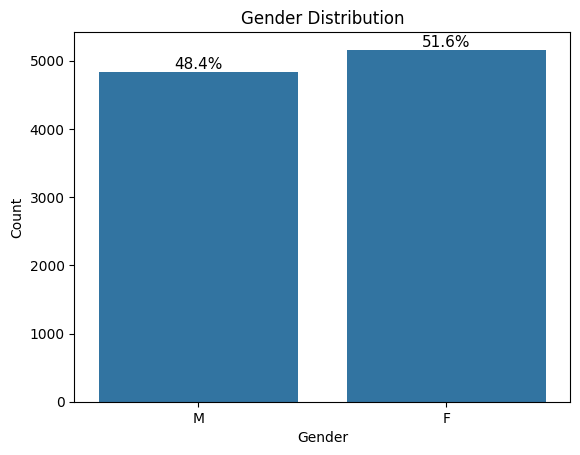

In [11]:
# Customers Distribution by Age

# Countplot
plt.figure()

ax = sns.countplot(x='gender_cd', data=customers)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

# total observations
total = len(customers)

# annotate percentage
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11
    )

male = (customers['gender_cd'] == 'M').sum()
female = (customers['gender_cd'] == 'F').sum()

print("Total customers:", total)
print("Male customers:", male)
print("Female customers:", female)

plt.show()

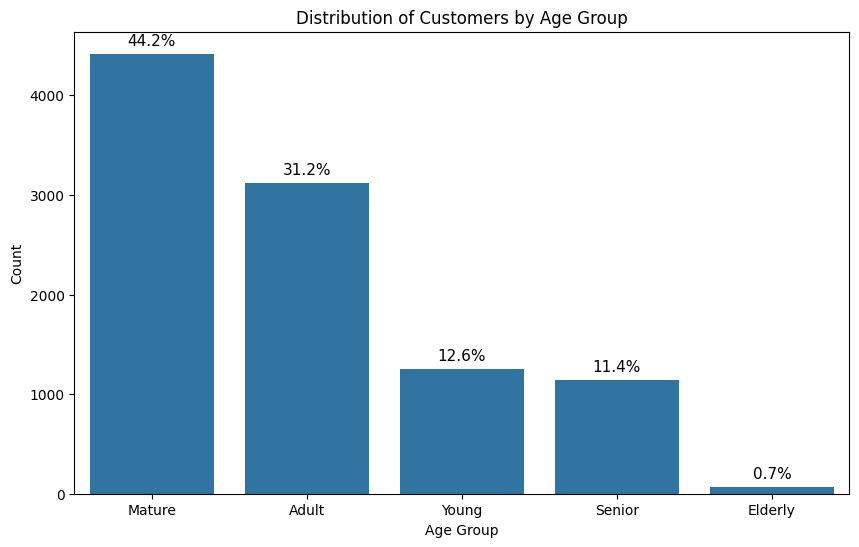

Total customers: 10000
age_group
Mature     4418
Adult      3118
Young      1257
Senior     1140
Elderly      67
Name: count, dtype: int64


In [12]:
# fixed reference date for reproducibility
REFERENCE_DATE = pd.Timestamp('2026-01-01')

#calculate the age

customers['birth_dt'] = pd.to_datetime(customers['birth_dt'])

customers['age'] = (
    (REFERENCE_DATE - customers['birth_dt']).dt.days / 365.25
).astype(int)


#grouping age

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[0, 25, 40, 60, 80, 120],
    labels=['Young', 'Adult', 'Mature', 'Senior', 'Elderly']
)


plt.figure(figsize=(10, 6))
ax = sns.countplot(x='age_group', data=customers, order=customers['age_group'].value_counts().index)

plt.title("Distribution of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")


# total number of customers
total = len(customers)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(customers["age_group"].value_counts())


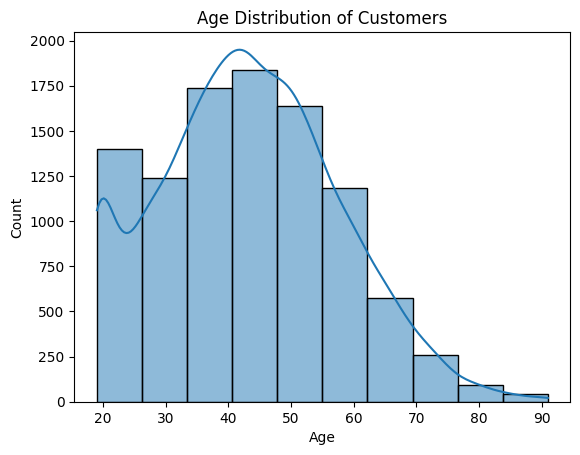

In [13]:
plt.figure()
sns.histplot(customers['age'], bins=10, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


**The dataset represents age distribution of customers is mostly between 30 and 50 years old (the right skewed)**

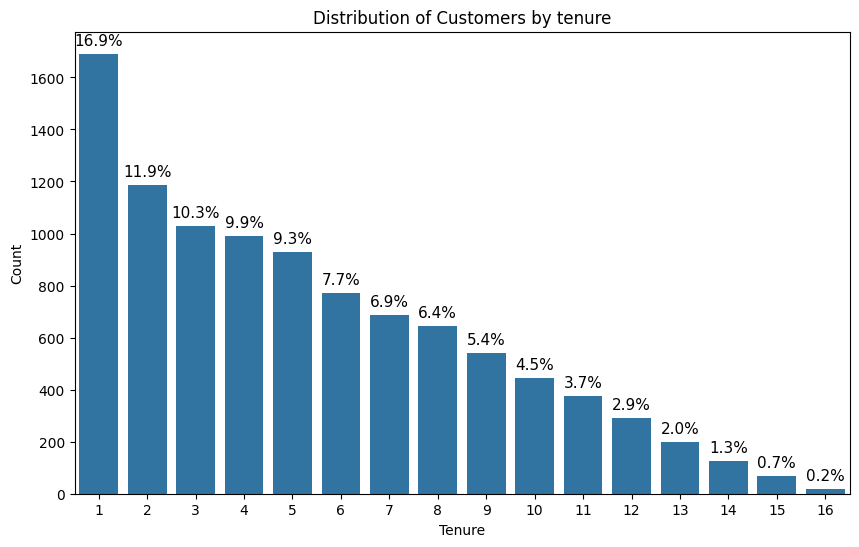

Total customers: 10000
tenure
1     1691
2     1188
3     1029
4      992
5      929
6      773
7      687
8      644
9      542
10     446
11     374
12     292
13     200
14     126
15      67
16      20
Name: count, dtype: int64


In [14]:
# fixed reference date for reproducibility

REFERENCE_DATE = pd.Timestamp('2026-01-01')

#calculate the age

customers['bank_reg_dt'] = pd.to_datetime(customers['bank_reg_dt'])

customers['tenure'] = (
    (REFERENCE_DATE - customers['bank_reg_dt']).dt.days / 365.25
).astype(int)


plt.figure(figsize=(10, 6))
ax = sns.countplot(x='tenure', data=customers, order=customers['tenure'].value_counts().index)

plt.title("Distribution of Customers by tenure")
plt.xlabel("Tenure")
plt.ylabel("Count")


# total number of customers
total = len(customers)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(customers["tenure"].value_counts())


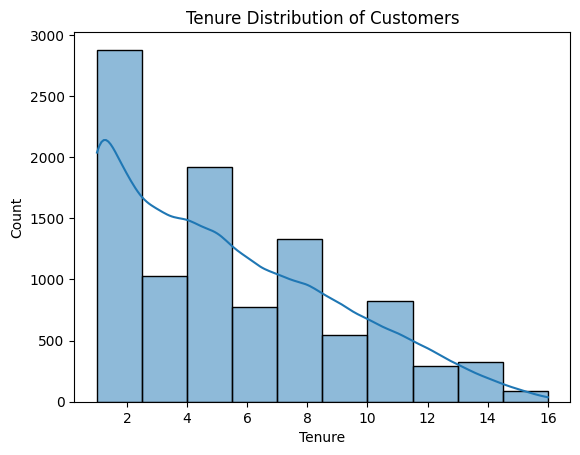

In [15]:
plt.figure()
sns.histplot(customers['tenure'], bins=10, kde=True)
plt.title('Tenure Distribution of Customers')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

**The dataset represents tenure distribution of customers is mostly around 2 years (right skewed)**

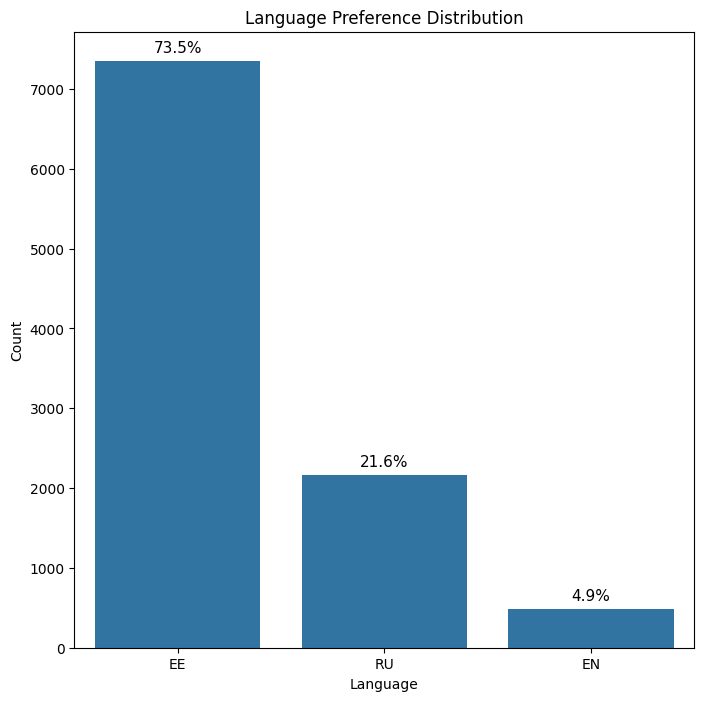

Total customers: 10000
lang_pref
EE    7350
RU    2164
EN     486
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(8, 8))

ax = sns.countplot(x='lang_pref', data=customers, order=customers['lang_pref'].value_counts().index)
plt.title("Language Preference Distribution")
plt.xlabel("Language")
plt.ylabel("Count")


# total number of customers
total = len(customers)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(customers["lang_pref"].value_counts())

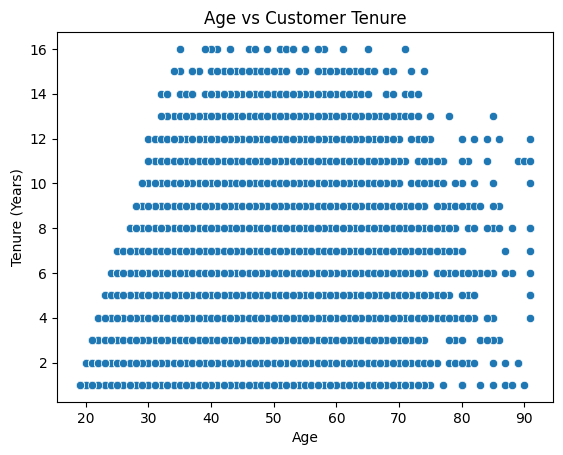

In [17]:
plt.figure()
sns.scatterplot(
    data=customers,
    x="age",
    y=customers["tenure"]
)
plt.title("Age vs Customer Tenure")
plt.xlabel("Age")
plt.ylabel("Tenure (Years)")
plt.show()


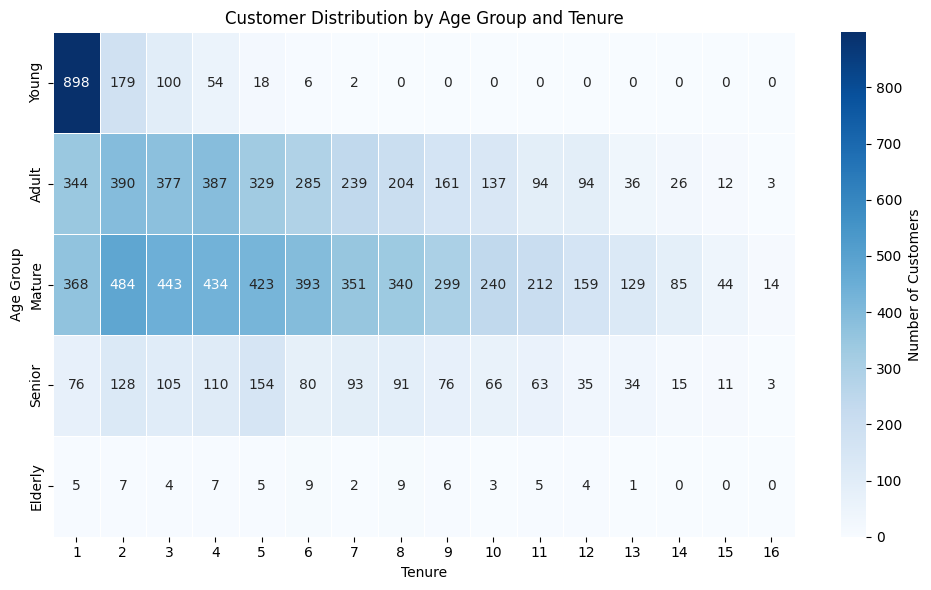

In [18]:
pivot = pd.pivot_table(
    customers,
    values="client_id",
    index="age_group",
    columns="tenure",
    aggfunc="count",
    fill_value=0
)


plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of Customers"}
)

plt.title("Customer Distribution by Age Group and Tenure")
plt.xlabel("Tenure")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

### - **Data Dictionary for Transactions 2024 Table**

| Field             | Description                                                        |
| ----------------- | ------------------------------------------------------------------ |
| acct_iban         | IBAN of the customer’s account                                     |
| amount_eur        | Transaction amount converted to EUR                                |
| amount_orig       | Amount in the original transaction currency                        |
| date              | Value / booking date of the transaction (bank ledger date)         |
| time              | Time component for the booking entry                               |
| channel           | Origin channel: online, mobile, card, branch, atm                  |
| client_id         | Foreign key to `customers.client_id`                               |
| counterparty_iban | IBAN of the other party                                            |
| day_in_month      | Day component (01–31) from booking date                            |
| d_c               | **Codes:** D = debit (money leaves); C = credit (money enters)     |
| mcc               | 4-digit merchant category code (ISO 18245); card transactions only |
| merchant_country  | Country of the merchant (card transactions only)                   |
| period_yy_mm      | Two-digit year + two-digit month from booking date                 |
| trx_ccy           | Original transaction currency                                      |
| txn_id            | Unique transaction / journal identifier                            |
| weekday_name      | Three-letter day name (Sun–Sat)                                    |






## **Transactions Profile**

### - **Basic Data Information Transactions**

In [19]:
# accessing dataframe transactions_2024
transactions_2024 = dataframes['transactions_2024']

transaction = transactions_2024.copy()

transactions_2024.head()

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE
1,CUST000001,2024-01-12,13:32:11,TX00000002,online,D,EUR,88.83,88.83,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BEF6GRNF2ANPJCRMF5CIJI3W,NaN,EE
2,CUST000001,2024-01-22,18:37:34,TX00000003,card,D,EUR,11.79,11.79,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_2NPYIVWYTU6RB3EF2DPW5K2T,5816.0,EE
3,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE
4,CUST000001,2024-02-12,23:50:31,TX00000005,online,D,EUR,95.47,95.47,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BXJ2CJNGBHCMPJURBIU7RSLX,NaN,EE


In [20]:
#Checking & Handing Missing Values

# check NA in each row
nan_rows = transactions_2024.isna().any(axis=1)
print("NA in rows information:")
display(nan_rows)

#check how many NA value in each row
nan_rows_sum = transactions_2024.isnull().sum().sort_values(ascending=False)
print(" ")
print("NA value in rows (Sum):")
display(nan_rows_sum)

NA in rows information:


0           True
1           True
2          False
3           True
4           True
           ...  
1551063     True
1551064     True
1551065     True
1551066     True
1551067     True
Length: 1551068, dtype: bool

 
NA value in rows (Sum):


mcc                  652354
client_id                 0
date                      0
time                      0
txn_id                    0
channel                   0
d_c                       0
trx_ccy                   0
amount_eur                0
amount_orig               0
acct_iban                 0
counterparty_iban         0
merchant_country          0
dtype: int64

**There is no empty rows in all features**

In [21]:
transactions_2024.shape

(1551068, 13)

In [22]:
# Descriptive statistics for numerical
transactions_2024.describe(include= [np.number])

,amount_eur,amount_orig,mcc
count,1.551068e+06,1.551068e+06,898714.000000
mean,1.720244e+02,1.879295e+02,5548.715851
std,4.634241e+02,5.406237e+02,622.744620
min,6.000000e-01,6.000000e-01,4111.000000
25%,1.980000e+01,2.009000e+01,5411.000000
50%,3.960000e+01,4.083000e+01,5651.000000
75%,8.863000e+01,9.485000e+01,5816.000000
max,7.199460e+03,6.549389e+04,7999.000000


In [23]:
# Descriptive statistics for non-numerical
transactions_2024.describe(include='object')

,client_id,date,time,txn_id,channel,d_c,trx_ccy,acct_iban,counterparty_iban,merchant_country
count,1551068,1551068,1551068,1551068,1551068,1551068,1551068,1551068,1551068,1551068
unique,9519,366,64730,1551068,5,2,9,13664,14975,17
top,CUST009523,2024-12-16,15:30:55,TX00000001,card,D,EUR,ACC_MWMZ7HOPJ4TPFNQNCZSKS6GG,CP_Z77UW3O3C3Q5VUFKDXQTASEI,EE
freq,724,12413,68,1,898714,1359488,1508379,719,59962,1391364


In [24]:
transactions_2024.columns

Index(['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy',
       'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc',
       'merchant_country'],
      dtype='object')

### - **Checking & Handing Missing Values**

In [25]:
# check NA in each row

nan_rows = transactions_2024.isna().any(axis=1)
print("NA in rows information:")
display(nan_rows)

NA in rows information:


0           True
1           True
2          False
3           True
4           True
           ...  
1551063     True
1551064     True
1551065     True
1551066     True
1551067     True
Length: 1551068, dtype: bool

In [26]:
#check how many NA value in each row
nan_rows_sum = transactions_2024.isnull().sum().sort_values(ascending=False)
print(" ")
print("NA value in rows (Sum):")
display(nan_rows_sum)

 
NA value in rows (Sum):


mcc                  652354
client_id                 0
date                      0
time                      0
txn_id                    0
channel                   0
d_c                       0
trx_ccy                   0
amount_eur                0
amount_orig               0
acct_iban                 0
counterparty_iban         0
merchant_country          0
dtype: int64

**There is no empty rows in all features**

In [27]:
transactions_2024["amount_eur"].describe()

count    1.551068e+06
mean     1.720244e+02
std      4.634241e+02
min      6.000000e-01
25%      1.980000e+01
50%      3.960000e+01
75%      8.863000e+01
max      7.199460e+03
Name: amount_eur, dtype: float64

### - **Check Transaction Distribution**

The dataset represents a structurally homogeneous customer segment, where variation is primarily driven by demographic and lifecycle attributes rather than organisational or product complexity.


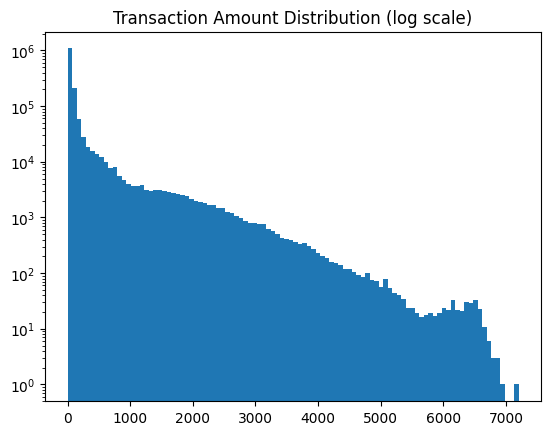

In [28]:
plt.hist(transactions_2024["amount_eur"], bins=100)
plt.yscale("log")
plt.title("Transaction Amount Distribution (log scale)")
plt.show()


### - **Transaction Channel Distribution**

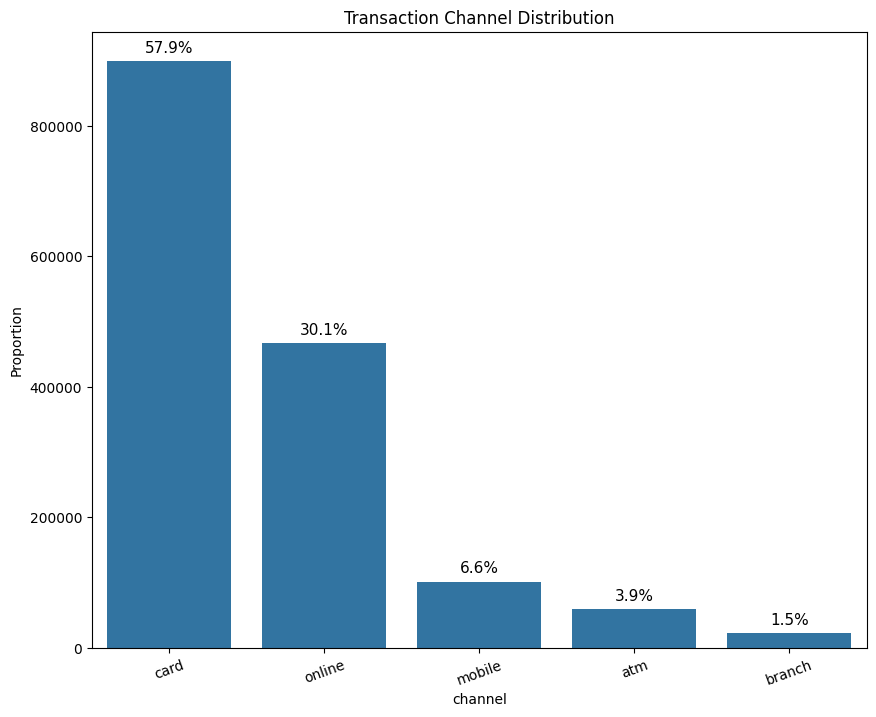

Total proportion per Channel: 1551068
channel
card      898714
online    467489
mobile    101835
atm        59962
branch     23068
Name: count, dtype: int64


In [29]:
plt.figure(figsize=(10, 8))

ax = sns.countplot(x='channel', data=transactions_2024, order=transactions_2024["channel"].value_counts(dropna=False).index)
plt.title("Transaction Channel Distribution")
plt.ylabel("Proportion")
plt.xticks(rotation=20)

# total number of each financial type
total = len(transactions_2024)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total proportion per Channel:", len(transactions_2024))
print(transactions_2024["channel"].value_counts())



### - **Debit vs Credit Distribution**

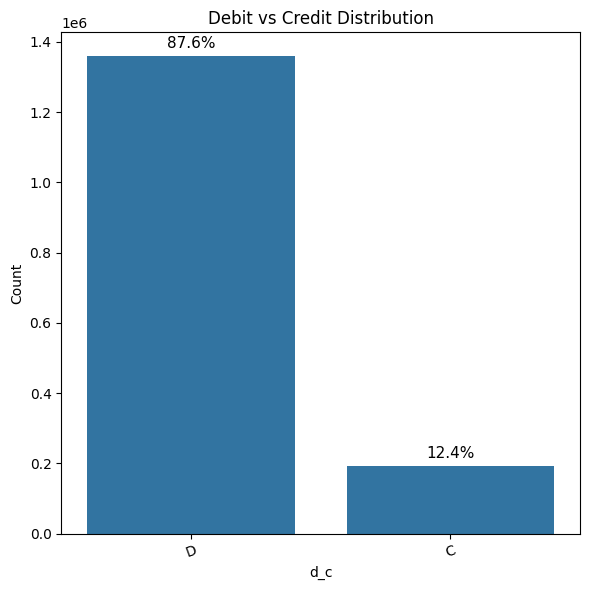

Total transactions: 1551068
d_c
D    1359488
C     191580
Name: count, dtype: int64

Proportion:
d_c
D    0.8765
C    0.1235
Name: proportion, dtype: float64


In [30]:
plt.figure(figsize=(6, 6))

ax = sns.countplot(
    x="d_c",
    data=transactions_2024,
    order=transactions_2024["d_c"].value_counts().index
)

plt.title("Debit vs Credit Distribution")
plt.xlabel("d_c")
plt.ylabel("Count")
plt.xticks(rotation=20)

total = len(transactions_2024)

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total if total > 0 else 0
    ax.annotate(
        f"{percentage:.1f}%",
        (p.get_x() + p.get_width() / 2., count),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

print("Total transactions:", len(transactions_2024))
print(transactions_2024["d_c"].value_counts())
print("\nProportion:")
print(transactions_2024["d_c"].value_counts(normalize=True).round(4))


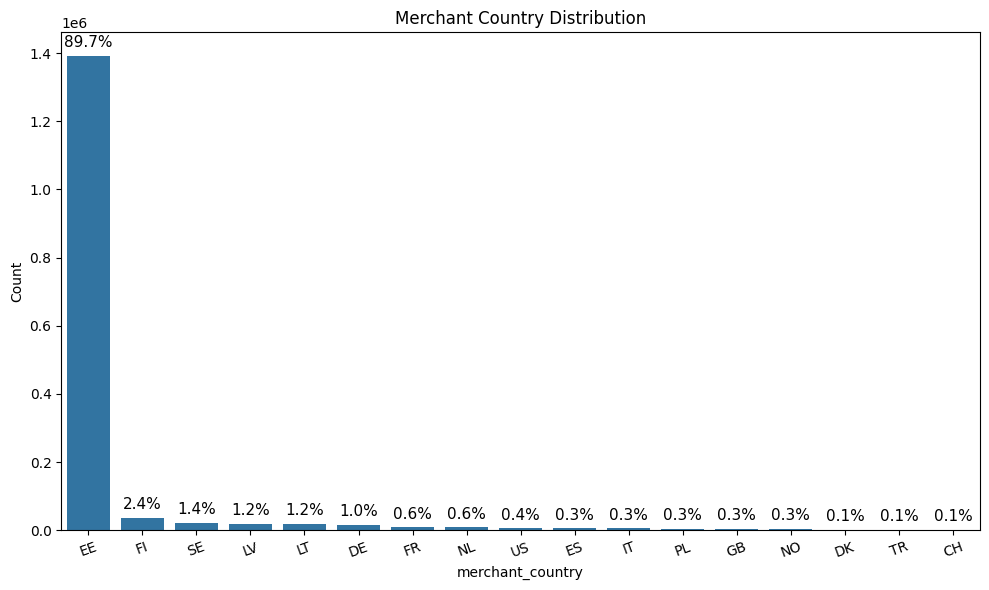

Total transactions: 1551068
merchant_country
EE    1391364
FI      36612
SE      20951
LV      19193
LT      18661
DE      15026
FR       8992
NL       8624
US       5937
ES       4964
IT       4943
PL       4128
GB       4029
NO       3909
DK       1772
TR        984
CH        979
Name: count, dtype: int64

Proportion:
merchant_country
EE    0.8970
FI    0.0236
SE    0.0135
LV    0.0124
LT    0.0120
DE    0.0097
FR    0.0058
NL    0.0056
US    0.0038
ES    0.0032
IT    0.0032
PL    0.0027
GB    0.0026
NO    0.0025
DK    0.0011
TR    0.0006
CH    0.0006
Name: proportion, dtype: float64


In [31]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    x="merchant_country",
    data=transactions_2024,
    order=transactions_2024["merchant_country"].value_counts().index
)

plt.title("Merchant Country Distribution")
plt.xlabel("merchant_country")
plt.ylabel("Count")
plt.xticks(rotation=20)

total = len(transactions_2024)

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total if total > 0 else 0
    ax.annotate(
        f"{percentage:.1f}%",
        (p.get_x() + p.get_width() / 2., count),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

print("Total transactions:", len(transactions_2024))
print(transactions_2024["merchant_country"].value_counts())
print("\nProportion:")
print(transactions_2024["merchant_country"].value_counts(normalize=True).round(4))


### - **Date and Time (For Checking Transaction Velocity-Cleaning Data Only)**

In [32]:
transactions_2024.columns

Index(['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy',
       'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc',
       'merchant_country'],
      dtype='object')

In [33]:
transactions = transactions_2024.copy()

# date should be in the datetime form to easily do rolling dan sorting data by date
transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")

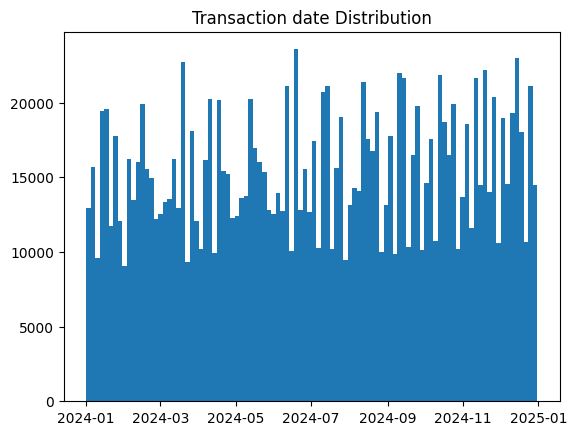

In [34]:
plt.hist(transactions["date"], bins=100)
plt.title("Transaction date Distribution")
plt.show()


### - **Monthly Transaction Volume (across all customers)**

In [35]:
transactions["month"] = transactions["date"].dt.to_period("M")

monthly_volume = (
    transactions
    .groupby("month", as_index=False)
    .agg(txn_count=("txn_id", "count"))
)

monthly_volume

,month,txn_count
0,2024-01,121899
1,2024-02,117406
2,2024-03,124572
3,2024-04,122720
4,2024-05,127367
5,2024-06,125601
6,2024-07,130366
7,2024-08,133019
8,2024-09,131199
9,2024-10,136816


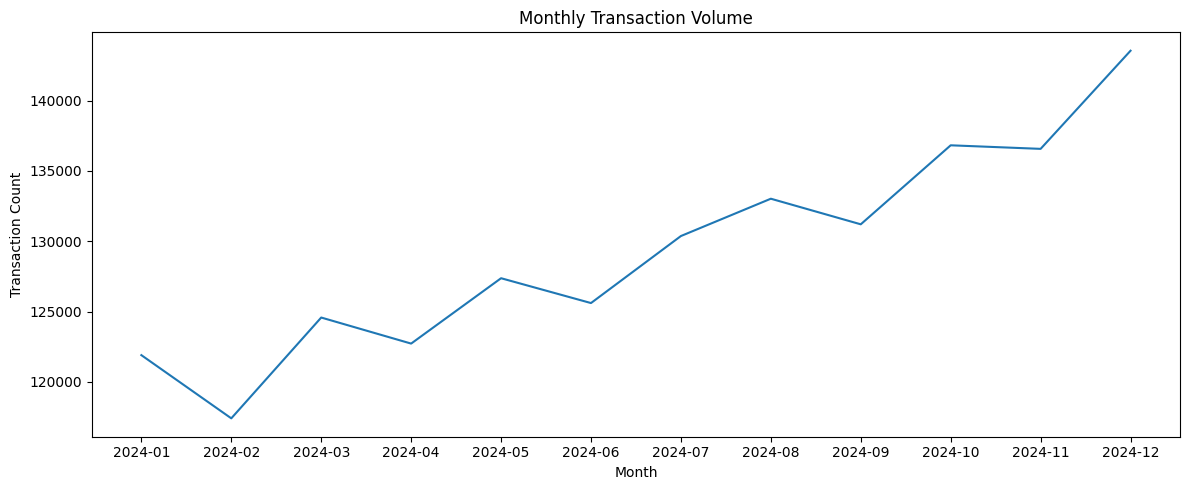

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_volume["month"].astype(str),
    monthly_volume["txn_count"]
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()


In [37]:
transactions["month"] = transactions["date"].dt.to_period("M")

monthly_amount = (
    transactions
    .groupby("month", as_index=False)
    .agg(total_amount=("amount_eur", "sum"))
)

monthly_amount

,month,total_amount
0,2024-01,20848753.71
1,2024-02,20657444.60
2,2024-03,21234588.89
3,2024-04,21244166.96
4,2024-05,21790425.26
5,2024-06,21770977.57
6,2024-07,22306236.67
7,2024-08,22612937.42
8,2024-09,22806797.39
9,2024-10,23382054.46


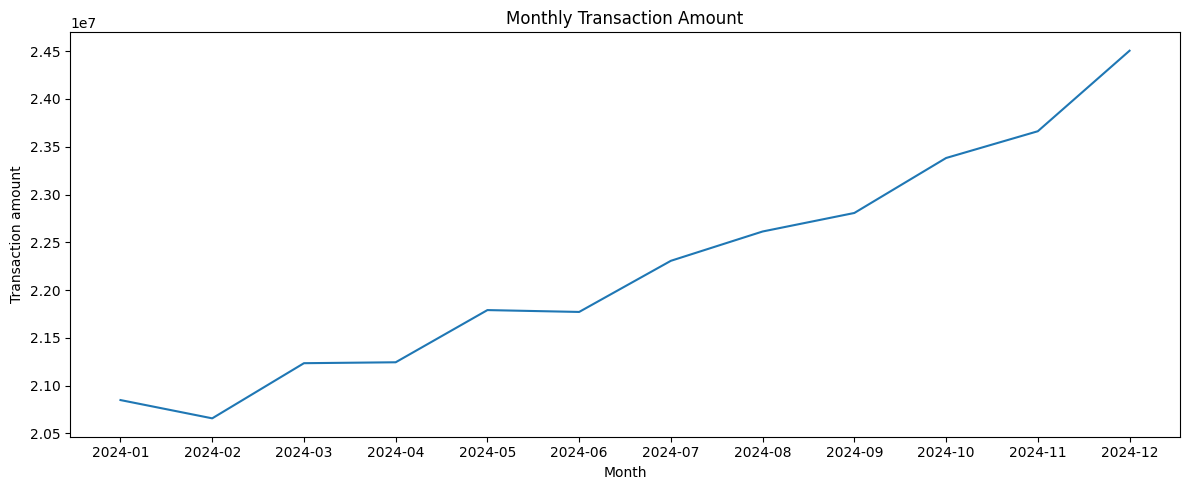

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_amount["month"].astype(str),
    monthly_amount["total_amount"]
)

plt.title("Monthly Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Transaction amount")
plt.tight_layout()
plt.show()


In [39]:
transactions["month"] = transactions["date"].dt.to_period("M")

monthly_txn = (
    transactions
    .groupby("month", as_index=False)
    .agg(
        txn_count=("txn_id", "count"),
        total_amount=("amount_eur", "sum"),
        avg_amount=("amount_eur", "mean")
    )
)
monthly_txn


,month,txn_count,total_amount,avg_amount
0,2024-01,121899,20848753.71,171.033017
1,2024-02,117406,20657444.60,175.948798
2,2024-03,124572,21234588.89,170.460367
3,2024-04,122720,21244166.96,173.110878
4,2024-05,127367,21790425.26,171.083760
5,2024-06,125601,21770977.57,173.334429
6,2024-07,130366,22306236.67,171.104710
7,2024-08,133019,22612937.42,169.997800
8,2024-09,131199,22806797.39,173.833622
9,2024-10,136816,23382054.46,170.901462


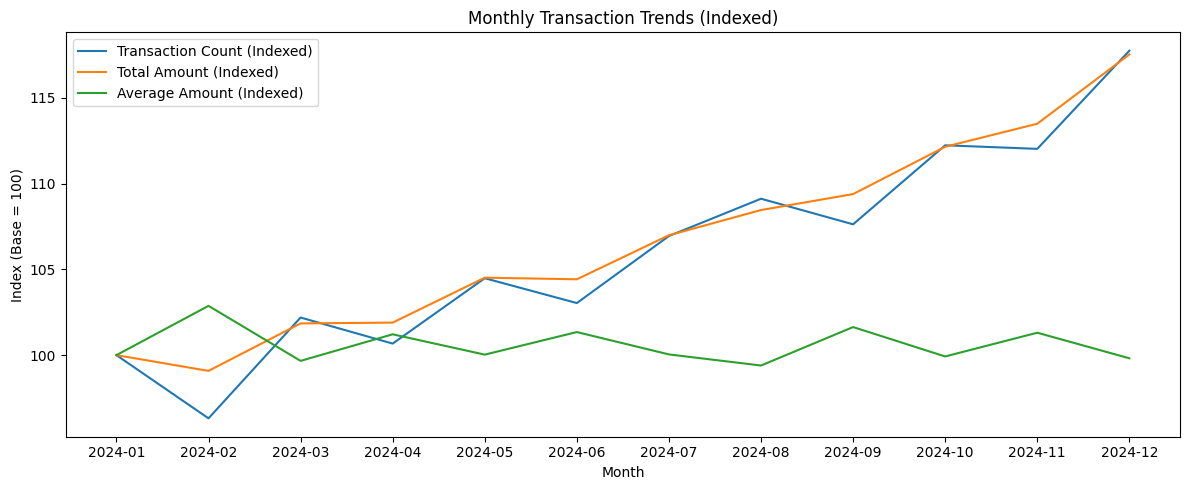

In [40]:
monthly_plot = monthly_txn.copy()

monthly_plot["txn_count_idx"] = (
    monthly_plot["txn_count"] / monthly_plot["txn_count"].iloc[0] * 100
)

monthly_plot["total_amount_idx"] = (
    monthly_plot["total_amount"] / monthly_plot["total_amount"].iloc[0] * 100
)

monthly_plot["avg_amount_idx"] = (
    monthly_plot["avg_amount"] / monthly_plot["avg_amount"].iloc[0] * 100
)



plt.figure(figsize=(12, 5))

plt.plot(
    monthly_plot["month"].astype(str),
    monthly_plot["txn_count_idx"],
    label="Transaction Count (Indexed)"
)

plt.plot(
    monthly_plot["month"].astype(str),
    monthly_plot["total_amount_idx"],
    label="Total Amount (Indexed)"
)

plt.plot(
    monthly_plot["month"].astype(str),
    monthly_plot["avg_amount_idx"],
    label="Average Amount (Indexed)"
)

plt.title("Monthly Transaction Trends (Indexed)")
plt.xlabel("Month")
plt.ylabel("Index (Base = 100)")
plt.legend()
plt.tight_layout()
plt.show()


**Comparison of indexed trends across variables to illustrate monthly patterns in transaction volume, total transaction value, and average transaction amount, enabling comparability across metrics with different units.**

### - **Daily Transaction Volume (across all customers)**

In [41]:
transactions["day"] = transactions["date"].dt.floor("D")

daily_volume = (
    transactions
    .groupby("day", as_index=False)
    .agg(txn_count=("txn_id", "count"))
)

daily_volume

,day,txn_count
0,2024-01-01,3057
1,2024-01-02,2959
2,2024-01-03,2994
3,2024-01-04,3935
4,2024-01-05,6202
...,...,...
361,2024-12-27,3535
362,2024-12-28,3615
363,2024-12-29,3765
364,2024-12-30,3503


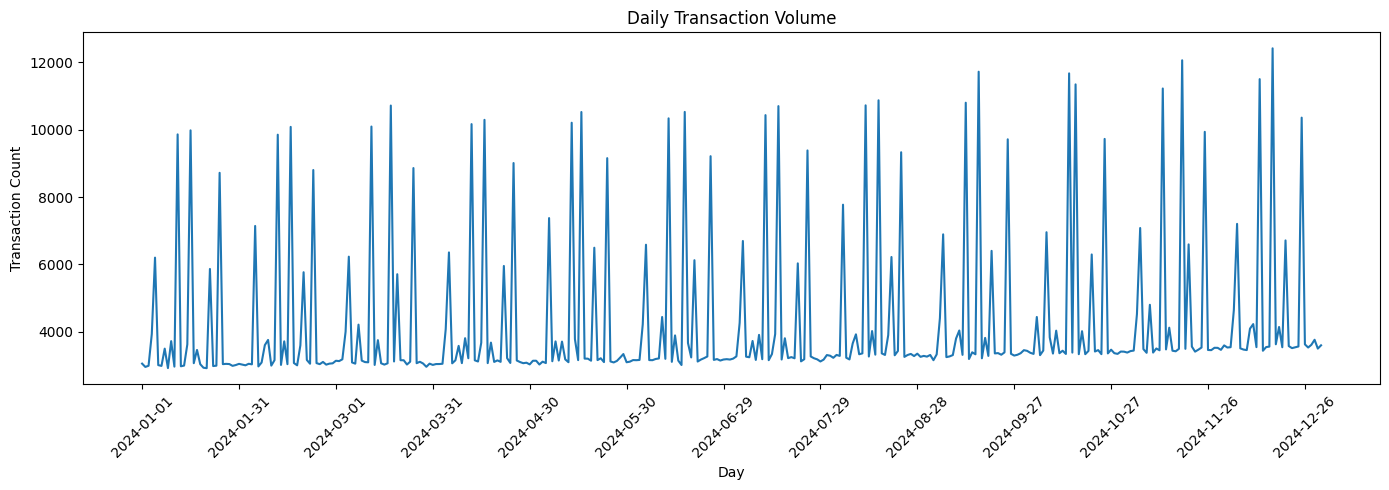

In [42]:
plt.figure(figsize=(14, 5))
plt.plot(daily_volume["day"], daily_volume["txn_count"])

plt.title("Daily Transaction Volume")
plt.xlabel("Day")
plt.ylabel("Transaction Count")

plt.xticks(daily_volume["day"][::30], rotation=45)  # day ~30 days
plt.tight_layout()
plt.show()


In [43]:
transactions["day"] = transactions["date"].dt.floor("D")

daily_amount = (
    transactions
    .groupby("day", as_index=False)
    .agg(total_amount=("amount_eur", "sum"))
)

daily_amount

,day,total_amount
0,2024-01-01,211031.79
1,2024-01-02,195304.09
2,2024-01-03,203459.47
3,2024-01-04,828310.71
4,2024-01-05,1952094.36
...,...,...
361,2024-12-27,235256.44
362,2024-12-28,241648.76
363,2024-12-29,257863.60
364,2024-12-30,228391.01


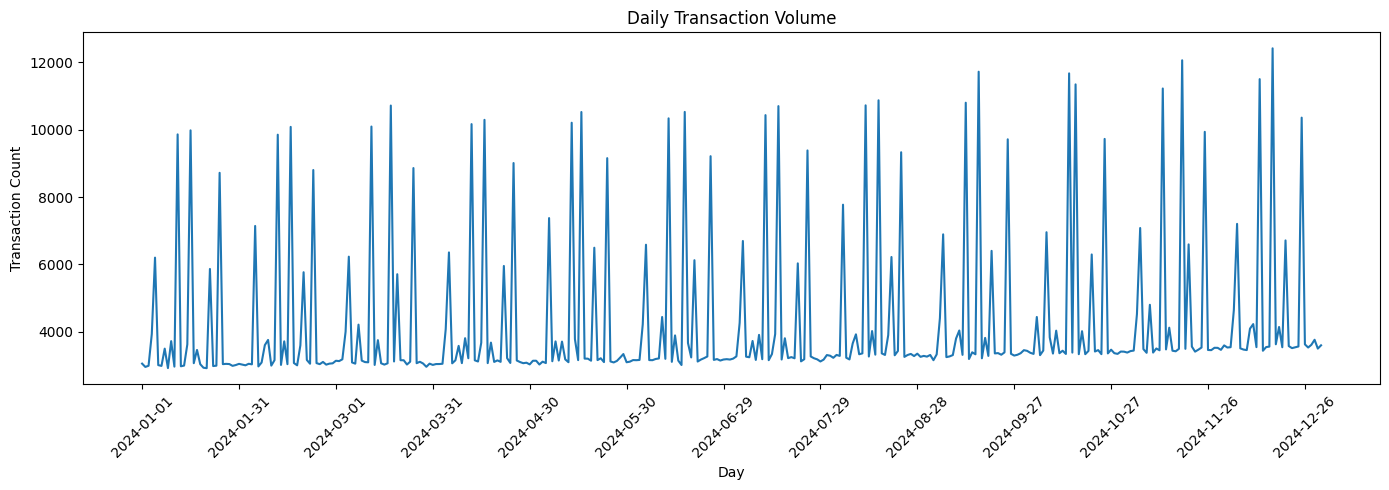

In [44]:
plt.figure(figsize=(14, 5))
plt.plot(daily_volume["day"], daily_volume["txn_count"])

plt.title("Daily Transaction Volume")
plt.xlabel("Day")
plt.ylabel("Transaction Count")

plt.xticks(daily_volume["day"][::30], rotation=45)  # tiap ~30 hari
plt.tight_layout()
plt.show()


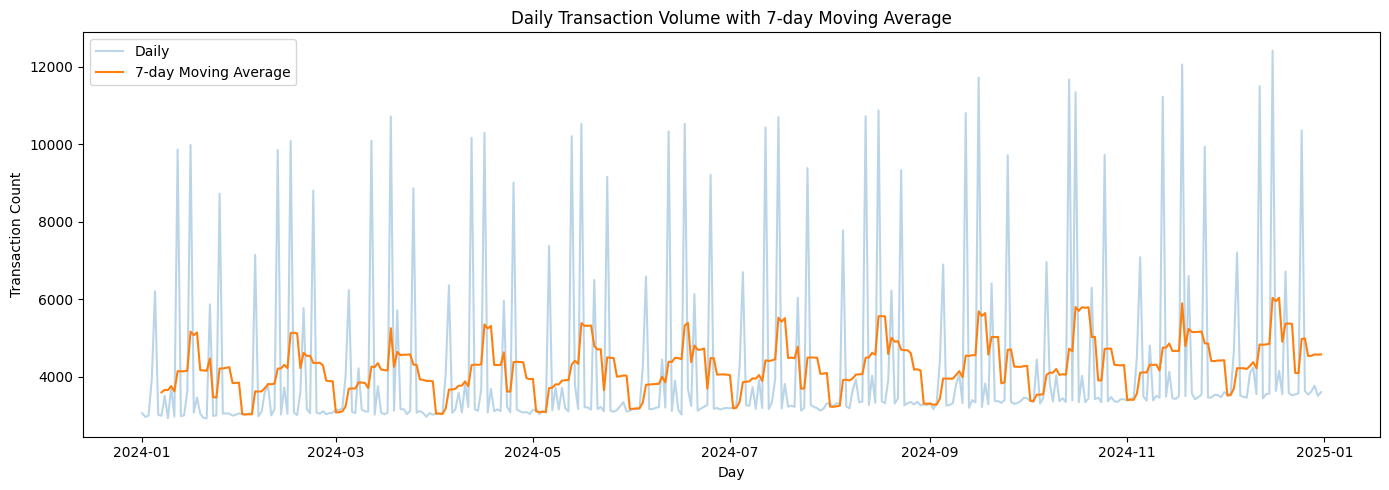

In [45]:
daily_volume["txn_7d_avg"] = (
    daily_volume["txn_count"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14, 5))
plt.plot(daily_volume["day"], daily_volume["txn_count"], alpha=0.3, label="Daily")
plt.plot(daily_volume["day"], daily_volume["txn_7d_avg"], label="7-day Moving Average")

plt.title("Daily Transaction Volume with 7-day Moving Average")
plt.xlabel("Day")
plt.ylabel("Transaction Count")
plt.legend()
plt.tight_layout()
plt.show()


**Comparison of indexed trends across variables to illustrate daily patterns in transaction volume, total transaction value, and average transaction amount, enabling comparability across metrics with different units.**

**In Conclusion, Daily and monthly analyses indicate stable transaction trends at the population level. Nevertheless, detecting suspicious transactions necessitates customer-level analysis, as aggregated trends do not capture individual anomalies.**

### **Data Dictionary for Margin Assets Table**

| Field                 | Description                               |
| --------------------- | ----------------------------------------- |
| acct_ccy              | Account currency                          |
| avg_balance_eur       | Average balance across the month          |
| avg_interest_base_eur | Average balance used for interest accrual |
| client_id_fk          | Foreign key to `customers.client_id`      |
| end_balance_eur       | Balance at month end (EUR)                |
| month_end             | Month-end snapshot date                   |




In [46]:
# accessing dataframe margin_assets

margin_assets = dataframes['margin_assets']

asset = margin_assets.copy()

margin_assets.head()

,acct_ccy,avg_balance_eur,avg_interest_base_eur,client_id_fk,end_balance_eur,month_end
0,EUR,6378.58,6100.54,CUST000007,6433.63,2024-01-31
1,EUR,6485.76,4694.14,CUST000007,6221.45,2024-02-29
2,EUR,4843.42,3558.95,CUST000007,4951.52,2024-03-31
3,EUR,6292.46,5926.30,CUST000007,7147.96,2024-04-30
4,EUR,4846.27,3611.47,CUST000007,4760.32,2024-05-31


### **Data Dictionary for Margin Liabilities Table**

| Field                 | Description                               |
| --------------------- | ----------------------------------------- |
| avg_balance_eur       | Average balance across the month          |
| avg_interest_base_eur | Average balance used for interest accrual |
| client_id_fk          | Foreign key to `customers.client_id`      |
| contract_ccy          | Agreement currency                        |
| end_balance_eur       | Balance at month end (EUR)                |
| month_end             | Month-end snapshot date                   |


In [47]:
# accessing dataframe margin_liabilities
margin_liabilities = dataframes['margin_liabilities']

liabilities = margin_liabilities.copy()

margin_liabilities.head()

,avg_balance_eur,avg_interest_base_eur,client_id_fk,contract_ccy,end_balance_eur,month_end
0,4339.59,3797.14,CUST000002,EUR,3944.13,2024-01-31
1,4244.11,3489.67,CUST000002,EUR,4094.33,2024-02-29
2,4190.52,4054.46,CUST000002,EUR,4077.30,2024-03-31
3,3953.78,3678.45,CUST000002,EUR,3864.00,2024-04-30
4,4148.58,3939.64,CUST000002,EUR,3532.76,2024-05-31


# **Financial Capacity Profiles (Assets & Liabilities)**

### - **Basic Data Information Customers' Financial Capacity**


**To construct the financial capacity profile, customer-level balances are aggregated over a 12-month observation window. Customers are categorized based on the presence of asset and liability balances into deposit-only, loan-only, both, or inactive (if any) groups. Average annual balances are used to represent typical financial capacity, reducing sensitivity to short-term fluctuations.**

In [48]:
margin_assets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31908 entries, 0 to 31907
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   acct_ccy               31908 non-null  object 
 1   avg_balance_eur        31908 non-null  float64
 2   avg_interest_base_eur  31908 non-null  float64
 3   client_id_fk           31908 non-null  object 
 4   end_balance_eur        31908 non-null  float64
 5   month_end              31908 non-null  object 
dtypes: float64(3), object(3)
memory usage: 1.5+ MB


In [49]:
margin_liabilities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22839 entries, 0 to 22838
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   avg_balance_eur        22839 non-null  float64
 1   avg_interest_base_eur  22839 non-null  float64
 2   client_id_fk           22839 non-null  object 
 3   contract_ccy           22839 non-null  object 
 4   end_balance_eur        22839 non-null  float64
 5   month_end              22839 non-null  object 
dtypes: float64(3), object(3)
memory usage: 1.0+ MB


In [50]:
print("liabilities:", margin_liabilities.shape)
print("assets:", margin_assets.shape)

liabilities: (22839, 6)
assets: (31908, 6)


### - **Aggregate margin_assets**

In [51]:
#copy dataframe
ma = margin_assets.copy()

# change feature name to client_id
ma = ma.rename(columns={"client_id_fk": "client_id"})

# change the date type of month_end
if "month_end" in ma.columns:
    ma["month_end"] = pd.to_datetime(ma["month_end"], errors="coerce")

print('client_id empty:', ma["client_id"].isna().sum())

ma.head()


client_id empty: 0


,acct_ccy,avg_balance_eur,avg_interest_base_eur,client_id,end_balance_eur,month_end
0,EUR,6378.58,6100.54,CUST000007,6433.63,2024-01-31
1,EUR,6485.76,4694.14,CUST000007,6221.45,2024-02-29
2,EUR,4843.42,3558.95,CUST000007,4951.52,2024-03-31
3,EUR,6292.46,5926.30,CUST000007,7147.96,2024-04-30
4,EUR,4846.27,3611.47,CUST000007,4760.32,2024-05-31


In [52]:
# aggregation per customer id

# ma.groupby("client_id").dropna(...)

# ma.dropna(subset=["client_id"]).groupby("client_id").agg(...)


assets_profile = (
    ma.dropna(subset=["client_id"])
      .groupby("client_id", as_index=False)
      .agg(
          asset_months_present=("month_end", lambda s: s.dt.to_period("M").nunique() if s.notna().any() else 0),
          avg_assets_balance_eur=("avg_balance_eur", "mean"),
          end_assets_balance_eur=("end_balance_eur", "mean"),
      )
)

assets_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur
0,CUST000007,12,5532.411667,5617.427500
1,CUST000009,12,1319.543333,1255.741667
2,CUST000012,12,4518.456667,4404.460833
3,CUST000028,12,3173.767500,3263.986667
4,CUST000029,12,26067.799167,26056.237500


### - **Aggregate margin_liabilities**

In [53]:
#copy dataframe
ml = margin_liabilities.copy()

# change feature name to client_id
ml = ml.rename(columns={"client_id_fk": "client_id"})

# change the date type of month_end
if "month_end" in ml.columns:
    ml["month_end"] = pd.to_datetime(ml["month_end"], errors="coerce")

print('client_id empty:', ml["client_id"].isna().sum())

ml.head()

client_id empty: 0


,avg_balance_eur,avg_interest_base_eur,client_id,contract_ccy,end_balance_eur,month_end
0,4339.59,3797.14,CUST000002,EUR,3944.13,2024-01-31
1,4244.11,3489.67,CUST000002,EUR,4094.33,2024-02-29
2,4190.52,4054.46,CUST000002,EUR,4077.30,2024-03-31
3,3953.78,3678.45,CUST000002,EUR,3864.00,2024-04-30
4,4148.58,3939.64,CUST000002,EUR,3532.76,2024-05-31


In [54]:
# aggregation per customer id

# ma.groupby("client_id").dropna(...)

# ma.dropna(subset=["client_id"]).groupby("client_id").agg(...)


liabilities_profile = (
    ml.dropna(subset=["client_id"])
      .groupby("client_id", as_index=False)
      .agg(
          liabilities_months_present=("month_end", lambda s: s.dt.to_period("M").nunique() if s.notna().any() else 0),
          avg_liabilities_balance_eur=("avg_balance_eur", "mean"),
          end_liabilities_balance_eur=("end_balance_eur", "mean"),
      )
)

liabilities_profile.head()


,client_id,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur
0,CUST000002,12,3816.380000,3662.404167
1,CUST000003,12,5413.245833,5461.457500
2,CUST000006,12,21866.440833,22202.955833
3,CUST000011,12,2110.405833,2102.321667
4,CUST000012,12,6509.881667,6419.411667


### - **Customer Baseline table**

In [55]:
cb = customers.copy()

# aligning customer id column name
cb = cb.rename(columns={"client_id": "client_id"})

customer_base = cb[["client_id"]].drop_duplicates()
customer_base.head()


,client_id
0,CUST000001
1,CUST000002
2,CUST000003
3,CUST000004
4,CUST000005


### - **Customer Baseline table join with Financial baseline**

In [56]:
# join customer baseline with financial baseline (assets & liabilities)

financial_profile = (
    customer_base
    .merge(assets_profile, on="client_id", how="left")
    .merge(liabilities_profile, on="client_id", how="left")
)

financial_profile.head()


,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur
0,CUST000001,NaN,NaN,NaN,NaN,NaN,NaN
1,CUST000002,NaN,NaN,NaN,12.0,3816.380000,3662.404167
2,CUST000003,NaN,NaN,NaN,12.0,5413.245833,5461.457500
3,CUST000004,NaN,NaN,NaN,NaN,NaN,NaN
4,CUST000005,NaN,NaN,NaN,NaN,NaN,NaN


### - **Fill row (NaN) with 0**

In [57]:
cols_to_fill = [
    "asset_months_present",
    "avg_assets_balance_eur",
    "end_assets_balance_eur",
    "liabilities_months_present",
    "avg_liabilities_balance_eur",
    "end_liabilities_balance_eur",
]

for c in cols_to_fill:
    financial_profile[c] = financial_profile[c].fillna(0)

financial_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur
0,CUST000001,0.0,0.0,0.0,0.0,0.000000,0.000000
1,CUST000002,0.0,0.0,0.0,12.0,3816.380000,3662.404167
2,CUST000003,0.0,0.0,0.0,12.0,5413.245833,5461.457500
3,CUST000004,0.0,0.0,0.0,0.0,0.000000,0.000000
4,CUST000005,0.0,0.0,0.0,0.0,0.000000,0.000000


### - **Assign financial type label**


**Logic:**

assets > 0 & liabilities = 0 -> deposit_only

assets = 0 & liabilities > 0 -> loan_only

assets > 0 & liabilities > 0 -> both

assets = 0 & liabilities = 0 -> inactive

In [58]:
# add labelling

financial_profile["has_assets"] = financial_profile["avg_assets_balance_eur"] > 0
financial_profile["has_liabilities"] = financial_profile["avg_liabilities_balance_eur"] > 0

financial_profile["financial_type"] = np.select(
    [
        financial_profile["has_assets"] & ~financial_profile["has_liabilities"],
        ~financial_profile["has_assets"] & financial_profile["has_liabilities"],
        financial_profile["has_assets"] & financial_profile["has_liabilities"],
    ],
    ["deposit_only", "loan_only", "both"],
    default="inactive"
)

financial_profile[["client_id","avg_assets_balance_eur","avg_liabilities_balance_eur","financial_type"]].head(10)


,client_id,avg_assets_balance_eur,avg_liabilities_balance_eur,financial_type
0,CUST000001,0.000000,0.000000,inactive
1,CUST000002,0.000000,3816.380000,loan_only
2,CUST000003,0.000000,5413.245833,loan_only
3,CUST000004,0.000000,0.000000,inactive
4,CUST000005,0.000000,0.000000,inactive
5,CUST000006,0.000000,21866.440833,loan_only
6,CUST000007,5532.411667,0.000000,deposit_only
7,CUST000008,0.000000,0.000000,inactive
8,CUST000009,1319.543333,0.000000,deposit_only
9,CUST000010,0.000000,0.000000,inactive


In [59]:
# change the key column to adjust and align the name in all tables
for df, col in [(customers, "client_id"), (margin_assets, "client_id_fk"), (margin_liabilities, "client_id_fk")]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# check if there is overlap id assets vs customers
cust_ids = set(customers["client_id"].astype(str).str.strip().unique())
asset_ids = set(margin_assets["client_id_fk"].astype(str).str.strip().unique())
liab_ids  = set(margin_liabilities["client_id_fk"].astype(str).str.strip().unique())

print("customers:", len(cust_ids))
print("assets ids:", len(asset_ids), "overlap with customers:", len(cust_ids & asset_ids))
print("liab ids:", len(liab_ids), "overlap with customers:", len(cust_ids & liab_ids))

# To print client_id in the assets but not in customers tables
print("sample assets-only ids:", list(asset_ids - cust_ids)[:10])


customers: 10000
assets ids: 2659 overlap with customers: 2659
liab ids: 1929 overlap with customers: 1929
sample assets-only ids: []


In [60]:
#Checking the financial type distributions
financial_profile["financial_type"].value_counts(dropna=False)

financial_type
inactive        5957
deposit_only    2114
loan_only       1384
both             545
Name: count, dtype: int64

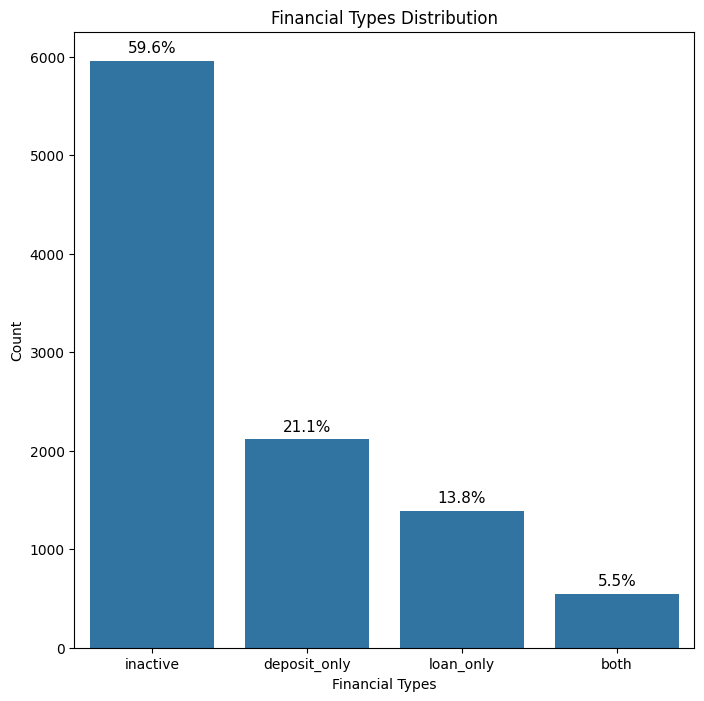

Total customers: 10000
financial_type
inactive        5957
deposit_only    2114
loan_only       1384
both             545
Name: count, dtype: int64


In [61]:
plt.figure(figsize=(8, 8))

ax = sns.countplot(x='financial_type', data=financial_profile, order=financial_profile["financial_type"].value_counts(dropna=False).index)
plt.title("Financial Types Distribution")
plt.xlabel("Financial Types")
plt.ylabel("Count")

# total number of each financial type
total = len(financial_profile)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.show()

print("Total customers:", len(customers))
print(financial_profile["financial_type"].value_counts())

In [62]:
financial_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur,has_assets,has_liabilities,financial_type
0,CUST000001,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive
1,CUST000002,0.0,0.0,0.0,12.0,3816.380000,3662.404167,False,True,loan_only
2,CUST000003,0.0,0.0,0.0,12.0,5413.245833,5461.457500,False,True,loan_only
3,CUST000004,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive
4,CUST000005,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive


### - **Financial Exposure Ratio**

A Financial Exposure Ratio is constructed as the ratio between average observed liabilities and average observed assets. The indicator does not represent a regulatory leverage or capital metric, but serves as a relative exposure proxy to contextualize the potential impact of transaction-level anomalies on customers’ financial capacity. Not all customers hold both deposit and liability products; therefore, margin asset and margin liability tables cover only subsets of the customer population. Missing balances are interpreted as absence of observed exposure and are treated as zero for exposure profiling.


In [63]:
financial_profile["financial_exposure_ratio"] = np.where(
    financial_profile["avg_assets_balance_eur"] > 0,
    financial_profile["avg_liabilities_balance_eur"] / financial_profile["avg_assets_balance_eur"],
    np.nan
)


In [64]:
financial_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur,has_assets,has_liabilities,financial_type,financial_exposure_ratio
0,CUST000001,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN
1,CUST000002,0.0,0.0,0.0,12.0,3816.380000,3662.404167,False,True,loan_only,NaN
2,CUST000003,0.0,0.0,0.0,12.0,5413.245833,5461.457500,False,True,loan_only,NaN
3,CUST000004,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN
4,CUST000005,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN


### - **Interpretation of the Financial Exposure Ratio**


| Asset (Buffer) Condition | Liability (Exposure) Condition | Ratio Value     | Plain Meaning                                                                                                                                           |
| ------------------------ | ------------------------------ | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Present (> 0)            | Present (> 0)                  | > 0             | The customer has both financial obligations and observable buffers. The ratio indicates the relative size of obligations compared to available buffers. |
| Present (> 0)            | Absent (= 0)                   | 0               | The customer has observable buffers and no financial obligations. There is no exposure pressure from liabilities.                                       |
| Absent (= 0)             | Present (> 0)                  | NaN (undefined) | No observable buffer is available, therefore the ratio cannot be meaningfully calculated. This is not a data error.                                     |
| Absent (= 0)             | Absent (= 0)                   | NaN (undefined) | Neither buffers nor obligations are observed. The ratio has no valid reference point for calculation.                                                   |


### **Interpretation Notes**

1. NaN indicates an undefined ratio due to missing reference information, not a low or high risk level.

2. The ratio is used to contextualize financial exposure, not to assess credit risk or regulatory leverage.

3. Results are interpreted relatively, rather than against fixed thresholds.


In [65]:
(financial_profile["avg_assets_balance_eur"] > 0).value_counts()

avg_assets_balance_eur
False    7341
True     2659
Name: count, dtype: int64

In [66]:
financial_profile["avg_assets_balance_eur"].describe()

count    10000.000000
mean      1326.864019
std       3574.167365
min          0.000000
25%          0.000000
50%          0.000000
75%        692.102917
max      61705.510833
Name: avg_assets_balance_eur, dtype: float64

In [67]:
(financial_profile["avg_liabilities_balance_eur"] > 0).value_counts()

avg_liabilities_balance_eur
False    8071
True     1929
Name: count, dtype: int64

In [68]:
financial_profile["avg_liabilities_balance_eur"].describe()

count     10000.000000
mean       1515.340558
std        5583.234201
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      135321.409167
Name: avg_liabilities_balance_eur, dtype: float64

In [69]:
financial_profile.loc[
    financial_profile["avg_assets_balance_eur"] > 0,
    ["client_id", "avg_assets_balance_eur", "avg_liabilities_balance_eur"]
].head()

,client_id,avg_assets_balance_eur,avg_liabilities_balance_eur
6,CUST000007,5532.411667,0.000000
8,CUST000009,1319.543333,0.000000
11,CUST000012,4518.456667,6509.881667
27,CUST000028,3173.767500,0.000000
28,CUST000029,26067.799167,0.000000


### - **Valid Ratio Distribution**

In [70]:
financial_profile["asset_present"] = financial_profile["avg_assets_balance_eur"] > 0
financial_profile["liability_present"] = financial_profile["avg_liabilities_balance_eur"] > 0

In [71]:
pd.crosstab(
    financial_profile["asset_present"],
    financial_profile["liability_present"],
    margins=True
)


liability_present,False,True,All
asset_present,,,
False,5957,1384,7341
True,2114,545,2659
All,8071,1929,10000


In [72]:
valid_ratio = financial_profile[
    (financial_profile["avg_assets_balance_eur"] > 0) &
    (financial_profile["avg_liabilities_balance_eur"] > 0)
]["financial_exposure_ratio"]


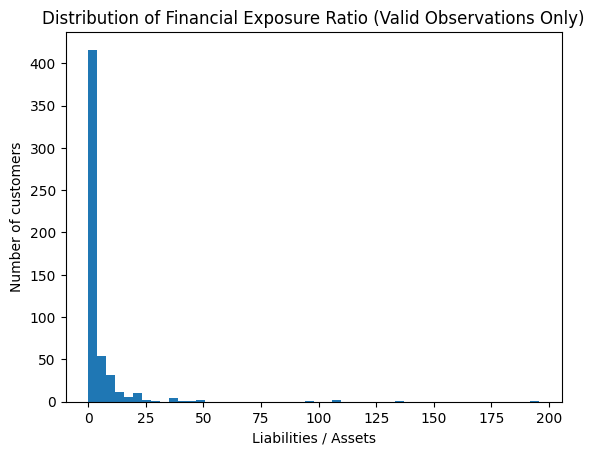

In [73]:
plt.hist(valid_ratio, bins=50)
plt.title("Distribution of Financial Exposure Ratio (Valid Observations Only)")
plt.xlabel("Liabilities / Assets")
plt.ylabel("Number of customers")
plt.show()


In [74]:
valid_ratio.describe()

count    545.000000
mean       4.814764
std       13.992942
min        0.013897
25%        0.485111
50%        1.440731
75%        3.681488
max      195.658633
Name: financial_exposure_ratio, dtype: float64

### - **Ratio vs Asset Presence**

In [75]:
financial_profile.head()

,client_id,asset_months_present,avg_assets_balance_eur,end_assets_balance_eur,liabilities_months_present,avg_liabilities_balance_eur,end_liabilities_balance_eur,has_assets,has_liabilities,financial_type,financial_exposure_ratio,asset_present,liability_present
0,CUST000001,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN,False,False
1,CUST000002,0.0,0.0,0.0,12.0,3816.380000,3662.404167,False,True,loan_only,NaN,False,True
2,CUST000003,0.0,0.0,0.0,12.0,5413.245833,5461.457500,False,True,loan_only,NaN,False,True
3,CUST000004,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN,False,False
4,CUST000005,0.0,0.0,0.0,0.0,0.000000,0.000000,False,False,inactive,NaN,False,False


**Note:**

`asset_present = False`: The customer has no savings (savings, time deposits, or investments). The average balance is 0.0.

`liability_present = False`: The customer has no loans (mortgages, credit cards, or other bank debt).

In [76]:
financial_profile["ratio_category"] = np.where(
    financial_profile["has_assets"] & financial_profile["has_liabilities"],
    "Defined",
    "Undefined (No Buffer or No Exposure)"
)

print(financial_profile["ratio_category"].value_counts(dropna=False))


ratio_category
Undefined (No Buffer or No Exposure)    9455
Defined                                  545
Name: count, dtype: int64


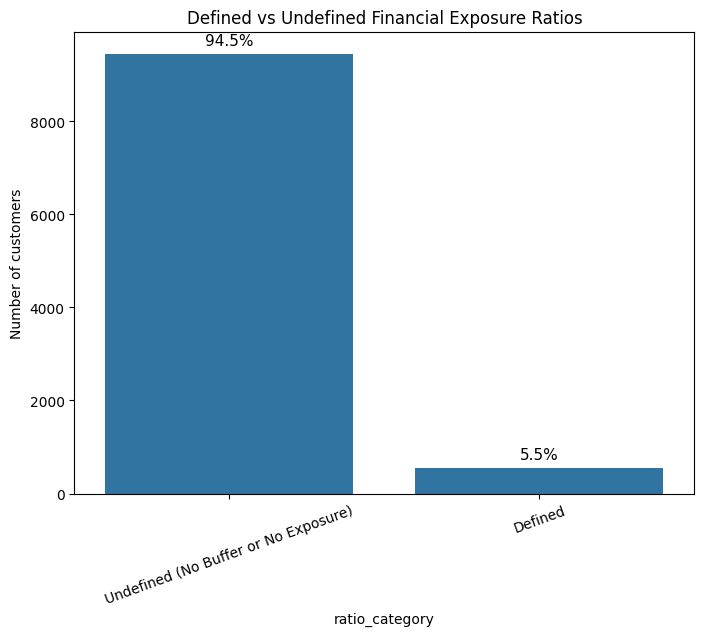

Total customers: 10000
ratio_category
Undefined (No Buffer or No Exposure)    9455
Defined                                  545
Name: count, dtype: int64


In [77]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='ratio_category', data=financial_profile, order=financial_profile["ratio_category"].value_counts(dropna=False).index)
plt.title("Defined vs Undefined Financial Exposure Ratios")
plt.ylabel("Number of customers")
plt.xticks(rotation=20)

# total number of each financial type
total = len(financial_profile)

# annotate percentage on each bar
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0, 4),
        textcoords='offset points')
plt.show()

print("Total customers:", len(customers))
print(financial_profile["ratio_category"].value_counts())


**Note:**

- Defined: customers with both observable assets and liabilities, allowing the computation of a financial exposure ratio.

- Undefined: customers lacking either assets or liabilities, resulting in structurally non-computable ratios.

**The ratio is introduced solely to characterise financial exposure feasibility at the population level and does not represent a risk assessment or credit evaluation.**


The distribution of customer financial exposure statuses is derived from the presence of observable assets and liabilities. 

The predominance of undefined ratios highlights the heterogeneity of financial engagement within the customer population, providing important context for subsequent behavioural and transactional analyses.


## **Product Ownership – Population View**

### **Data Dictionary for Leasing Agreements Table**

| Field                 | Description                              |
| --------------------- | ---------------------------------------- |
| carrying_amount       | Carrying amount on balance sheet         |
| client_id_fk          | Foreign key to `customers.client_id`     |
| lease_ccy             | Agreement currency                       |
| lease_status          | Lifecycle state of the lease (**Codes**) |
| orig_principal        | Total principal at origination           |
| outstanding_principal | Outstanding principal                    |
| snapshot_date         | Snapshot / entry date                    |



### **Data Dictionary for Life Insurance Table**

| Field         | Description                                 |
| ------------- | ------------------------------------------- |
| client_id     | Foreign key to `customers.client_id`        |
| next_premium  | Next monthly premium due                    |
| policy_ccy    | Policy currency                             |
| policy_status | Lifecycle / state of the policy (**Codes**) |
| snapshot_date | Snapshot / entry date                       |
| sum_insured   | Sum insured on the policy                   |


### **Data Dictionary for Pension Table**

| Field          | Description                                                                                            |
| -------------- | ------------------------------------------------------------------------------------------------------ |
| client_id_fk   | Foreign key to `customers.client_id`                                                                   |
| contrib_date   | Contribution date                                                                                      |
| contrib_status | **Codes:** active = contributing; '' = passive (no longer collecting); stopped = stopped due to reform |
| fund_code      | Pension fund identifier                                                                                |
| unit_qty       | Fund units acquired (quantity)                                                                         |


### **Data Dictionary for Property Insurance Table**

| Field               | Description                                                              |
| ------------------- | ------------------------------------------------------------------------ |
| agreement_status    | **Codes:** 0 = valid; −1 = not started; 1 = terminated; 2 = payment-free |
| client_id_fk        | Foreign key to `customers.client_id`                                     |
| cover_type_cd       | **Codes:** E = life; P = loan-payment insurance                          |
| premium_eur         | Recurring premium (EUR)                                                  |
| snapshot_date       | Snapshot / entry date                                                    |
| surrender_value_eur | Surrender value (EUR)                                                    |



In [78]:
# accessing dataframe leasing_agreements

leasing_agreements = dataframes['leasing_agreements']

loan_contract = leasing_agreements.copy()

leasing_agreements.head()

,carrying_amount,client_id_fk,lease_ccy,lease_status,orig_principal,outstanding_principal,snapshot_date
0,16554.02,CUST000015,EUR,enactment,21275.98,16462.85,2024-01-31
1,16050.14,CUST000015,EUR,enactment,21275.98,16231.47,2024-02-29
2,16085.72,CUST000015,EUR,valid,21275.98,16042.53,2024-03-31
3,15714.36,CUST000015,EUR,terminated,21275.98,15864.16,2024-04-30
4,16175.65,CUST000015,EUR,valid,21275.98,15737.45,2024-05-31


In [79]:
# accessing dataframe life_insurance

life_insurance = dataframes['life_insurance']

life = life_insurance.copy()

life_insurance.head()

,client_id,snapshot_date,policy_ccy,sum_insured,next_premium,policy_status
0,CUST000006,2024-01-31,EUR,63000,38.45,JOUS
1,CUST000006,2024-02-29,EUR,63000,38.45,JOUS
2,CUST000006,2024-03-31,EUR,63000,38.45,JOUS
3,CUST000006,2024-04-30,EUR,63000,38.45,JOUS
4,CUST000006,2024-05-31,EUR,63000,38.45,JOUS


In [80]:
# accessing dataframe pension
pension = dataframes['pension']

pen = pension.copy()

pension.head()


,client_id_fk,contrib_date,contrib_status,fund_code,unit_qty
0,CUST000001,2024-01-15,active,II_LUMINOR_004,21.8735
1,CUST000001,2024-02-09,active,II_LUMINOR_004,28.8287
2,CUST000001,2024-03-22,active,II_LUMINOR_004,26.7401
3,CUST000001,2024-04-24,active,II_LUMINOR_004,62.8636
4,CUST000001,2024-05-17,active,II_LUMINOR_004,58.5952


In [81]:
# accessing dataframe property_insurance
property_insurance = dataframes['property_insurance']

mortgage_in = property_insurance.copy()

property_insurance.head()

,agreement_status,client_id_fk,cover_type_cd,premium_eur,snapshot_date,surrender_value_eur
0,0,CUST000009,P,12.21,2024-01-31,0.04
1,0,CUST000009,P,12.21,2024-02-29,1.69
2,0,CUST000009,P,12.21,2024-03-31,2.90
3,0,CUST000009,P,12.21,2024-04-30,3.22
4,0,CUST000009,P,12.21,2024-05-31,4.96


In [82]:
print("Dimension leasing:", leasing_agreements.shape)
print("Dimension life insurance:", life_insurance.shape)
print("Dimension pension:", pension.shape)
print("Dimension property insurance:", property_insurance.shape)

Dimension leasing: (7442, 7)
Dimension life insurance: (8070, 6)
Dimension pension: (81347, 5)
Dimension property insurance: (7678, 6)


In [83]:
product_profile = customers[["client_id"]].copy()

# ownership flags (1/0)
product_profile["has_leasing"] = product_profile["client_id"].isin(leasing_agreements["client_id_fk"]).astype(int)
product_profile["has_life_insurance"] = product_profile["client_id"].isin(life_insurance["client_id"]).astype(int)
product_profile["has_pension"] = product_profile["client_id"].isin(pension["client_id_fk"]).astype(int)
product_profile["has_property_insurance"] = product_profile["client_id"].isin(property_insurance["client_id_fk"]).astype(int)

# count & label
product_cols = ["has_leasing", "has_life_insurance", "has_pension", "has_property_insurance"]

product_profile["product_count"] = product_profile[product_cols].sum(axis=1)


# categorise product ownership into three categories
product_profile["product_type"] = pd.cut(
    product_profile["product_count"],
    bins=[-1, 0, 1, 4],
    labels=["No Product", "Single Product", "Multi Product"]
)


In [84]:
product_profile.head()

,client_id,has_leasing,has_life_insurance,has_pension,has_property_insurance,product_count,product_type
0,CUST000001,0,0,1,0,1,Single Product
1,CUST000002,0,0,1,0,1,Single Product
2,CUST000003,0,0,1,0,1,Single Product
3,CUST000004,0,0,1,0,1,Single Product
4,CUST000005,0,0,1,0,1,Single Product


In [85]:
product_profile.shape

(10000, 7)

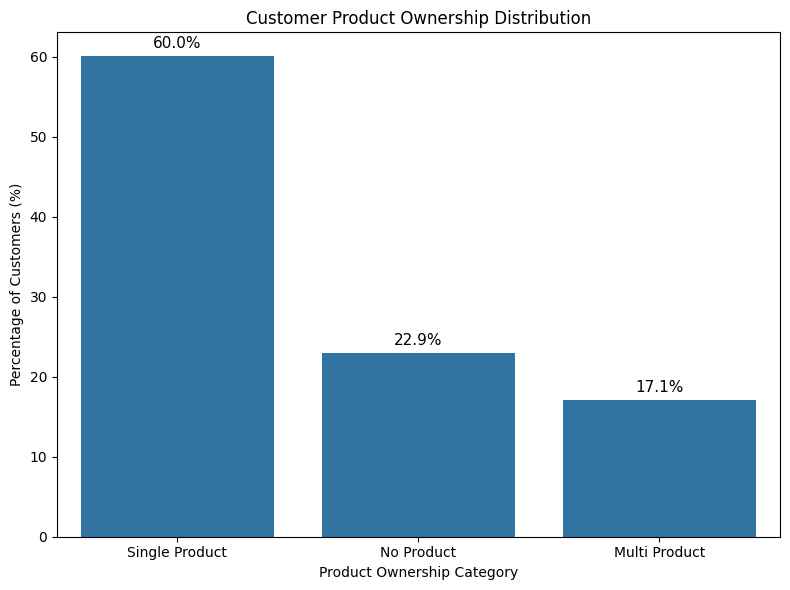

Total customers: 10000
product_type
Single Product    6003
No Product        2291
Multi Product     1706
Name: count, dtype: int64


In [86]:
product_dist = (
    product_profile["product_type"]
    .value_counts(normalize=True)
    .reset_index()
)

product_dist.columns = ["product_type", "percentage"]
product_dist["percentage"] = product_dist["percentage"] * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x="product_type",
    y="percentage",
    data=product_dist,
    order=product_dist.sort_values("percentage", ascending=False)["product_type"]
)

plt.title("Customer Product Ownership Distribution")
plt.xlabel("Product Ownership Category")
plt.ylabel("Percentage of Customers (%)")

# annotate percentage
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

print("Total customers:", len(product_profile))
print( product_profile['product_type'].value_counts())

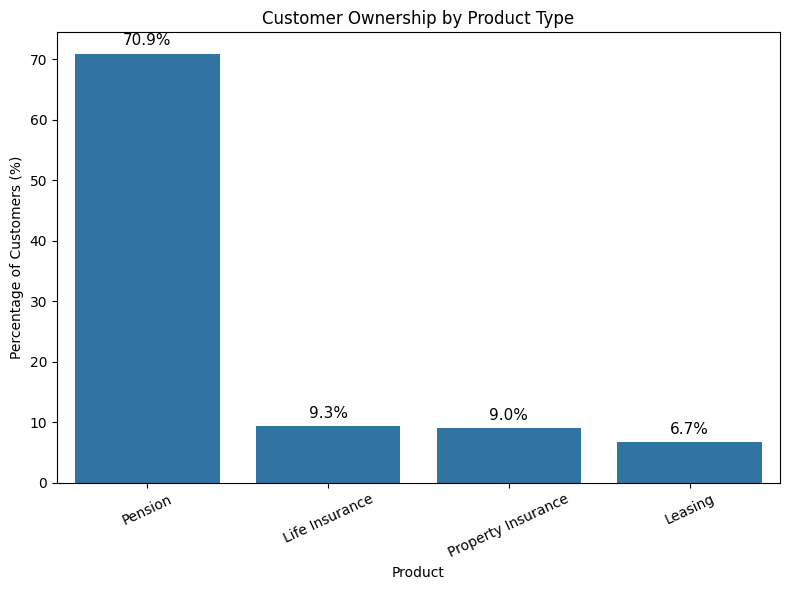

Total customers: 10000
Pension               7093
Life Insurance         931
Property Insurance     896
Leasing                665
dtype: int64


In [87]:
total_customers = len(product_profile)

product_pct = (
    product_profile[product_cols]
    .sum()
    .div(total_customers)
    .mul(100)
    .sort_values(ascending=False)
)

# mapping nama produk (ini yang kamu maksud "map")
product_name_map = {
    "has_leasing": "Leasing",
    "has_life_insurance": "Life Insurance",
    "has_pension": "Pension",
    "has_property_insurance": "Property Insurance"
}

product_pct_named = product_pct.rename(index=product_name_map)

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x=product_pct_named.index,
    y=product_pct_named.values
)

plt.title("Customer Ownership by Product Type")
plt.xlabel("Product")
plt.ylabel("Percentage of Customers (%)")
plt.xticks(rotation=25)

# annotate %
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

print("Total customers:", len(product_profile))
print(product_profile[product_cols].sum().rename(index=product_name_map).sort_values(ascending=False))

**Based on the data, most customers hold a single product, with pension products being the most prevalent across the customer population. Other products, such as insurance and leasing, are held by smaller proportions of customers.**

## **Transaction Activity (Behaviour) by Customer's Product Profile**

### - **Customer Transaction Aggregate**

This step is to validate customer activity based on transaction without product bias before we merge the customer profile with product profile.

In [88]:
customer_txn_summary = (
    transactions
    .groupby("client_id")
    .agg(
        txn_count=("txn_id", "count"),
        total_amount=("amount_eur", "sum"),
        avg_amount=("amount_eur", "mean")
    )
    .reset_index()
)

customer_txn_summary 


,client_id,txn_count,total_amount,avg_amount
0,CUST000001,81,15332.52,189.290370
1,CUST000002,40,30435.64,760.891000
2,CUST000003,211,44165.79,209.316540
3,CUST000004,96,21491.65,223.871354
4,CUST000005,4,2494.95,623.737500
...,...,...,...,...
9514,CUST009995,84,49044.87,583.867500
9515,CUST009996,65,9650.22,148.464923
9516,CUST009997,170,29614.32,174.201882
9517,CUST009999,198,25995.62,131.291010


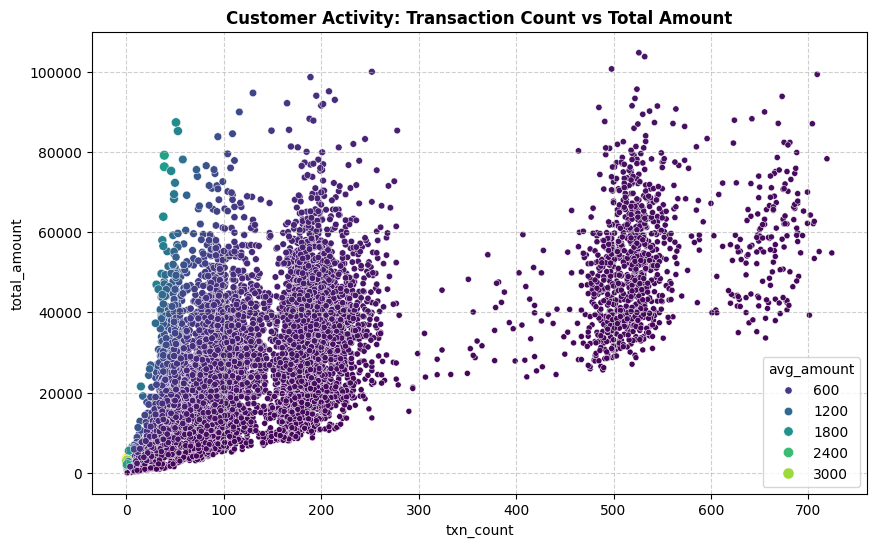

In [89]:
# 1. Scatter plot for customer activity

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_txn_summary , x='txn_count', y='total_amount', size='avg_amount', hue='avg_amount', palette='viridis')
plt.title('Customer Activity: Transaction Count vs Total Amount', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

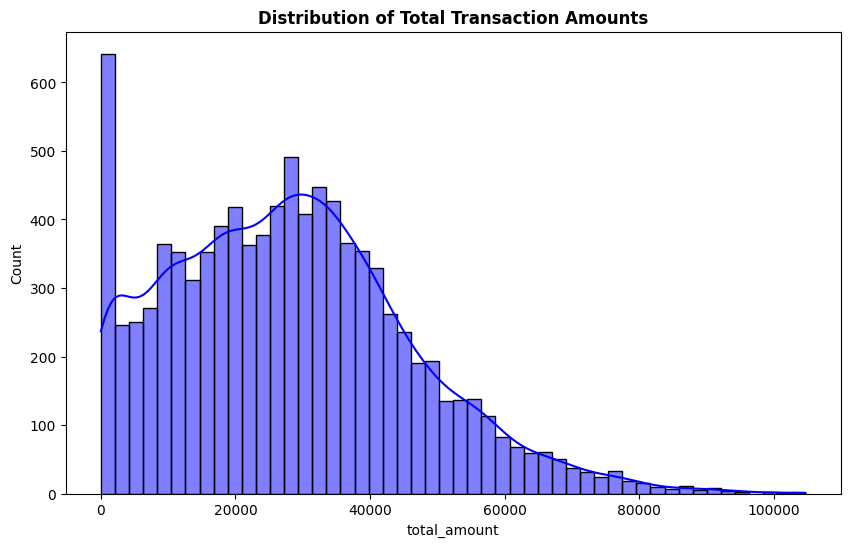

In [90]:
# 2. Distribution plot for total transaction amounts profil population
plt.figure(figsize=(10, 6))
sns.histplot(customer_txn_summary ['total_amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Total Transaction Amounts', fontweight='bold')
plt.show()

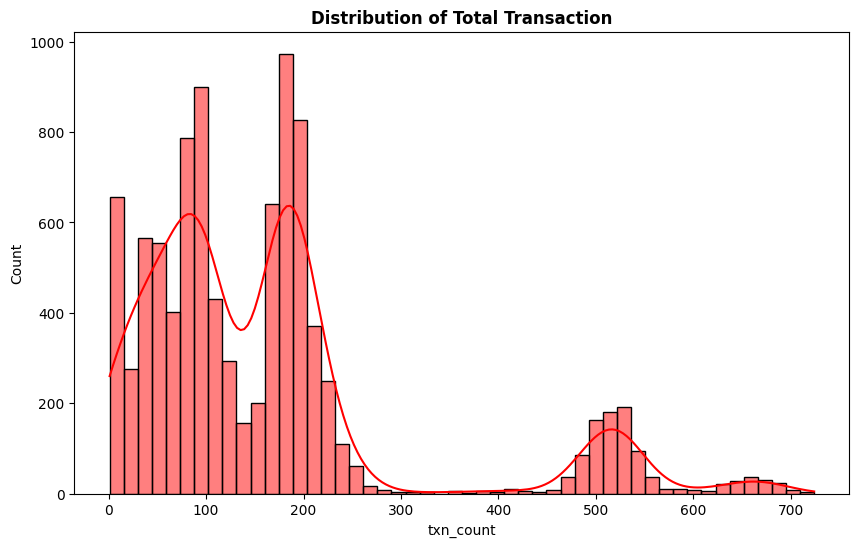

In [91]:
# 3. Distribution plot for total transaction profil population
plt.figure(figsize=(10, 6))
sns.histplot(customer_txn_summary ['txn_count'], bins=50, kde=True, color='red')
plt.title('Distribution of Total Transaction', fontweight='bold')
plt.show()

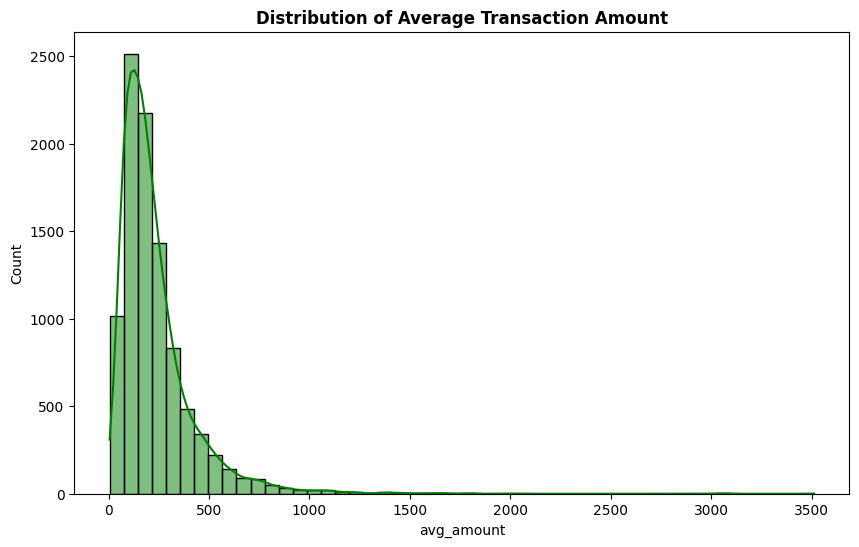

In [92]:
# 4. Distribution plot for average transaction profil population
plt.figure(figsize=(10, 6))
sns.histplot(customer_txn_summary ['avg_amount'], bins=50, kde=True, color='green')
plt.title('Distribution of Average Transaction Amount', fontweight='bold')
plt.show()

### - **Customer Transaction Aggregate x Product Profile**

In [93]:
customer_txn_product = (
    customer_txn_summary
    .merge(product_profile, on="client_id", how="left")
)

customer_txn_product

,client_id,txn_count,total_amount,avg_amount,has_leasing,has_life_insurance,has_pension,has_property_insurance,product_count,product_type
0,CUST000001,81,15332.52,189.290370,0,0,1,0,1,Single Product
1,CUST000002,40,30435.64,760.891000,0,0,1,0,1,Single Product
2,CUST000003,211,44165.79,209.316540,0,0,1,0,1,Single Product
3,CUST000004,96,21491.65,223.871354,0,0,1,0,1,Single Product
4,CUST000005,4,2494.95,623.737500,0,0,1,0,1,Single Product
...,...,...,...,...,...,...,...,...,...,...
9514,CUST009995,84,49044.87,583.867500,0,0,0,0,0,No Product
9515,CUST009996,65,9650.22,148.464923,0,0,1,0,1,Single Product
9516,CUST009997,170,29614.32,174.201882,0,0,0,0,0,No Product
9517,CUST009999,198,25995.62,131.291010,0,1,0,0,1,Single Product


### - **Transaction Contribution By Product Type (Customer Portfolio)**

Calculate average transaction made by customer profile and product profile

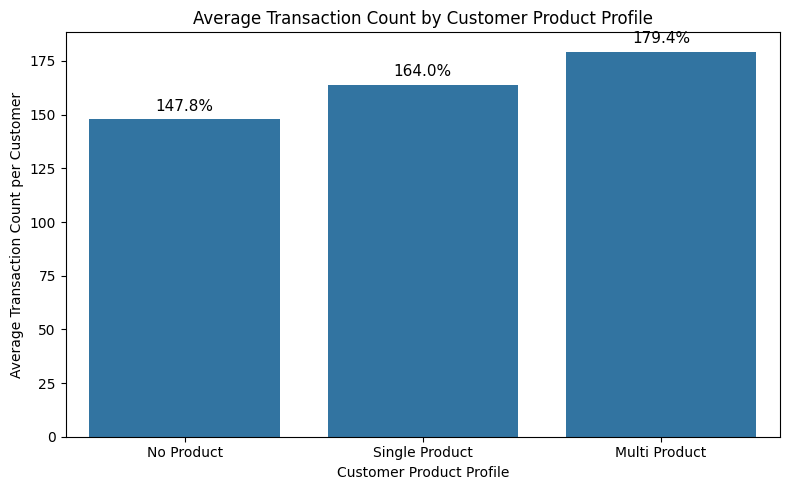

Total customers: 9519
product_type
Single Product    5719
No Product        2169
Multi Product     1631
Name: count, dtype: int64


In [94]:
profile_txn_stats = (
    customer_txn_product
    .groupby("product_type")
    .agg(
        avg_txn_count=("txn_count", "mean"),
        avg_total_amount=("total_amount", "mean")
    )
    .reset_index()
)


plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x="product_type",
    y="avg_txn_count",
    data=profile_txn_stats
)

plt.title("Average Transaction Count by Customer Product Profile")
plt.xlabel("Customer Product Profile")
plt.ylabel("Average Transaction Count per Customer")

# annotate %
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

print("Total customers:", len(customer_txn_product))
print(customer_txn_product["product_type"].value_counts())


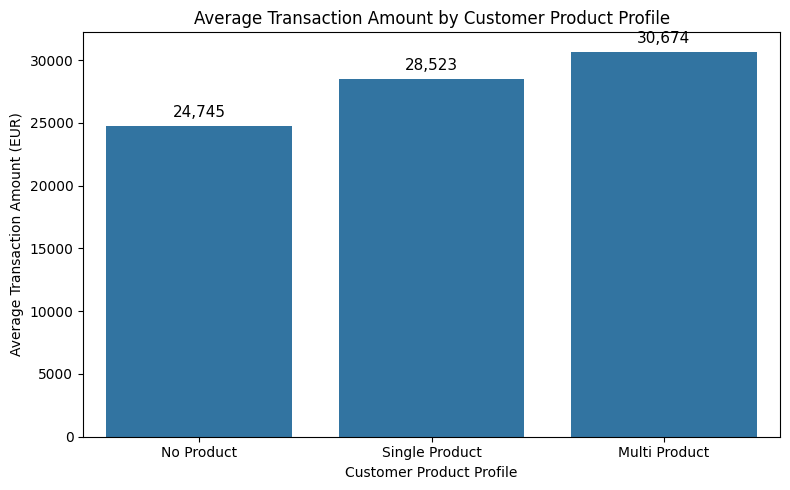

Total transactions: 1551068
Total customers: 9519
product_type
Single Product    5719
No Product        2169
Multi Product     1631
Name: count, dtype: int64


In [95]:
order = ["No Product", "Single Product", "Multi Product"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x="product_type",
    y="avg_total_amount",
    data=profile_txn_stats,
    order=[c for c in order if c in profile_txn_stats["product_type"].astype(str).unique()]
)

plt.title("Average Transaction Amount by Customer Product Profile")
plt.xlabel("Customer Product Profile")
plt.ylabel("Average Transaction Amount (EUR)")

# annotate EUR (NOT %)
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:,.0f}",  # contoh: 12,345
        (p.get_x() + p.get_width() / 2., value),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

print("Total transactions:", len(transactions))
print("Total customers:", customer_txn_product["client_id"].nunique())
print(customer_txn_product["product_type"].value_counts())


**Note:**

Based on the data above, not all customer have transaction. from 10.000 customers only 9.519 (95.19%) customers have transaction.

### **Mapping of Datasets Across the Three Lines of Defense**

| Line of Defense                          | Function                                                        | Dataset / Artefact                                | Key Fields Included                                                     | Purpose in the GRC Simulation                                                                                          |
| ---------------------------------------- | --------------------------------------------------------------- | ------------------------------------------------- | ----------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| **1LoD – IT (Raw Data Owner)**           | Maintain core banking data infrastructure                       | `transactions_2024`, `customers`, `life_insurance`, `property_insurance`, `leasing_agreements`, `pension`,`margin_assets`, `margin_liabilities`                 | Full transaction fields incl. IBAN, timestamps, PII                     | Represents the source of truth. No transformation, no interpretation.                                                  |
| **1LoD – Data Operations**               | Technical aggregation & feature engineering (no risk ownership) | `customer_day`, `transactions_labeled`            | client_id, date, daily metrics, baselines, ratios, suspiciousness_label | Prepares analytical artefacts in a rule-based but interpretation-limited manner. No governance judgement is performed. |
| **1LoD – Business Operations**           | Own and manage operational risk. Monitor & escalate.            | `customer_day` (operational view), `ops_case_log` | metrics, deviation ratios, suspiciousness_label                         | Performs deviation-based monitoring and escalation. Labels indicate operational anomaly, not confirmed fraud.          |
| **2LoD – Risk Management**               | Independent risk oversight & threshold governance               | `lod2_monthly`, `threshold_change_log`            | aggregated label counts, escalation ratios                              | Evaluates risk appetite alignment and trend stability. No transaction-level analysis performed.                        |
| **2LoD – Compliance**                    | Governance adherence review                                     | Compliance review artefacts                       | escalation summaries, documentation completeness                        | Ensures SOP alignment and policy compliance. No derivation of risk indicators.                                         |
| **3LoD – Internal Audit**                | Independent assurance                                           | `audit_sample`                                    | sampled cases, ratios, baselines, labels                                | Tests reproducibility, traceability, and control consistency across 1LoD and 2LoD.                                     |
| **Cross-Line (Limited Governance View)** | Information minimisation                                        | Derived views from `customer_day`                 | aggregated metrics and labels only                                      | Demonstrates restricted shareability and silo persistence in AS-IS state.                                              |


## **1LoD — IT Department**

Database owner (Core Banking View)

### **RAW Data IT — Baseline**

| Component       | Description                                                           |
| --------------- | --------------------------------------------------------------------- |
| **Role**        | IT (Technical data owner)                                             |
| **Input**       | Core banking system                                                   |
| **Output**      | Raw tables (`transactions_2024`, `customers`, `life_insurance`, etc.) |
| **Granularity** | Event-level (transaction-level)                                       |
| **Fields**      | All fields including IBAN, timestamps, PII                            |
| **Processing**  | None                                                                  |
| **Purpose**     | Source of truth (SoT)                                                 |


**NOTE:**
The data source is considered the most accurate, most authentic, and the primary reference for all other systems.
Key characteristics of a Source of Truth:

**1. Originality**
The data here has not been processed, filtered, or aggregated. This is raw data as is.

**2. Validity (Finality)**
If the data in system A differs from the data in the Source of Truth, then the data in system A is considered incorrect. All other systems must "mirror" or retrieve data from the SoT to be synchronized with it.

**3. Data Integrity**
This data includes all details (such as IBAN, timestamps, and PII). Derived data (such as in 1LoD or 2LoD) is usually summarized, so it is no longer a complete Source of Truth.

SoTs are important for Audit (3LoD) as a reference for checking truth. They do not hold the `original truth` from 1LoD and 2LoD, but only hold `processed data samples.`

## **Input: Core Banking System**

## **Output:**

### **Output Data Dimension: Dataset Overview (Raw IT Layer)**

| Dataset              | Rows    | Columns |
|----------------------|---------|---------|
| customers            | 10,000  | 9       |
| leasing_agreements   | 7,442   | 7       |
| life_insurance       | 8,070   | 6       |
| margin_assets        | 31,908  | 6       |
| margin_liabilities   | 22,839  | 6       |
| pension              | 81,347  | 5       |
| property_insurance   | 7,678   | 6       |
| transactions_2024    | 1,551,068 | 13    |

In [96]:
#recall raw data

print("\033[1m" + "Transactions Dataset:" + "\033[0m")
transactions_2024.head()

Transactions Dataset:


,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE
1,CUST000001,2024-01-12,13:32:11,TX00000002,online,D,EUR,88.83,88.83,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BEF6GRNF2ANPJCRMF5CIJI3W,NaN,EE
2,CUST000001,2024-01-22,18:37:34,TX00000003,card,D,EUR,11.79,11.79,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_2NPYIVWYTU6RB3EF2DPW5K2T,5816.0,EE
3,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE
4,CUST000001,2024-02-12,23:50:31,TX00000005,online,D,EUR,95.47,95.47,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BXJ2CJNGBHCMPJURBIU7RSLX,NaN,EE


In [97]:
print("\033[1m" + "Customers Dataset:" + "\033[0m")
customers.head()

Customers Dataset:


,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,postal_code,bank_reg_dt,age,age_group,tenure
0,CUST000001,H,Private,Parent,1977-11-19,M,EE,13075,2022-10-11,48,Mature,3
1,CUST000002,H,Private,Parent,1998-10-13,F,EE,81847,2018-05-18,27,Adult,7
2,CUST000003,H,Private,Parent,1971-09-07,F,EN,86527,2016-10-25,54,Mature,9
3,CUST000004,H,Private,Parent,1968-04-01,F,RU,13324,2023-10-15,57,Mature,2
4,CUST000005,H,Private,Parent,2006-08-15,F,RU,41926,2024-12-18,19,Young,1


In [98]:
print("\033[1m" + "Life Insurance Dataset:" + "\033[0m")
life_insurance.head()

Life Insurance Dataset:


,client_id,snapshot_date,policy_ccy,sum_insured,next_premium,policy_status
0,CUST000006,2024-01-31,EUR,63000,38.45,JOUS
1,CUST000006,2024-02-29,EUR,63000,38.45,JOUS
2,CUST000006,2024-03-31,EUR,63000,38.45,JOUS
3,CUST000006,2024-04-30,EUR,63000,38.45,JOUS
4,CUST000006,2024-05-31,EUR,63000,38.45,JOUS


In [99]:
print("\033[1m" + "Property Insurance Dataset:" + "\033[0m")
property_insurance.head()

Property Insurance Dataset:


,agreement_status,client_id_fk,cover_type_cd,premium_eur,snapshot_date,surrender_value_eur
0,0,CUST000009,P,12.21,2024-01-31,0.04
1,0,CUST000009,P,12.21,2024-02-29,1.69
2,0,CUST000009,P,12.21,2024-03-31,2.90
3,0,CUST000009,P,12.21,2024-04-30,3.22
4,0,CUST000009,P,12.21,2024-05-31,4.96


In [100]:
print("\033[1m" + "Leasing Agreements Dataset:" + "\033[0m")
leasing_agreements.head()

Leasing Agreements Dataset:


,carrying_amount,client_id_fk,lease_ccy,lease_status,orig_principal,outstanding_principal,snapshot_date
0,16554.02,CUST000015,EUR,enactment,21275.98,16462.85,2024-01-31
1,16050.14,CUST000015,EUR,enactment,21275.98,16231.47,2024-02-29
2,16085.72,CUST000015,EUR,valid,21275.98,16042.53,2024-03-31
3,15714.36,CUST000015,EUR,terminated,21275.98,15864.16,2024-04-30
4,16175.65,CUST000015,EUR,valid,21275.98,15737.45,2024-05-31


In [101]:
print("\033[1m" + "Pension Dataset:" + "\033[0m")
pension.head()

Pension Dataset:


,client_id_fk,contrib_date,contrib_status,fund_code,unit_qty
0,CUST000001,2024-01-15,active,II_LUMINOR_004,21.8735
1,CUST000001,2024-02-09,active,II_LUMINOR_004,28.8287
2,CUST000001,2024-03-22,active,II_LUMINOR_004,26.7401
3,CUST000001,2024-04-24,active,II_LUMINOR_004,62.8636
4,CUST000001,2024-05-17,active,II_LUMINOR_004,58.5952


In [102]:
print("\033[1m" + "Margin Assets Dataset:" + "\033[0m")
margin_assets.head()

Margin Assets Dataset:


,acct_ccy,avg_balance_eur,avg_interest_base_eur,client_id_fk,end_balance_eur,month_end
0,EUR,6378.58,6100.54,CUST000007,6433.63,2024-01-31
1,EUR,6485.76,4694.14,CUST000007,6221.45,2024-02-29
2,EUR,4843.42,3558.95,CUST000007,4951.52,2024-03-31
3,EUR,6292.46,5926.30,CUST000007,7147.96,2024-04-30
4,EUR,4846.27,3611.47,CUST000007,4760.32,2024-05-31


In [103]:
print("\033[1m" + "Margin Liabilities Dataset:" + "\033[0m")
margin_liabilities.head()

Margin Liabilities Dataset:


,avg_balance_eur,avg_interest_base_eur,client_id_fk,contract_ccy,end_balance_eur,month_end
0,4339.59,3797.14,CUST000002,EUR,3944.13,2024-01-31
1,4244.11,3489.67,CUST000002,EUR,4094.33,2024-02-29
2,4190.52,4054.46,CUST000002,EUR,4077.30,2024-03-31
3,3953.78,3678.45,CUST000002,EUR,3864.00,2024-04-30
4,4148.58,3939.64,CUST000002,EUR,3532.76,2024-05-31


**The level of data details (granuality) are available for all table.**

## **1LoD — Data Operations Department**

Data preparation & analytical enablement, no risk ownership

| Aspect               | Description                                                                                                                                                                                                                      |
| -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Input dataset(s)** | `transactions_2024`, `customers`                                                                                                                                                                                    |
| **Included fields**  | `client_id`, `date`, `time`, `txn_id`, `channel`, `d_c`, `trx_ccy`, `amount_eur`, `amount_orig` (Transaction dataset); `client_id`, `bank_reg_dt` (Customer dataset)                                                             |
| **Excluded fields**  | `acct_iban`, `counterparty_iban`, `mcc`, `merchant_country` (Transaction dataset); `birth_dt`, `postal_code`, `gender_cd`, `lang_pref`, `type_cd`, `segment`, `group_head_flg` (Customer dataset)                                |
| **Processing**       | Aggregate daily transactions → compute expanding baselines (`min_periods = 5`) → compute volatility (CV per customer over daily series) → calculate `ratio_velocity` and `ratio_value` → compute deviation metrics (`ratio − 1`) |
| **Output dataset**   | `customer_day` (indicator-ready dataset containing daily metrics, individualized baselines, volatility markers, and deviation ratios)                                                                                            |
| **Output artefact**  | Monitoring-ready analytical dataset (no interpretation, thresholding, or decision logic applied)                                                                                                                                 |

### **Reduction Across Data Flow**

1. **Transaction Dataset Transformation**

| Layer                          | Rows      | Columns | Description                                                            |
| ------------------------------ | --------- | ------- | ---------------------------------------------------------------------- |
| **Raw IT – transactions_2024** | 1,551,068 | 13      | Full event-level dataset including PII and counterparty fields         |
| **DataOps – Selected Input**   | 1,551,068 | 9       | PII and counterparty-related fields removed for analytical preparation |

**Column Reduction: 13 → 9 (30.8% reduction)**

2. **Customer Dataset Transformation**

| Layer                        | Rows   | Columns | Description                                                       |
| ---------------------------- | ------ | ------- | ----------------------------------------------------------------- |
| **Raw IT – customers**       | 10,000 | 9       | Full customer profile including demographic attributes            |
| **DataOps – Selected Input** | 10,000 | 2       | Only structural identifiers retained (`client_id`, `bank_reg_dt`) |

**Column Reduction: 9 → 2 (77.8% reduction)**

> The Data Operations department implements data flow practices that prioritize structural data minimization before processing. This approach allows for the generation of aggregate data for delivery to other departments while maintaining the original row-level granularity of the raw data. Additionally, attribute-level compression significantly reduces the exposure of sensitive and non-critical fields, representing the first instance of structural abstraction in the data flow.

## **Input dataset with field Included only:**

In [104]:
transaction.columns

Index(['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy',
       'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc',
       'merchant_country'],
      dtype='object')

In [105]:
customer.columns

Index(['client_id', 'type_cd', 'segment', 'group_head_flg', 'birth_dt',
       'gender_cd', 'lang_pref', 'postal_code', 'bank_reg_dt'],
      dtype='object')

In [106]:
# transaction dataset with removed fields

transaction[['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig']].head()

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09
1,CUST000001,2024-01-12,13:32:11,TX00000002,online,D,EUR,88.83,88.83
2,CUST000001,2024-01-22,18:37:34,TX00000003,card,D,EUR,11.79,11.79
3,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77
4,CUST000001,2024-02-12,23:50:31,TX00000005,online,D,EUR,95.47,95.47


In [107]:
# customer dataset with removed fields (optional if needed)

customer[['client_id', 'bank_reg_dt']].head()

,client_id,bank_reg_dt
0,CUST000001,2022-10-11
1,CUST000002,2018-05-18
2,CUST000003,2016-10-25
3,CUST000004,2023-10-15
4,CUST000005,2024-12-18


## **Data Preprocessing:**

Aggregate daily transactions → compute expanding baselines (min_periods = 5) → compute volatility (CV per customer over daily series) → calculate ratio_velocity and ratio_value → compute deviation metrics (ratio − 1)

### - **Customer Transaction Identification: customers' unstable transaction activities**

This step aims to validate if there is customers with unstable transaction as the illustration given above related to **``Illustrative Examples: Application of Tolerance Margins at the Customer Level``**.

By applying **Coefficient of Variation (CV)** we will measure how customer transaction activities "spread out" in the data relative to its average to find if there is customers' unstable transaction activities. The purpose of this step is not to classify risk, but to validate the existence of customers whose transaction behavior naturally exhibits higher variability, which is an important consideration when defining baseline assumptions and tolerance margins.

To assess transaction stability at the customer level, the Coefficient of Variation (CV) is applied to customer-specific transaction metrics. The CV measures how dispersed transaction activity is relative to its average level, allowing the identification of customers whose behavior fluctuates substantially over time.

The Coefficient of Variation is calculated as:

$$CV = \left( \frac{\sigma}{\mu} \right) \times 100$$


where

$\sigma$ represents the standard deviation of a customer’s transaction activity, and

$\mu$ represents the mean of that activity.


**Why Using CV?** 

CV allows to compare the "volatility" or "instability" of two groups that have totally different units or scales. In some contexts, the CV may be expressed as a percentage by multiplying the ratio by 100; however, in this study the ratio form is sufficient for comparative purposes.


The CV is particularly suitable for this analysis because it enables the comparison of behavioral variability across customers, even when customers differ significantly in transaction frequency or transaction magnitude. Unlike absolute measures, the CV captures relative instability, making it appropriate for identifying customers whose transaction patterns are less consistent over time.

**In the context of this study, the CV supports three relevant analytical objectives:**

- Comparing different scales: Customers may have very different transaction volumes or frequencies, yet still be comparable in terms of relative variability.

- Assessing behavioral consistency: Higher CV values indicate less stable transaction behavior, which is relevant when evaluating baseline formation and tolerance margins.

- Supporting methodological validation: Identifying unstable customers allows the robustness of baseline assumptions (e.g., minimum observation requirements) to be evaluated under non-ideal, real-world conditions.

This step therefore provides an empirical foundation for later methodological choices, such as the selection of baseline parameters, without introducing additional complexity into the labeling or governance framework.


### - **Customer Transaction Per Day**

In [108]:
customer_day = (
    transactions
    .dropna(subset=["client_id", "date"])
    .groupby(["client_id", "date"], as_index=False)
    .agg(
        daily_txn_count=("txn_id", "count"),
        daily_total_amount=("amount_eur", "sum"),
        daily_avg_amount=("amount_eur", "mean")
    )
)

customer_day.head()


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount
0,CUST000001,2024-01-12,1,88.83,88.830
1,CUST000001,2024-01-15,1,37.68,37.680
2,CUST000001,2024-01-16,1,28.32,28.320
3,CUST000001,2024-01-19,1,57.14,57.140
4,CUST000001,2024-01-22,2,105.37,52.685


### - **Customer-Day Sorting (Customer Transaction Per Day)**

In [109]:
customer_day = customer_day.sort_values(
    ["client_id", "date"]
).reset_index(drop=True)

customer_day.head()


,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount
0,CUST000001,2024-01-12,1,88.83,88.830
1,CUST000001,2024-01-15,1,37.68,37.680
2,CUST000001,2024-01-16,1,28.32,28.320
3,CUST000001,2024-01-19,1,57.14,57.140
4,CUST000001,2024-01-22,2,105.37,52.685


### - **Coefficient Variation Per Customer**

In [110]:
cv_per_customer = (
    customer_day
    .groupby("client_id")["daily_txn_count"]
    .agg(["mean", "std"])
)

cv_per_customer["cv"] = cv_per_customer["std"] / cv_per_customer["mean"]


In [111]:
cv_per_customer.head()

,mean,std,cv
client_id,,,
CUST000001,1.080000,0.273120,0.252889
CUST000002,1.000000,0.000000,0.000000
CUST000003,1.241176,0.505073,0.406931
CUST000004,1.116279,0.357067,0.319872
CUST000005,1.333333,0.577350,0.433013


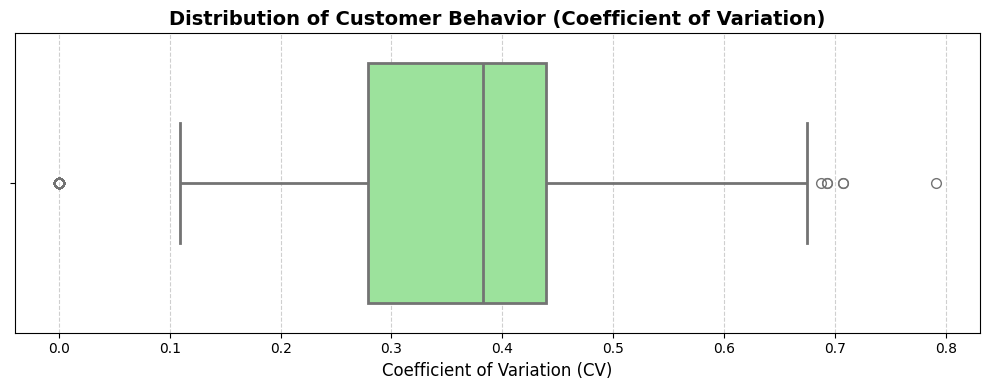

In [112]:
# Plotting
plt.figure(figsize=(10, 4))
sns.boxplot(x=cv_per_customer["cv"], color='lightgreen', fliersize=7, linewidth=2)
plt.title('Distribution of Customer Behavior (Coefficient of Variation)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient of Variation (CV)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
#plt.savefig('customer_behavior_boxplot.png')
#print("Boxplot saved as customer_behavior_boxplot.png")

**Intepretation of The Box Plot:**

The boxplot identifies distinct behavioral patterns among the customer base. 

- The majority of transactions fall within the normal baseline (CV 0.28 – 0.44), several outliers are detected beyond the 0.70 threshold. These outliers represent **`high-volatility`** accounts that deviate significantly from **`standard transaction frequencies`**.
-
- These data will prioritized for automated escalation to the Second Line of Defense (Compliance) for further investigation, as they may indicate suspicious structuring or anomalous movement of funds. The Compliance Department need human judgement by checking customer profile **(from Asset vs. Liability Presence table)** for customer with **CV ~0.8**.

## **Print The Data Based on The Graph**

In [113]:
# 1. calculate Quartile 1 (25%) and Quartile 3 (75%)
Q1 = cv_per_customer["cv"].quantile(0.25)
Q3 = cv_per_customer["cv"].quantile(0.75)
IQR = Q3 - Q1

# 2. define Outlier Boundary Anomaly threshold)
# Formula: Q3 + 1.5 * IQR
upper_bound = Q3 + (1.5 * IQR)

# 3. Filtering customer in the outlier threshold
outliers = cv_per_customer[cv_per_customer["cv"] > upper_bound]

# 4. Print the result
print(f"Threshold for Anomaly (Upper Bound): {upper_bound:.4f}")
print(f"Total Customers: {len(cv_per_customer)}")
print(f"Number of Outliers detected: {len(outliers)}")
print(f"Percentage of Anomalies: {(len(outliers)/len(cv_per_customer))*100:.22f}%")

# Menampilkan 5 nasabah paling mencurigakan (CV tertinggi)
print("\033[1m" + "\nTop 10 High-Risk Customers (Outliers):"+"\033[1m")
print(outliers.sort_values(by='cv', ascending=False).head(10))

Threshold for Anomaly (Upper Bound): 0.6795
Total Customers: 9519
Number of Outliers detected: 6
Percentage of Anomalies: 0.0630318310746927207289%

Top 10 High-Risk Customers (Outliers):
                mean       std        cv
client_id                               
CUST000723  2.200000  1.740279  0.791036
CUST003873  2.000000  1.414214  0.707107
CUST005624  2.000000  1.414214  0.707107
CUST006642  1.666667  1.154701  0.692820
CUST007500  1.666667  1.154701  0.692820
CUST000992  1.952381  1.342593  0.687669


**Intepretation:**

1LoD (Operations): Use CV to filter which customers should appear on the "Alert" dashboard.

2LoD (Risk/Compliance): Define a threshold. For example: "All customers with CV > 0.4 should be investigated."

3LoD (Audit): Test whether the system correctly calculates this variation using the synthetic data (SDG).

Conclusion: This table is how you transform raw data (Raw IT) into Risk Indicators that business people can understand.

### **Identification of Customers with Irregular Transaction Patterns**

The identified unstable customer exhibits a **Coefficient of Variation (CV) of 0.439**, indicating that the customer’s transaction activity varies by approximately **44%** relative to its average level. This level of variability reflects an irregular but plausible transaction pattern, rather than extreme or anomalous behavior.

**Transaction Pattern Categories:**
* **CV < 0.2**: Regular transaction behavior
* **CV 0.2 – 0.4**: Moderately variable transaction behavior
* **CV > 0.4**: Irregular transaction behavior

> **Note:** This categorization is used solely to distinguish levels of natural behavioral variability and does not represent a risk classification.
> Low CV (close to 0): Customer behavior is stable and predictable. High CV (> 0.4): Customer behavior is volatile.


### **Calibration of the Minimum Observation Parameter (`min_periods`)**

The parameter defining the minimum number of historical observations (`min_periods`) in the expanding mean approach is calibrated using customers with irregular transaction behavior. This choice is intentional, as customers with higher variability make the trade-off between **baseline stability** and **responsiveness** more visible.

#### **Calibration Logic**
* **Stable Patterns:** For customers with stable transaction patterns, different values of `min_periods` tend to produce similar baseline behavior.
* **Irregular Patterns:** In contrast, for irregular customers, smaller values lead to overly reactive and noisy baselines, while larger values delay baseline formation.

As a result, irregular customers provide the most informative cases for evaluating **baseline robustness**.

#### **Implementation**
Although the calibration is informed by high-variability customers, the selected `min_periods` value is **applied uniformly** across the dataset. This ensures methodological simplicity while maintaining a conservative and robust global parameter suitable for the broader customer population.

### **Reference Customer (Irregular) - Only for Validation to Define** **`min_periods value`**

In [114]:
unstable_customers = cv_per_customer["cv"].quantile(0.75)
unstable_customers


0.43922408404800495

In [115]:
# to get irregular customer as a stress case
ref_customer = (
    cv_per_customer
    .sort_values("cv", ascending=False)
    .index[0]
)

ref_customer


'CUST000723'

### **Customer-day of Reference Customer (Irregular)**

In [116]:
tmp = (
    customer_day
    .loc[customer_day["client_id"] == ref_customer]
    .sort_values("date")
    .copy()
)


In [117]:
tmp.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount
78184,CUST000723,2024-12-10,1,321.54,321.5400
78185,CUST000723,2024-12-11,2,44.76,22.3800
78186,CUST000723,2024-12-12,4,141.35,35.3375
78187,CUST000723,2024-12-14,1,30.18,30.1800
78188,CUST000723,2024-12-16,1,24.58,24.5800


### **Comparing ``min_periods`` value for Reference Customer (Irregular)**

> the comparation for finding ``min_periods``.

Candidate values of 3, 5, and 7 observations were selected to represent progressively increasing baseline stability requirements. These values are not chosen due to numerical parity, but to illustrate the trade-off between responsiveness and stability across meaningfully different minimum observation thresholds.

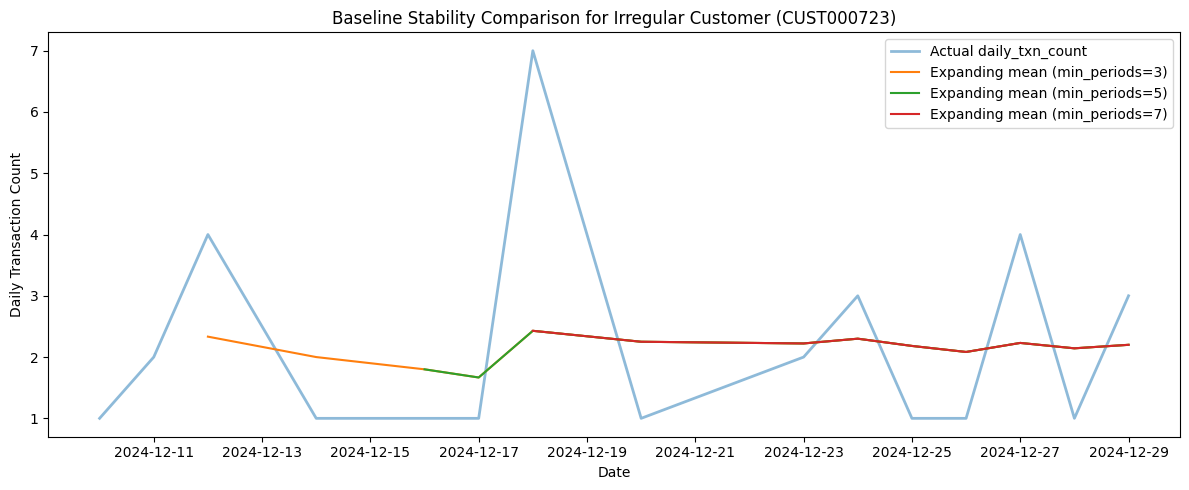

In [118]:
candidates = [3, 5, 7]

for m in candidates:
    tmp[f"baseline_txn_count_m{m}"] = (
        tmp["daily_txn_count"]
        .expanding(min_periods=m)
        .mean()
    )


plt.figure(figsize=(12, 5))

plt.plot(tmp["date"], tmp["daily_txn_count"],
         label="Actual daily_txn_count", alpha=0.5, linewidth=2)

for m in candidates:
    plt.plot(
        tmp["date"],
        tmp[f"baseline_txn_count_m{m}"],
        label=f"Expanding mean (min_periods={m})"
    )

plt.title(f"Baseline Stability Comparison for Irregular Customer ({ref_customer})")
plt.xlabel("Date")
plt.ylabel("Daily Transaction Count")
plt.legend()
plt.tight_layout()
plt.show()



The graph illustrates the effect of different minimum observation requirements on baseline construction for a customer with irregular transaction behavior. When a small minimum threshold (min_periods = 3) is applied, the baseline becomes overly sensitive to short-term fluctuations, particularly during transaction spikes. Conversely, a larger threshold (min_periods = 7) results in delayed baseline formation and reduced coverage during the early observation period.

A minimum of five observations provides a balanced trade-off between stability and responsiveness. The resulting baseline smooths short-term volatility while remaining sufficiently adaptive to underlying behavioral changes. **This supports the selection of min_periods = 5 as a conservative and robust global parameter for baseline construction.**

### - **Customer Specific Baseline - Based on Transactions**

Baseline values are computed using an expanding mean approach with a minimum number of historical observations. This ensures that deviations are only assessed once sufficient customer-specific behavioral history is available, reducing noise and preventing premature labeling.

In [119]:
customer_day["baseline_txn_count"] = (
    customer_day
    .groupby("client_id")["daily_txn_count"]
    .transform(lambda s: s.expanding(min_periods=5).mean())
)

customer_day["baseline_total_amount"] = (
    customer_day
    .groupby("client_id")["daily_total_amount"]
    .transform(lambda s: s.expanding(min_periods=5).mean())
)


customer_day["baseline_avg_amount"] = (
    customer_day
    .groupby("client_id")["daily_avg_amount"]
    .transform(lambda s: s.expanding(min_periods=5).mean())
)



In [120]:
customer_day.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount
0,CUST000001,2024-01-12,1,88.83,88.830,NaN,NaN,NaN
1,CUST000001,2024-01-15,1,37.68,37.680,NaN,NaN,NaN
2,CUST000001,2024-01-16,1,28.32,28.320,NaN,NaN,NaN
3,CUST000001,2024-01-19,1,57.14,57.140,NaN,NaN,NaN
4,CUST000001,2024-01-22,2,105.37,52.685,1.2,63.468,52.931


**Explanation for NaN values in the customer baseline:**

As I mentioned above, the transaction observation uses an expanded mean with ``minimum period = 5``, so it means that in the first 4 recorded transaction histories, the data has not been labeled because the baseline is not yet stable, and we can see that in the fifth transaction history, the label has been given.

**Intepretation for the table (mentioned above)**

> A typical customer makes about 1.2 transactions daily, averaging 63,468 euros.

In [121]:
# to check baseline

customer_day[[
    "client_id", "date",
    "daily_txn_count", "baseline_txn_count",
    "daily_total_amount", "baseline_total_amount"
]].head(10)


,client_id,date,daily_txn_count,baseline_txn_count,daily_total_amount,baseline_total_amount
0,CUST000001,2024-01-12,1,NaN,88.83,NaN
1,CUST000001,2024-01-15,1,NaN,37.68,NaN
2,CUST000001,2024-01-16,1,NaN,28.32,NaN
3,CUST000001,2024-01-19,1,NaN,57.14,NaN
4,CUST000001,2024-01-22,2,1.200000,105.37,63.468000
5,CUST000001,2024-01-25,1,1.166667,1049.09,227.738333
6,CUST000001,2024-02-12,1,1.142857,95.47,208.842857
7,CUST000001,2024-02-16,1,1.125000,25.52,185.927500
8,CUST000001,2024-02-23,1,1.111111,994.77,275.798889
9,CUST000001,2024-03-02,1,1.100000,28.86,251.105000


**The Result Intepretation**

If we comparing the table above, the first table only show the sample data in the **first 5 days** as the baseline of observation. However, in the next table the information evolve dinamically, for example customer `CUST000001`makes about 1.2 transactions daily, averaging 63,468 euros in the first five transaction in January, but until the last transaction in January the average transaction updated, and it adjusted based on customer transaction behaviour which depend on new activity to become about 1.1 transactions daily, averaging 227.738333 euros because there is a high transaction 1049.09 euros. This mechanism facilitates natural adaptation to behavioral changes without manual recalibration. Consequently, anomaly detection becomes more personalized and does not rely on rigid global averages.	


To translate these adaptive indicators into operational signals, a rule-based threshold trigger is introduced:

> If `daily_total_amount / baseline_total_amount > 3.0 → auto_red_flag = 1`

This flag is generated automatically within the **Data Operations layer as a computational trigger** but does not represent a confirmed **suspicion or risk judgement**. It is a system-generated indicator designed to support operational triage. (calculate after calculating deviation ratio, thhis placed as Trigger Layer).

**This `customer_day` table used:**

- to understand the business operation logic about the suspicious transaction case

- as the baseline for the next step to do labeling with deviation deviation as an early warning if there is suspicious transaction activity. (operational monitoring)

## **Print Document Original Before Calculate Deviation Ratio**
---
**Customer-day**
Customer-day dataset before calculating deviation ratio, containing only Customer Specific Baseline - Based on Transactions

Baseline values are computed using an expanding mean approach with a minimum number of historical observations. This ensures that deviations are only assessed once sufficient customer-specific behavioral history is available, reducing noise and preventing premature labeling.

In [122]:
customer_day.to_csv(r'D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/customer_day_no deviation.csv', index=False)

## **Calculate Deviation Ratio**

In [123]:
customer_day.columns

Index(['client_id', 'date', 'daily_txn_count', 'daily_total_amount',
       'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount',
       'baseline_avg_amount'],
      dtype='object')

In [124]:
# Avoid division by zero (set baseline 0 -> NaN first to avoid infinity result)

customer_day["baseline_txn_count"] = customer_day["baseline_txn_count"].replace(0, np.nan)
customer_day["baseline_total_amount"] = customer_day["baseline_total_amount"].replace(0, np.nan)

In [125]:
customer_day["ratio_velocity"] = (
    customer_day["daily_txn_count"] /
    customer_day["baseline_txn_count"]
)

customer_day["ratio_value"] = (
    customer_day["daily_total_amount"] /
    customer_day["baseline_total_amount"]
)

In [126]:
customer_day[["client_id", "ratio_velocity", "ratio_value"]].head(10)

,client_id,ratio_velocity,ratio_value
0,CUST000001,NaN,NaN
1,CUST000001,NaN,NaN
2,CUST000001,NaN,NaN
3,CUST000001,NaN,NaN
4,CUST000001,1.666667,1.660207
5,CUST000001,0.857143,4.606559
6,CUST000001,0.875000,0.457138
7,CUST000001,0.888889,0.137258
8,CUST000001,0.900000,3.606867
9,CUST000001,0.909091,0.114932


### **Group deviation (Normal / Elevated / Significant)**

In [127]:
def deviation_group(r):
    if pd.isna(r):
        return np.nan
    elif r <= 1.2:
        return "Normal"
    elif r <= 2.0:
        return "Elevated"
    else:
        return "Significant"


customer_day["velocity_severity"] = customer_day["ratio_velocity"].apply(deviation_group)
customer_day["value_severity"] = customer_day["ratio_value"].apply(deviation_group)

customer_day[["velocity_severity", "value_severity"]].value_counts()

velocity_severity  value_severity
Normal             Normal            718664
Elevated           Normal            125369
Normal             Significant        95869
                   Elevated           38575
Elevated           Significant        33529
                   Elevated           19878
Significant        Normal             18892
                   Significant        11181
                   Elevated            7445
Name: count, dtype: int64

### **Velocity Severity vs Value Severity**

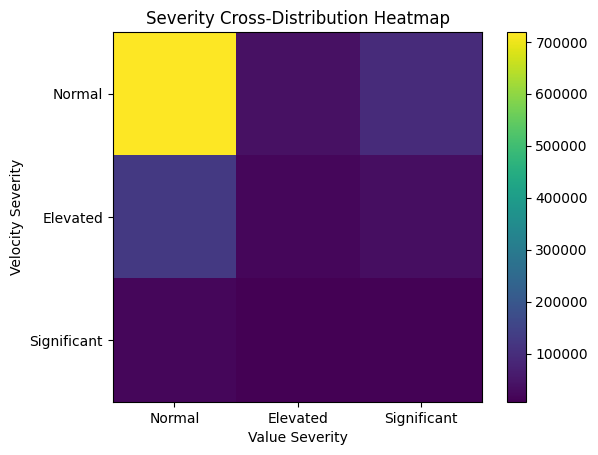

In [128]:
# Cross-tab
heatmap_data = pd.crosstab(
    customer_day["velocity_severity"],
    customer_day["value_severity"]
)

# Ensure consistent ordering
order = ["Normal", "Elevated", "Significant"]
heatmap_data = heatmap_data.reindex(index=order, columns=order)

plt.figure()
plt.imshow(heatmap_data)
plt.colorbar()

plt.xticks(range(len(order)), order)
plt.yticks(range(len(order)), order)

plt.xlabel("Value Severity")
plt.ylabel("Velocity Severity")
plt.title("Severity Cross-Distribution Heatmap")

plt.show()


## **Auto red flag — rule trigger**

``daily_total_amount / baseline_total_amount > 3.0 → auto_red_flag = 1``

In [129]:
customer_day["auto_red_flag"] = np.where(
    customer_day["ratio_value"].notna() & 
    (customer_day["ratio_value"] > 3.0),
    1,
    np.nan
)

## **Output dataset - 1LoD Data Operations:**

`customer_day` (indicator-ready dataset containing daily metrics, individualized baselines, volatility markers, and deviation ratios)

**Output artefact: 	Monitoring-ready analytical dataset (no interpretation, thresholding, or decision logic applied)**

In [130]:
customer_day.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag
0,CUST000001,2024-01-12,1,88.83,88.830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CUST000001,2024-01-15,1,37.68,37.680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CUST000001,2024-01-16,1,28.32,28.320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CUST000001,2024-01-19,1,57.14,57.140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CUST000001,2024-01-22,2,105.37,52.685,1.2,63.468,52.931,1.666667,1.660207,Elevated,Elevated,NaN


**This `customer_day` table used:**

- to understand the daily transaction summary via daily aggregation

- operational baseline input

- feature engineering (from table transaction & customer)

In [131]:
customer_day.shape

(1106264, 13)

### **Map to suspiciousness label (Low / Medium / High)**


## **DataOps Transformation Output**

``Raw IT → DataOps (Structural & Semantic Transformation)``

| Dimension                | Raw IT (Input)                | DataOps (Output: `customer_day`) | Structural Change                  |
| ------------------------ | ----------------------------- | -------------------------------- | ---------------------------------- |
| **Granularity**          | Event-level (transaction)     | Customer-day aggregation         | Event → Aggregated                 |
| **Rows**                 | 1,551,068                     | 1.106.264 number of customer-days| Transaction → Temporal aggregation |
| **Columns**              | 9 selected input fields       | 12 data engineered fields        | Feature expansion                  |
| **PII Exposure**         | Partial (identifier retained) | No direct PII                    | Privacy minimisation               |
| **Computation Layer**    | None                          | Baseline, CV, Ratios             | Analytical enrichment              |
| **Interpretation Layer** | None                          | Severity grouping, trigger       | Indicator abstraction              |
| **Traceability**         | Full (before minimisation)    | Reduced                          | Counterparty loss                  |



## **GAP vs Raw IT in The 1LOD - Data Operation**


Event-level → Aggregated

PII → Removed

Interpretation layer → Added

Indicator (ratios + severity + trigger) → Added

Loss of → Counterparty traceability


**Note:**

Due to gaps such as the lack of counterparty traceability and event-level data, investigation teams at the first line of defense (1LoD) or second line of defense (2LoD) do not have a complete view when examining suspicious transactions. Consequently, they are often required to make ad hoc data requests to the IT department to trace necessary information because the data presented to them is incomplete, showing only the final results. This situation creates a "Data Request Bottleneck" and leads to "Operational Silos." As a result, investigations are delayed, and the workload for the IT department increases.


## **1LoD — Business Operations Department**

Risk owner, operational monitoring & escalation

| Aspect                | Description                                                                                                                                                                                                                            |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Input dataset(s)**  | `customer_day` (indicator-level dataset from Data Operations)                                                                                                                                                                 |
| **Included fields**   | `client_id`, `date`, `daily_txn_count`, `daily_total_amount`, `daily_avg_amount`, `ratio_velocity`, `ratio_value`, `velocity_severity`, `value_severity`, `auto_red_flag`                                                              |
| **Excluded fields**   | `baseline_txn_count`, `baseline_total_amount`, transaction-level attributes (`txn_id`, `counterparty_iban`, `mcc`, `merchant_country`)                                                                                                 |
| **Processing**        | Monitor severity indicators and trigger flags → review contextual information (if required) → assign `ops_disposition` (dismiss / escalate / under review) → document rationale. No recomputation of baselines or ratios is performed. |
| **Output dataset**    | `ops_case_log` (case-level decision record)                                                                                                                                                                                            |
| **Output artefact**   | Operational case management log (triage decision layer) with optional audit documentation support.                                                                                                                                                                             |
| **Data Access Scope** | Aggregated customer-day level only        

### **DataOps → Business Operations (Role-Based Reduction)**

| Dimension | DataOps Output (`customer_day`) | Business Ops View (`customer_day_ops_view`) | Structural Change |
|------------|----------------------------------|--------------------------------------------|-------------------|
| **Granularity** | Customer-day aggregation | Customer-day aggregation | No change |
| **Rows** | 1,106,264 customer-days | 1,106,264 customer-days | No reduction |
| **Columns** | 12 engineered fields | 10 operational fields | Role-based attribute reduction |
| **Baseline Fields** | Included | Excluded | Technical abstraction hidden |
| **Volatility (CV)** | Included | Optional / Excluded | Context minimisation |
| **Computation Layer** | Baseline, CV, Ratios | None | No recomputation |
| **Interpretation Layer** | Severity grouping, trigger | Decision disposition applied | Responsibility shift |
| **Traceability** | Reduced | Reduced | No additional traceability |


In [132]:
# Re-call customer_day from Data Ops

customer_day.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,baseline_txn_count,baseline_total_amount,baseline_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag
0,CUST000001,2024-01-12,1,88.83,88.830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CUST000001,2024-01-15,1,37.68,37.680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CUST000001,2024-01-16,1,28.32,28.320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CUST000001,2024-01-19,1,57.14,57.140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CUST000001,2024-01-22,2,105.37,52.685,1.2,63.468,52.931,1.666667,1.660207,Elevated,Elevated,NaN


In [133]:
customer_day.columns

Index(['client_id', 'date', 'daily_txn_count', 'daily_total_amount',
       'daily_avg_amount', 'baseline_txn_count', 'baseline_total_amount',
       'baseline_avg_amount', 'ratio_velocity', 'ratio_value',
       'velocity_severity', 'value_severity', 'auto_red_flag'],
      dtype='object')

## **Input dataset with field Included only:**

In [134]:
customer_day_operational = customer_day[['client_id', 'date', 'daily_txn_count', 'daily_total_amount','daily_avg_amount', 'ratio_velocity', 'ratio_value', 'velocity_severity', 'value_severity',
       'auto_red_flag']]

In [135]:
customer_day_operational.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag
0,CUST000001,2024-01-12,1,88.83,88.830,NaN,NaN,NaN,NaN,NaN
1,CUST000001,2024-01-15,1,37.68,37.680,NaN,NaN,NaN,NaN,NaN
2,CUST000001,2024-01-16,1,28.32,28.320,NaN,NaN,NaN,NaN,NaN
3,CUST000001,2024-01-19,1,57.14,57.140,NaN,NaN,NaN,NaN,NaN
4,CUST000001,2024-01-22,2,105.37,52.685,1.666667,1.660207,Elevated,Elevated,NaN


In [136]:
customer_day_operational.columns

Index(['client_id', 'date', 'daily_txn_count', 'daily_total_amount',
       'daily_avg_amount', 'ratio_velocity', 'ratio_value',
       'velocity_severity', 'value_severity', 'auto_red_flag'],
      dtype='object')

In [137]:
customer_day_operational.shape

(1106264, 10)

## **Processing - 1LOD Business Operation:**

In [138]:
def map_suspiciousness(vg, ag):
    if vg == "Significant" or ag == "Significant":
        return "High"
    elif vg == "Elevated" or ag == "Elevated":
        return "Medium"
    elif vg == "Normal" and ag == "Normal":
        return "Low"
    else:
        return np.nan


customer_day_operational["suspiciousness_label"] = customer_day_operational.apply(
    lambda r: map_suspiciousness(
        r["velocity_severity"], r["value_severity"]
    ),
    axis=1
)

customer_day_operational["suspiciousness_label"].value_counts(dropna=False)

suspiciousness_label
Low       718664
Medium    183822
High      166916
NaN        36862
Name: count, dtype: int64

In [139]:
customer_day_operational.shape

(1106264, 11)

    Label   Count  Percentage
0     Low  718664   64.963155
1  Medium  183822   16.616468
2    High  166916   15.088261
3     NaN   36862    3.332116


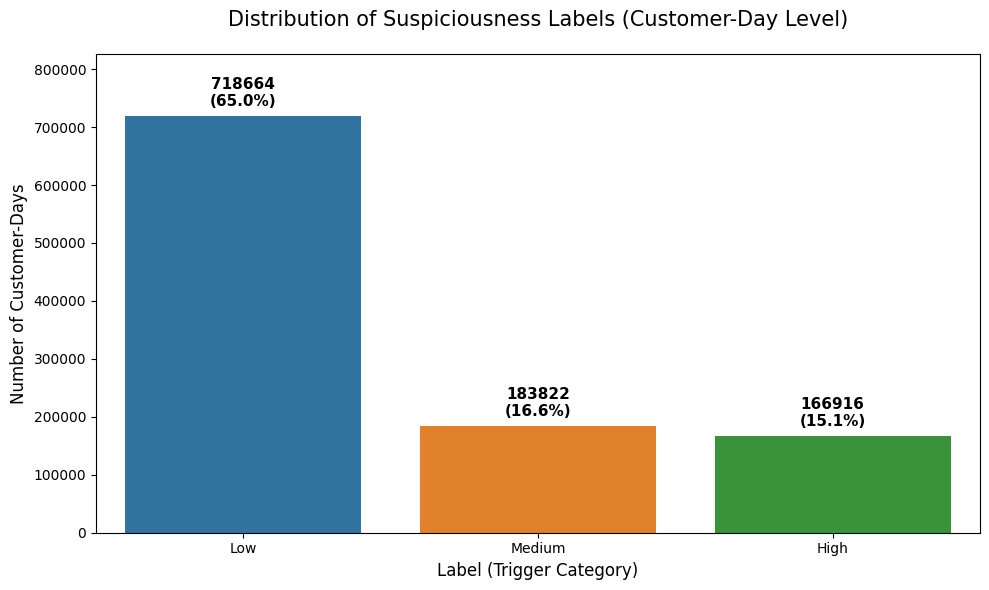

In [140]:
# Calculate counts and percentages
label_counts = customer_day_operational["suspiciousness_label"].value_counts(dropna=False).reset_index()
label_counts.columns = ["Label", "Count"]
total = label_counts["Count"].sum()
label_counts["Percentage"] = (label_counts["Count"] / total) * 100

# Sort the bars by count (descending)
label_counts = label_counts.sort_values(by="Count", ascending=False)

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Label", y="Count", data=label_counts, hue="Label", legend=False)

# Add annotations (Count and Percentage)
for p in ax.patches:
    percentage = f'{(100 * p.get_height() / total):.1f}%'
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{count}\n({percentage})', (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# Formatting
plt.title("Distribution of Suspiciousness Labels (Customer-Day Level)", fontsize=15, pad=20)
plt.xlabel("Label (Trigger Category)", fontsize=12)
plt.ylabel("Number of Customer-Days", fontsize=12)
plt.ylim(0, label_counts["Count"].max() * 1.15) # Add some space for labels
plt.tight_layout()

print(label_counts)


In [141]:
customer_day_operational.sort_values("ratio_velocity", ascending=False).head(5)

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,suspiciousness_label
273354,CUST002506,2024-12-16,7,1092.70,156.100000,5.101064,5.922334,Significant,Significant,1.0,High
118994,CUST001092,2024-03-05,7,1131.01,161.572857,4.883721,5.240282,Significant,Significant,1.0,High
497452,CUST004482,2024-07-13,6,184.17,30.695000,4.777778,0.771888,Significant,Normal,NaN,High
43529,CUST000397,2024-09-06,9,407.47,45.274444,4.745902,2.200326,Significant,Significant,NaN,High
626533,CUST005665,2024-06-05,8,580.43,72.553750,4.651163,2.661610,Significant,Significant,NaN,High


In [142]:
customer_day_operational.sort_values("ratio_value", ascending=False).head(5)

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,suspiciousness_label
848297,CUST007612,2024-08-26,2,5059.63,2529.815000,1.576271,37.622669,Elevated,Significant,1.0,High
903651,CUST008122,2024-09-03,1,4627.35,4627.350000,0.809524,34.432174,Normal,Significant,1.0,High
923940,CUST008303,2024-09-26,3,4716.28,1572.093333,1.514706,33.766945,Elevated,Significant,1.0,High
212282,CUST001956,2024-12-27,3,2836.92,945.640000,2.491228,30.229530,Significant,Significant,1.0,High
418157,CUST003785,2024-11-03,2,3435.78,1717.890000,1.654135,30.123720,Elevated,Significant,1.0,High


## **Disposition Process: Governance-Oriented Rule-Based Approach**

The operational disposition is determined using a deterministic triage procedure based on the `suspiciousness_label` generated at the Business Operations layer.

The decision logic follows a predefined governance-oriented mapping:

1. **High** → Escalate  
2. **Medium** → Under review  
3. **Low** → Dismiss  

This deterministic mapping reflects a structured Standard Operating Procedure (SOP), ensuring consistency in operational decision-making while preserving separation between indicator computation (Data Operations) and final disposition (Business Operations).


In [143]:
def assign_disposition(label):
    if pd.isna(label):
        return np.nan
    elif label == "High":
        return "Escalate"
    elif label == "Medium":
        return "Under review"
    elif label == "Low":
        return "Dismiss"
    else:
        return np.nan

customer_day_operational["ops_disposition"] = (
    customer_day_operational["suspiciousness_label"]
        .apply(assign_disposition)
)

customer_day_operational["ops_disposition"].value_counts(dropna=False)


ops_disposition
Dismiss         718664
Under review    183822
Escalate        166916
NaN              36862
Name: count, dtype: int64

In [144]:
customer_day_operational.shape

(1106264, 12)

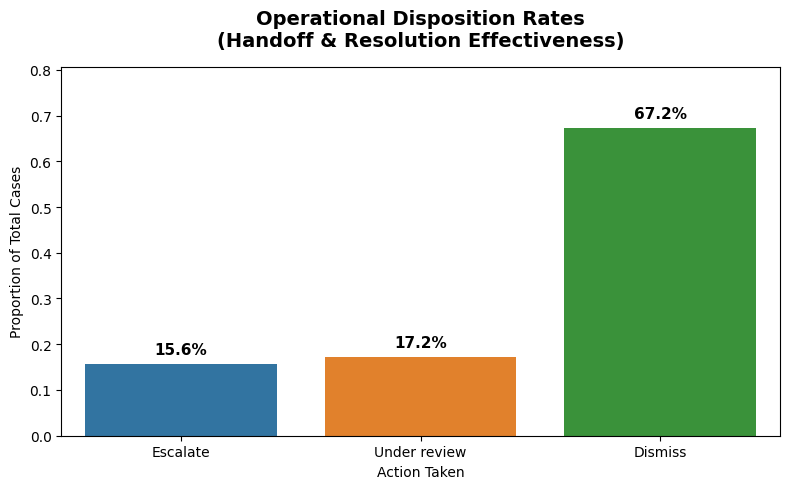

In [145]:

# Ensure consistent ordering
total_cases = customer_day_operational["ops_disposition"].notna().sum()
disposition_counts = customer_day_operational["ops_disposition"].value_counts()

#Ensure consistent ordering
labels = ["Escalate", "Under review", "Dismiss"]
rates = [
    disposition_counts.get("Escalate", 0) / total_cases,
    disposition_counts.get("Under review", 0) / total_cases,
    disposition_counts.get("Dismiss", 0) / total_cases
]
plt.figure(figsize=(8, 5))


# red (Escalate), Orange/yellow (Review), green (Dismiss)
colors = ["#cc3300", "#f1c40f", "#27ae60"]

ax = sns.barplot(x=labels, y=rates, hue=labels, legend=False)

# add percentage above plot
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')


plt.title("Operational Disposition Rates\n(Handoff & Resolution Effectiveness)", fontsize=14, pad=15, fontweight='bold')
plt.ylabel("Proportion of Total Cases", fontsize=10)
plt.xlabel("Action Taken", fontsize=10)
plt.ylim(0, max(rates) * 1.2) # Memberi ruang untuk teks persentase

plt.tight_layout()
plt.show()

## **Case History / Log: Tracing the Disposition Process**

The case log serves as a formal record to trace the escalation process when a suspicious transaction is identified through indicator-based triage.

Each case is assigned a unique `case_id`, which enables Business Operations to consistently reference the affected customer-day during further investigation.

When a case is escalated, detailed transaction-level information is required to support deeper analysis. Since Business Operations operates primarily on aggregated indicators, access to event-level transaction data must be requested from the IT/Data Operations function. 

This controlled data request mechanism reflects role-based information boundaries within the Three Lines Model. The transaction history and chronological event details are then reviewed collaboratively, and the final decision may involve consultation with the Second Line of Defense (2LoD) for oversight and governance validation.


This interaction highlights the structural limitation of aggregated monitoring systems, where traceability gaps necessitate additional coordination between operational and technical units, potentially creating investigation latency and operational bottlenecks.


**The Operational rule flow related to suspicious transaction:**

``DataOps → Business Ops → Case Log → Conditional Drill-down/Propagate Label (if needed) → 2LoD Oversight``



In [146]:
# Ensure date is datetime
customer_day_operational["date"] = pd.to_datetime(customer_day_operational["date"])

In [147]:
def rules(row):
    parts = []
    if row.get("auto_red_flag") == 1:
        parts.append("auto_red_flag=1 (ratio_value>3.0)")
    if row.get("velocity_severity") == "Significant":
        parts.append("velocity_severity=Significant")
    if row.get("value_severity") == "Significant":
        parts.append("value_severity=Significant")
    if row.get("suspiciousness_label") in ["High", "Medium", "Low"]:
        parts.append(f"suspiciousness_label={row['suspiciousness_label']}")
    return "; ".join(parts) if parts else "No trigger (baseline not ready or normal range)"

customer_day_operational["ops_rules"] = customer_day_operational.apply(rules, axis=1)


In [148]:
# Filter only triggered rows to become case candidates
case_candidates = customer_day_operational[
    customer_day_operational["suspiciousness_label"].notna() &
    customer_day_operational["ops_disposition"].notna()
].copy()

# Create case identifiers only for triggered rows
case_candidates["case_id"] = (
    "CASE_" +
    case_candidates["client_id"].astype(str) + "_" +
    case_candidates["date"].dt.strftime("%Y%m%d")
)

case_candidates["case_created_at"] = pd.Timestamp.now()

In [149]:
customer_day_operational.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,suspiciousness_label,ops_disposition,ops_rules
0,CUST000001,2024-01-12,1,88.83,88.830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range)
1,CUST000001,2024-01-15,1,37.68,37.680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range)
2,CUST000001,2024-01-16,1,28.32,28.320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range)
3,CUST000001,2024-01-19,1,57.14,57.140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range)
4,CUST000001,2024-01-22,2,105.37,52.685,1.666667,1.660207,Elevated,Elevated,NaN,Medium,Under review,suspiciousness_label=Medium


In [150]:
case_candidates.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,suspiciousness_label,ops_disposition,ops_rules,case_id,case_created_at
4,CUST000001,2024-01-22,2,105.37,52.685,1.666667,1.660207,Elevated,Elevated,NaN,Medium,Under review,suspiciousness_label=Medium,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468
5,CUST000001,2024-01-25,1,1049.09,1049.090,0.857143,4.606559,Normal,Significant,1.0,High,Escalate,auto_red_flag=1 (ratio_value>3.0); value_sever...,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468
6,CUST000001,2024-02-12,1,95.47,95.470,0.875000,0.457138,Normal,Normal,NaN,Low,Dismiss,suspiciousness_label=Low,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468
7,CUST000001,2024-02-16,1,25.52,25.520,0.888889,0.137258,Normal,Normal,NaN,Low,Dismiss,suspiciousness_label=Low,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468
8,CUST000001,2024-02-23,1,994.77,994.770,0.900000,3.606867,Normal,Significant,1.0,High,Escalate,auto_red_flag=1 (ratio_value>3.0); value_sever...,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468


In [151]:
customer_day_operational.columns

Index(['client_id', 'date', 'daily_txn_count', 'daily_total_amount',
       'daily_avg_amount', 'ratio_velocity', 'ratio_value',
       'velocity_severity', 'value_severity', 'auto_red_flag',
       'suspiciousness_label', 'ops_disposition', 'ops_rules'],
      dtype='object')

In [152]:
case_candidates.columns

Index(['client_id', 'date', 'daily_txn_count', 'daily_total_amount',
       'daily_avg_amount', 'ratio_velocity', 'ratio_value',
       'velocity_severity', 'value_severity', 'auto_red_flag',
       'suspiciousness_label', 'ops_disposition', 'ops_rules', 'case_id',
       'case_created_at'],
      dtype='object')

In [153]:
#Formal case log = only triggered rows
ops_case_log = case_candidates[[
    "case_id",
    "case_created_at",
    "client_id",
    "date",
    "suspiciousness_label",
    "ops_disposition",
    "ratio_velocity",
    "ratio_value",
    "velocity_severity",
    "value_severity",
    "auto_red_flag",
    "ops_rules"
]].copy()


In [154]:
ops_case_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,1.666667,1.660207,Elevated,Elevated,NaN,suspiciousness_label=Medium
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,0.857143,4.606559,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,0.875000,0.457138,Normal,Normal,NaN,suspiciousness_label=Low
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,0.888889,0.137258,Normal,Normal,NaN,suspiciousness_label=Low
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,0.900000,3.606867,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...


In [155]:
# Monitoring-to-case bridge
customer_day_case_registry = customer_day_operational.merge(
    ops_case_log[["case_id", "client_id", "date"]],
    on=["client_id", "date"],
    how="left"
)

customer_day_case_registry["case_status"] = np.where(
    customer_day_case_registry["case_id"].notna(),
    "Triggered case",
    "No case"
)

In [156]:
ops_case_log.shape

(1069402, 12)

In [157]:
customer_day_case_registry.head()

,client_id,date,daily_txn_count,daily_total_amount,daily_avg_amount,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,suspiciousness_label,ops_disposition,ops_rules,case_id,case_status
0,CUST000001,2024-01-12,1,88.83,88.830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range),NaN,No case
1,CUST000001,2024-01-15,1,37.68,37.680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range),NaN,No case
2,CUST000001,2024-01-16,1,28.32,28.320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range),NaN,No case
3,CUST000001,2024-01-19,1,57.14,57.140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No trigger (baseline not ready or normal range),NaN,No case
4,CUST000001,2024-01-22,2,105.37,52.685,1.666667,1.660207,Elevated,Elevated,NaN,Medium,Under review,suspiciousness_label=Medium,CASE_CUST000001_20240122,Triggered case


## **Conditional Drill-Down Mechanism/ Propagate Label: Day-to-day Transaction Label Per Customer (if needed)**

Following formal escalation, Business Operations requires transaction-level detail to assess behavioral context beyond aggregated indicators.

As the operational monitoring layer does not retain event-level data, a structured data request is submitted to the IT/Data Operations function. A controlled transaction extract is then generated based on `client_id` and relevant date scope, producing a case-specific transaction view.

This drill-down mechanism preserves role-based information boundaries while enabling traceability for escalated investigations. However, it introduces dependency on technical units and may create investigation latency.

Merge the customer's day label into every transaction row that occurred on that day for that customer.

So each **``txn_id``** can have an additional column: **``suspicion_label.``** This label is useful for traceability/audit trail to find which transactions are on a "High" day and for business purpose to see transactions per channel/merchant_country for a specific label.

This Propagate label is used only if the disposition label is **``escalate``**

## **Input Data Without Condition vs with Condition** 

## **1. Default Condition (No Escalation Needed)**
   
| Aspect                | Description                                                                                                                                                                                                                            |
| --------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Input dataset(s)**  | `customer_day` (indicator-level dataset from Data Operations)                                                                                                                                                                 |
| **Included fields**   | `client_id`, `date`, `daily_txn_count`, `daily_total_amount`, `daily_avg_amount`, `ratio_velocity`, `ratio_value`, `velocity_severity`, `value_severity`, `auto_red_flag`                                                              |
| **Excluded fields**   | `baseline_txn_count`, `baseline_total_amount`, transaction-level attributes (`txn_id`, `counterparty_iban`, `mcc`, `merchant_country`)                                                                                                 |
| **Processing**        | Monitor severity indicators and trigger flags → review contextual information (if required) → assign `ops_disposition` (dismiss / escalate / under review) → document rationale. No recomputation of baselines or ratios is performed. |
| **Output dataset**    | `ops_case_log` (case-level decision record)                                                                                                                                                                                            |
| **Output artefact**   | Operational case management log (triage decision layer) with optional audit documentation support.                                                                                                                                                                             |
| **Data Access Scope** | Aggregated customer-day level only                                                                                                                                                                                                     |

## **2.Conditional Drill-Down Mechanism / Propagate Label (If Required)**

Following formal escalation, Business Operations requires transaction-level detail to assess behavioral context beyond aggregated indicators.

As the operational monitoring layer does not retain event-level data, a structured data request is submitted to IT/Data Operations. A controlled transaction extract is then generated based on `client_id` and relevant date scope, producing a case-specific transaction view.

This drill-down mechanism preserves role-based information boundaries while enabling traceability for escalated investigations. However, it introduces dependency on technical units and may create investigation latency.

The case-level decision (`suspiciousness_label`, `ops_disposition`) is propagated to the transaction-level extract via `case_id` linkage to support auditability and contextual analysis.

This propagation mechanism is activated only when:

`ops_disposition == "Escalate"`

| Aspect                                           | Description                                                                                                                                                                                  |
| ------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Trigger Condition**                            | `ops_disposition == "Escalate"`                                                                                                                                                              |
| **Primary Input**                                | `ops_case_log` (case-level decision record)                                                                                                                                                  |
| **Additional Input (Requested from IT/DataOps)** | Transaction-level extract filtered by `client_id` and relevant date scope                                                                                                                    |
| **Included fields (Escalation View)**            | `case_id`, `client_id`, `date`, `txn_id`, `time`, `channel`, `d_c`, `trx_ccy`, `amount_eur`, `amount_orig`, (optional: `counterparty_iban`, `mcc`, `merchant_country` if governance permits) -> Transaction Data Attributes |
| **Processing**                                   | Transaction-level chronological review → contextual behavioral assessment → potential consultation with 2LoD → confirm or revise disposition                                                 |
| **Output dataset**                               | `transactions_case_view` (case-scoped transaction extract)                                                                                                                                   |
| **Output artefact**                              | Investigation support dataset linked to `case_id`; ops_case_reviewed; transactions_case_linked                                                                                                                                          |
| **Data Access Scope**                            | Temporary, case-scoped event-level access                                                                                                                                                    |

**Supporting Output Artefacts:**

- ``customer_day_operational``: Operational indicator view consumed from DataOps.
- ``ops_case_reviewed: Filtered`` subset of ops_case_log containing only cases with ops_disposition = "Escalate".
---

**Special Conditions:**
- ``transactions_case_view``: Case-scoped drill-down extract generated conditionally for escalated cases. (output if there is Case History / Log: Tracing the Disposition Process)
- ``transactions_case_linked``: Traceability mapping linking transaction records to case-level decisions (via case_id) for audit trail purposes.


## **Print Data With Disposisition Status ``Escalate``**

In [158]:
ops_case_log.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules'],
      dtype='object')

In [159]:
ops_case_log.shape

(1069402, 12)

In [160]:
ops_case_reviewed = ops_case_log[ops_case_log["ops_disposition"] == "Escalate"].copy()

In [161]:
ops_case_reviewed.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,0.857143,4.606559,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,0.900000,3.606867,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...
14,CASE_CUST000001_20240325,2026-03-18 14:05:08.365468,CUST000001,2024-03-25,High,Escalate,0.937500,4.315552,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...
20,CASE_CUST000001_20240425,2026-03-18 14:05:08.365468,CUST000001,2024-04-25,High,Escalate,0.954545,4.186384,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...
27,CASE_CUST000001_20240524,2026-03-18 14:05:08.365468,CUST000001,2024-05-24,High,Escalate,0.903226,4.264775,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...


In [162]:
ops_case_reviewed["case_id"].nunique()

166916

In [163]:
ops_case_reviewed.shape

(166916, 12)

### **Special Condition: Drill-Down Mechanism**

In [164]:
# synchronize the data type
ops_case_reviewed["date"] = pd.to_datetime(ops_case_reviewed["date"]).dt.date
transactions["date"] = pd.to_datetime(transactions["date"]).dt.date

In [165]:
transactions_case_view = transactions.merge(
    ops_case_reviewed[["case_id", "client_id", "date", "suspiciousness_label", "ops_disposition"]],
    on=["client_id", "date"],
    how="inner"
)


In [166]:
transactions_case_view.head()

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country,month,day,case_id,suspiciousness_label,ops_disposition
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-01,2024-01-25,CASE_CUST000001_20240125,High,Escalate
1,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-02,2024-02-23,CASE_CUST000001_20240223,High,Escalate
2,CUST000001,2024-03-25,06:37:53,TX00000007,online,C,EUR,1060.99,1060.99,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-03,2024-03-25,CASE_CUST000001_20240325,High,Escalate
3,CUST000001,2024-04-25,15:23:41,TX00000011,online,C,EUR,999.87,999.87,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-04,2024-04-25,CASE_CUST000001_20240425,High,Escalate
4,CUST000001,2024-05-24,21:47:28,TX00000014,online,C,EUR,957.80,957.80,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-05,2024-05-24,CASE_CUST000001_20240524,High,Escalate


In [167]:
transactions_case_view.shape

(325781, 18)

### **Average Transaction Per Escalated Case**

In [168]:
transactions_case_view.groupby("case_id")["txn_id"].count().describe()

count    166916.000000
mean          1.951766
std           1.218807
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           9.000000
Name: txn_id, dtype: float64

### **Check Duplicate Transaction Per Escalated Case**

In [169]:
ops_case_reviewed.duplicated(subset=["client_id", "date"]).sum()

0

### **Data Interpretation**

Based on the analysis results, a total of 1,106,264 customer-day records were generated in the `ops_case_log`. Among these, 166,916 cases were assigned an **Escalate** disposition, representing approximately **15.09%** of all monitored cases.

This indicates that around one in seven customer-days triggered escalation under the deterministic governance rule.

Following escalation, a transaction-level drill-down was performed. The escalated cases resulted in 325,781 transaction-level records in the `transactions_case_view`.

The average number of transactions per escalated case is approximately **1.95 transactions per case**, with no duplicate transaction records observed.


Distribution characteristics:

- 50% of escalated cases contain only 1 transaction
- 75% of cases contain 3 transactions or fewer
- Maximum observed transactions in a single escalated case: 9

This indicates that while escalation is triggered at the aggregated customer-day level, most escalated cases involve relatively small transaction volumes.


**The data intepretation translated to the ratio below:**

## **Operational Effectiveness Metrics: Escalation Rate**

To measure how much workload is escalated to senior management compared to the total number of cases received, we use the **Escalation Rate.**

$$Escalation\ Rate = \frac{num\_escalated\_cases}{total\_cases}$$


**In this simulation:**

```
Number of escalated cases = 166,916

Total monitored cases = 1,106,264

Escalation Rate ≈ 15.09% 

```

**Interpretation**

**1. Stress Level Indicator**
A significant increase in the Escalation Rate (e.g., from 5% to 20%) may signal abnormal behavioral shifts or external stress factors affecting transaction patterns.

**2. Calibration Trigger**
A persistently high escalation rate suggests potential over-sensitivity of threshold rules, increasing operational burden and potentially leading to alert fatigue.

**3. Audit Traceability**
The Escalation Rate provides transparency into governance flow by quantifying how many cases require human intervention versus those resolved through automated triage.

## **Escalation Amplification Ratio**

The Escalation Amplification Ratio measures the expansion of investigation workload from aggregated detection to event-level review. It is calculated as:


$$Escalation\ Amplification\ Ratio = \frac{\sum \text{Transaction-level records}}{\sum \text{Escalated cases}}$$

In this simulation, the ratio of approximately ``1.95`` indicates moderate amplification: each escalated customer-day results in nearly two transaction-level records requiring detailed review.

**Number of escalated cases** = 166,916

**Number of transaction-level records generated from escalated cases** = 325,781

A ratio close to 1 indicates that most escalated cases contain only a single transaction, suggesting minimal workload amplification beyond the aggregated signal.

Higher ratios indicate that each escalated case requires review of multiple transaction records, reflecting workload expansion at the event level. This amplification demonstrates how aggregation-based monitoring may simplify detection at the surface level while generating downstream operational burden during investigation.


In [170]:
# Number of escalated cases
num_escalated_cases = ops_case_reviewed["case_id"].nunique()

# Number of transaction-level records generated from escalated cases
num_transaction_records = transactions_case_view.shape[0]

# Escalation Amplification Ratio
amplification_ratio = num_transaction_records / num_escalated_cases

print("Escalated cases:", num_escalated_cases)
print("Transaction-level records (escalated):", num_transaction_records)
print("Escalation Amplification Ratio:", round(amplification_ratio, 4))


total_cases = ops_case_log["case_id"].nunique()

escalation_rate = num_escalated_cases / total_cases

print("Total monitored cases:", total_cases)
print("Escalation rate:", round(escalation_rate * 100, 2), "%")


Escalated cases: 166916
Transaction-level records (escalated): 325781
Escalation Amplification Ratio: 1.9518
Total monitored cases: 1069402
Escalation rate: 15.61 %


## **Documentation For Audit Trail**

In [171]:
transactions["date"] = pd.to_datetime(transactions["date"]).dt.date
ops_case_log["date"] = pd.to_datetime(ops_case_log["date"]).dt.date

transactions_case_linked = transactions.merge(
    ops_case_log[["case_id", "client_id", "date", "suspiciousness_label", "ops_disposition"]],
    on=["client_id", "date"],
    how="left"
)


In [172]:
transactions_case_linked.head()

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country,month,day,case_id,suspiciousness_label,ops_disposition
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-01,2024-01-25,CASE_CUST000001_20240125,High,Escalate
1,CUST000001,2024-01-12,13:32:11,TX00000002,online,D,EUR,88.83,88.83,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BEF6GRNF2ANPJCRMF5CIJI3W,NaN,EE,2024-01,2024-01-12,NaN,NaN,NaN
2,CUST000001,2024-01-22,18:37:34,TX00000003,card,D,EUR,11.79,11.79,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_2NPYIVWYTU6RB3EF2DPW5K2T,5816.0,EE,2024-01,2024-01-22,CASE_CUST000001_20240122,Medium,Under review
3,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-02,2024-02-23,CASE_CUST000001_20240223,High,Escalate
4,CUST000001,2024-02-12,23:50:31,TX00000005,online,D,EUR,95.47,95.47,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BXJ2CJNGBHCMPJURBIU7RSLX,NaN,EE,2024-02,2024-02-12,CASE_CUST000001_20240212,Low,Dismiss


In [173]:
transactions_case_linked.shape

(1551068, 18)

### **Note**

To ensure traceability between aggregated monitoring decisions and event-level transactions, case-level decisions are conditionally linked back to transaction records using `client_id` and `date`.

This linkage enables auditors to verify whether escalated or dismissed cases correspond to transaction-level patterns, without granting unrestricted access to the full Raw IT dataset.

Transactions not associated with a case remain unlinked (NULL case reference), preserving role-based data minimisation.

**The tables `customer_day_operational` and `ops_case_log` are used to:**
- support early-warning monitoring of anomalous transaction activity,
- trigger operational escalation (triage),
- provide operational monitoring signals (not fraud confirmation).

Additionally:
- **`ops_case_reviewed`** is a filtered subset of `ops_case_log` containing only cases with `ops_disposition = "Escalate"`.
- **`transactions_case_view`** is a *case-scoped drill-down extract* created only for escalated cases to support deeper transaction-level analysis when required.
- **`transactions_case_linked`** provides *traceability mapping* by linking transaction records to case-level decisions (via `case_id`) for audit trail purposes.


### **Additional Note:**

In some traditional organisations, **``escalation-driven drill-down``** results in temporary exposure of **``full transaction-level attributes``**, including **customer account and counterparty information**. 

This process causes privacy leakage risk, against data minimisation pincipal, illustrate governance gap and strengthen silo & dependency problem. 

**This escalation-driven reconstruction temporarily exposes PII attributes, which may conflict with privacy-by-design principles and data minimisation requirements under modern regulatory standards.**


## **Output Dataset – 1LoD Business Operations**

The primary output of the Business Operations layer is:

`ops_case_log`  
(Case-level dataset containing suspiciousness classification, operational disposition, and documented rationale for each monitored customer-day.)

This dataset represents the formal triage decision layer and does not perform independent recomputation of analytical indicators.

**Supporting Artefacts:**

- `customer_day_operational`: Operational indicator view consumed from DataOps.
- `ops_case_reviewed`: Filtered subset of `ops_case_log` containing only cases with `ops_disposition = "Escalate"`.
- `transactions_case_view`: Case-scoped drill-down extract generated conditionally for escalated cases.
- `transactions_case_linked`: Traceability mapping linking transaction records to case-level decisions (via `case_id`) for audit trail purposes.

**Output Artefact:**  
Operational case management log (triage decision layer) with optional audit documentation support.

**Data Flow Scenario:**
``customer_day → ops_case_log → (if escalate) → transactions_case_view → transactions_case_linked (audit)``


## **Business Ops Transformation Output**

``DataOps → Business Operations (Role-Based & Decision Transformation)``


| Dimension | DataOps (`customer_day`) | Business Operations (`ops_case_log`) | Structural Change |
|------------|--------------------------|--------------------------------------|-------------------|
| **Granularity** | Customer-day aggregation | Customer-day (case-level) | No change |
| **Rows** | 1,106,264 | 1,106,264 | Structural preservation |
| **Columns** | 12 engineered indicator fields | 12 fields (indicator + decision attributes) | Decision enrichment |
| **Baseline Fields** | Included | Not recomputed | Technical abstraction retained |
| **Volatility (CV)** | Included | Not recomputed | No analytical recalculation |
| **Interpretation Layer** | Severity grouping & trigger | Suspiciousness label + disposition | Responsibility shift |
| **Computation Layer** | Baseline, ratios, CV | None | No recomputation |
| **Traceability** | Reduced | Reduced | No additional traceability |


## **Escalation Drill-Down (Conditional Extension)**

If ops_disposition == "Escalate":

Escalated cases: 166,916

Escalation Rate: 15.09%

Transaction-level records reviewed: 325,781

Escalation Amplification Ratio: 1.95

> This conditional drill-down produces transactions_case_view, a case-scoped transaction extract generated upon formal escalation.


## **GAP vs Raw IT in 1LoD — Business Operations:**

- Event-level transaction access → Not directly available

- Counterparty traceability → Absent at operational layer

- Independent exploratory analysis → Restricted

- Baseline computation transparency → Hidden

- Investigation workflow → Dependent on IT data request

- Escalation workload → Amplified at transaction level (×1.95)


**Note:**

While Business Operations is responsible for case triage and escalation decisions, it operates exclusively on aggregated indicator-level information.

Event-level transaction data remains outside the default access scope and must be retrieved through a structured request to IT/Data Operations upon escalation.

This architecture reinforces role-based data minimisation but introduces dependency-driven latency and potential operational bottlenecks.

## **2LoD — Risk Management Department**

Independent oversight, threshold governance & systemic risk monitoring

> Risk = monitor systemic stability & threshold governance

| Aspect                | Description                                                                                                                                                                                                              |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Input dataset(s)**  | `ops_case_log` (case-level decision record from Business Operations)                                                                                                                                                     |
| **Included fields**   | `case_id`, `client_id`, `date`, `suspiciousness_label`, `ops_disposition`, escalation indicators (for rate calculation): `auto_red_flag`,'ops_rules` , aggregated ratios: `ratio_velocity`,`ratio_value`, `velocity_severity`, `value_severity`.|
| **Excluded fields**   | Transaction-level attributes (`txn_id`, `counterparty_iban`, `mcc`, `merchant_country`), raw baseline computation fields                                                                                                 |
| **Processing**        | Aggregate case-level outcomes → compute escalation rate → monitor trend stability → assess threshold sensitivity → evaluate alignment with risk appetite. No anomaly detection or transaction-level review is performed. |
| **Output dataset**    | `lod2_risk_dashboard` (aggregated oversight dataset)                                                                                                                                                                     |
| **Output artefact**   | Risk oversight dashboard & threshold governance log                                                                                                                                                                      |
| **Data Access Scope** | Aggregated case-level and trend-level metrics only                                                                                                                                                                       |


## **Business Operations → Risk Management (Oversight Abstraction)**

| Dimension                | Business Ops Output (`ops_case_log`) | Risk Management View (`lod2_risk_dashboard`)               | Structural Change               |
| ------------------------ | ------------------------------------ | ---------------------------------------------------------- | ------------------------------- |
| **Granularity**          | Customer-day (case-level)            | Period-level aggregation (e.g., monthly trend)             | Case → Trend                    |
| **Rows**                 | 1,106,264 cases                      | Aggregated periods (e.g., 12 months)                       | Temporal abstraction            |
| **Columns**              | 12 case-level decision fields        | Escalation rate, label distribution, amplification metrics | Metric abstraction              |
| **Baseline Fields**      | Not recomputed                       | Not accessible                                             | Analytical abstraction retained |
| **Volatility (CV)**      | Not recomputed                       | Not accessible                                             | No recalculation                |
| **Computation Layer**    | None                                 | Escalation rate, amplification ratio, stability indicators | Governance analytics            |
| **Interpretation Layer** | Disposition decision                 | Risk appetite alignment & threshold review                 | Oversight shift                 |
| **Traceability**         | Reduced                              | No event-level traceability                                | Governance abstraction          |


## **Input dataset with field Included only:**

In [174]:
ops_case_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,1.666667,1.660207,Elevated,Elevated,NaN,suspiciousness_label=Medium
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,0.857143,4.606559,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,0.875000,0.457138,Normal,Normal,NaN,suspiciousness_label=Low
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,0.888889,0.137258,Normal,Normal,NaN,suspiciousness_label=Low
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,0.900000,3.606867,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...


In [175]:
ops_case_log.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules'],
      dtype='object')

## **Risk Aggregate: Case-Level Outcomes**

## **Monthly Escalation Rate**

In [176]:
# view per month

ops_case_log["date"] = pd.to_datetime(ops_case_log["date"])

ops_case_log["month"] = ops_case_log["date"].dt.to_period("M")

In [177]:
ops_case_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,month
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,1.666667,1.660207,Elevated,Elevated,NaN,suspiciousness_label=Medium,2024-01
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,0.857143,4.606559,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...,2024-01
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,0.875000,0.457138,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,0.888889,0.137258,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,0.900000,3.606867,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...,2024-02


In [178]:
ops_case_log.shape

(1069402, 13)

In [179]:
# 1. calculate total case per month
monthly_total = (
    ops_case_log
    .groupby("month")
    .size()
)


# 2. calculate total escalated case per month
monthly_escalated = (
    ops_case_log[ops_case_log["ops_disposition"] == "Escalate"]
    .groupby("month")
    .size()
)

# merge 1 & 2 then calculate Escalation rate in the new data frame

lod2_risk_dashboard = pd.DataFrame({
    "total_cases": monthly_total,
    "escalated_cases": monthly_escalated
}).fillna(0)

lod2_risk_dashboard["escalation_rate"] = (
    lod2_risk_dashboard["escalated_cases"] /
    lod2_risk_dashboard["total_cases"]
)

lod2_risk_dashboard = lod2_risk_dashboard.reset_index()


In [180]:
lod2_risk_dashboard.head(20)

,month,total_cases,escalated_cases,escalation_rate
0,2024-01,56607,9245,0.163319
1,2024-02,82863,12840,0.154955
2,2024-03,88436,13446,0.152042
3,2024-04,87299,13513,0.154790
4,2024-05,90275,13972,0.154772
5,2024-06,89542,13868,0.154877
6,2024-07,92883,14307,0.154032
7,2024-08,94398,14650,0.155194
8,2024-09,92695,14788,0.159534
9,2024-10,96883,15160,0.156477


In [181]:
lod2_risk_dashboard.shape

(12, 4)

## **Monthly aggregation of labels**

Hitung monthly escalation rate

Hitung distribution High / Medium / Low

Hitung amplification ratio per month

Hitung volatility of escalation

## **Monthly Escalation Metrics (total, escalated, rate)**

In [182]:
lod2_risk_dashboard = (
    ops_case_log
    .groupby("month")
    .agg(
        total_cases=("case_id", "count"),
        escalated_cases=("ops_disposition", lambda x: (x == "Escalate").sum())
    )
    .reset_index()
)

lod2_risk_dashboard["escalation_rate"] = (
    lod2_risk_dashboard["escalated_cases"] /
    lod2_risk_dashboard["total_cases"]
)


In [183]:
lod2_risk_dashboard.head(20)

,month,total_cases,escalated_cases,escalation_rate
0,2024-01,56607,9245,0.163319
1,2024-02,82863,12840,0.154955
2,2024-03,88436,13446,0.152042
3,2024-04,87299,13513,0.154790
4,2024-05,90275,13972,0.154772
5,2024-06,89542,13868,0.154877
6,2024-07,92883,14307,0.154032
7,2024-08,94398,14650,0.155194
8,2024-09,92695,14788,0.159534
9,2024-10,96883,15160,0.156477


## **Monthly Suspiciousness label distribution (High/Medium/Low)**

In [184]:
monthly_labels = (
    ops_case_log
    .groupby(["month", "suspiciousness_label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

lod2_risk_dashboard = lod2_risk_dashboard.merge(
    monthly_labels,
    on="month",
    how="left"
)


In [185]:
lod2_risk_dashboard.head(20)

,month,total_cases,escalated_cases,escalation_rate,High,Low,Medium
0,2024-01,56607,9245,0.163319,9245,36116,11246
1,2024-02,82863,12840,0.154955,12840,55116,14907
2,2024-03,88436,13446,0.152042,13446,59287,15703
3,2024-04,87299,13513,0.154790,13513,58994,14792
4,2024-05,90275,13972,0.154772,13972,60861,15442
5,2024-06,89542,13868,0.154877,13868,60644,15030
6,2024-07,92883,14307,0.154032,14307,63119,15457
7,2024-08,94398,14650,0.155194,14650,64022,15726
8,2024-09,92695,14788,0.159534,14788,62196,15711
9,2024-10,96883,15160,0.156477,15160,65565,16158


## **Monthly amplification ratio (transaction-level workload per escalated case)**

In [186]:
monthly_txn_escalated = (
    ops_case_log
    .groupby("month")
    .size()
    .reset_index(name="txn_records_escalated")
)

lod2_risk_dashboard = lod2_risk_dashboard.merge(
    monthly_txn_escalated,
    on="month",
    how="left"
)

lod2_risk_dashboard["txn_records_escalated"] = lod2_risk_dashboard["txn_records_escalated"].fillna(0)

lod2_risk_dashboard["amplification_ratio"] = (
    lod2_risk_dashboard["txn_records_escalated"] /
    lod2_risk_dashboard["escalated_cases"].replace(0, pd.NA)
)


In [187]:
lod2_risk_dashboard.head(20)

,month,total_cases,escalated_cases,escalation_rate,High,Low,Medium,txn_records_escalated,amplification_ratio
0,2024-01,56607,9245,0.163319,9245,36116,11246,56607,6.122985
1,2024-02,82863,12840,0.154955,12840,55116,14907,82863,6.453505
2,2024-03,88436,13446,0.152042,13446,59287,15703,88436,6.577123
3,2024-04,87299,13513,0.154790,13513,58994,14792,87299,6.460371
4,2024-05,90275,13972,0.154772,13972,60861,15442,90275,6.461137
5,2024-06,89542,13868,0.154877,13868,60644,15030,89542,6.456735
6,2024-07,92883,14307,0.154032,14307,63119,15457,92883,6.492137
7,2024-08,94398,14650,0.155194,14650,64022,15726,94398,6.443549
8,2024-09,92695,14788,0.159534,14788,62196,15711,92695,6.268258
9,2024-10,96883,15160,0.156477,15160,65565,16158,96883,6.390699


## **Escalation stability index (month-to-month volatility)**

In [188]:
lod2_risk_dashboard = lod2_risk_dashboard.sort_values("month")

lod2_risk_dashboard["escalation_rate_prev"] = lod2_risk_dashboard["escalation_rate"].shift(1)

lod2_risk_dashboard["escalation_stability_index"] = (
    (lod2_risk_dashboard["escalation_rate"] - lod2_risk_dashboard["escalation_rate_prev"]).abs()
    / lod2_risk_dashboard["escalation_rate_prev"]
)


In [189]:
lod2_risk_dashboard.head(20)

,month,total_cases,escalated_cases,escalation_rate,High,Low,Medium,txn_records_escalated,amplification_ratio,escalation_rate_prev,escalation_stability_index
0,2024-01,56607,9245,0.163319,9245,36116,11246,56607,6.122985,NaN,NaN
1,2024-02,82863,12840,0.154955,12840,55116,14907,82863,6.453505,0.163319,0.051215
2,2024-03,88436,13446,0.152042,13446,59287,15703,88436,6.577123,0.154955,0.018795
3,2024-04,87299,13513,0.154790,13513,58994,14792,87299,6.460371,0.152042,0.018072
4,2024-05,90275,13972,0.154772,13972,60861,15442,90275,6.461137,0.154790,0.000118
5,2024-06,89542,13868,0.154877,13868,60644,15030,89542,6.456735,0.154772,0.000682
6,2024-07,92883,14307,0.154032,14307,63119,15457,92883,6.492137,0.154877,0.005453
7,2024-08,94398,14650,0.155194,14650,64022,15726,94398,6.443549,0.154032,0.007540
8,2024-09,92695,14788,0.159534,14788,62196,15711,92695,6.268258,0.155194,0.027965
9,2024-10,96883,15160,0.156477,15160,65565,16158,96883,6.390699,0.159534,0.019159


## **Stability Check**

### **1. Label counts should be equal with total_cases**

In [190]:
# Label counts should be equal to total_cases

label_cols = [c for c in ["High", "Medium", "Low"] if c in lod2_risk_dashboard.columns]
lod2_risk_dashboard["label_sum"] = lod2_risk_dashboard[label_cols].sum(axis=1)

(lod2_risk_dashboard["label_sum"] == lod2_risk_dashboard["total_cases"]).value_counts()


True    12
Name: count, dtype: int64

### **2. Amplification ratio (usual1y above 1)**

In [191]:
# Amplification ratio (>1)

lod2_risk_dashboard[["month","escalated_cases","txn_records_escalated","amplification_ratio"]].head(20)

,month,escalated_cases,txn_records_escalated,amplification_ratio
0,2024-01,9245,56607,6.122985
1,2024-02,12840,82863,6.453505
2,2024-03,13446,88436,6.577123
3,2024-04,13513,87299,6.460371
4,2024-05,13972,90275,6.461137
5,2024-06,13868,89542,6.456735
6,2024-07,14307,92883,6.492137
7,2024-08,14650,94398,6.443549
8,2024-09,14788,92695,6.268258
9,2024-10,15160,96883,6.390699


At an aggregate level, the distribution of escalation labels remains relatively stable across months. Low-severity labels consistently account for the largest share, ranging from approximately 48–53%, followed by Medium labels at around 24–29%, and High labels at approximately 20–21% per month. These aggregate patterns should not be interpreted as an assessment of overall transaction risk. Instead, they indicate stability in operational monitoring outcomes over time. A more nuanced understanding of transaction behaviour requires further analysis at the customer level, which is addressed in subsequent sections.

### **Monthly Escalation Trend (Risk Management)**

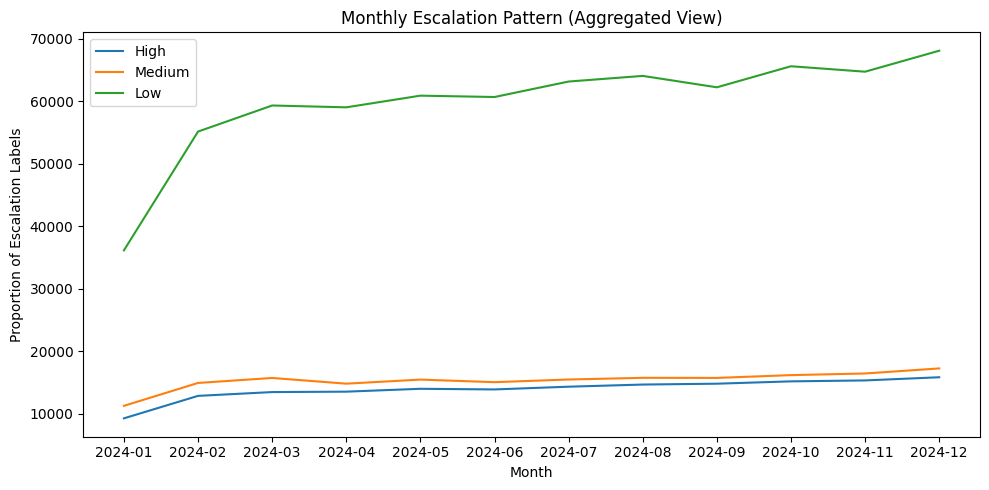

In [192]:
plt.figure(figsize=(10, 5))

label_cols = ["High", "Medium", "Low"]

for label in label_cols:
    plt.plot(
        lod2_risk_dashboard["month"].astype(str),
        lod2_risk_dashboard[label],
        label=label
    )

plt.title("Monthly Escalation Pattern (Aggregated View)")
plt.xlabel("Month")
plt.ylabel("Proportion of Escalation Labels")
plt.legend()
plt.tight_layout()
plt.show()


When observing the monthly escalation trend at the population level, the overall pattern appears relatively stable, with Low escalation labels consistently representing the largest proportion. A significant increase in Low labels is observed between January and February, and the next montwhich coincides with a corresponding decline in Medium labels during the same period. In subsequent months, both Low and Medium label proportions remain broadly stable, indicating no sustained structural shift in escalation outcomes over time.

> By focusing on aggregated escalation patterns, the second line of defense (risk management) supports independent challenge and risk appetite discussions, while maintaining a clear separation of roles from business operations.

In the context of suspicious transaction monitoring, the role of risk management is to strengthen governance resilience rather than to duplicate or override first-line monitoring logic. 

This is achieved through the review of monthly trends in transaction outcomes and escalation labels, the assessment of escalation rates at an aggregate level, and the provision of independent challenge to the first line regarding the continued appropriateness of its risk appetite and monitoring assumptions. 

In [193]:
risk_context_summary = (
    financial_profile["financial_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)

risk_context_summary.columns = ["Financial Profile Type", "Percentage (%)"]
risk_context_summary


,Financial Profile Type,Percentage (%)
0,inactive,59.6
1,deposit_only,21.1
2,loan_only,13.8
3,both,5.4


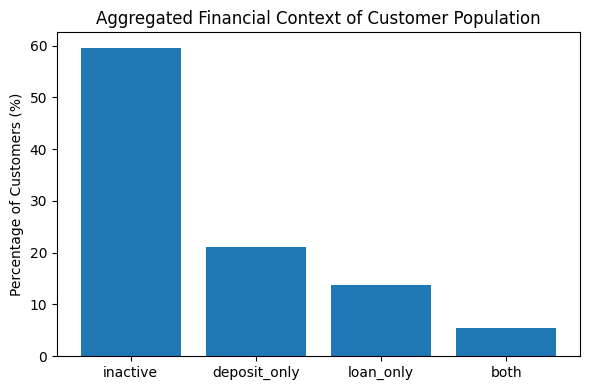

In [194]:
plt.figure(figsize=(6,4))
plt.bar(
    risk_context_summary["Financial Profile Type"],
    risk_context_summary["Percentage (%)"]
)
plt.title("Aggregated Financial Context of Customer Population")
plt.ylabel("Percentage of Customers (%)")
plt.tight_layout()
plt.show()


Bank operational transaction activities are structurally supported by a minority of the population (~40%), not the entire customer base.

The aggregate financial profile indicates that approximately 60% of customers are inactive (have no financial activity), while only 40% of financially active customers dominate transaction activity in the population.

This provides important context for interpreting monthly escalation patterns, as operational monitoring results (transactions) are driven by a small subset of customers, not the entire population.

From a risk management perspective, this insight serves as contextual evidence, not as a basis for further decomposition at the product level due to data limitations (the product only relates to loan products).

Consequently, detailed product analysis is excluded in this context because only loan product information is available. Therefore, further risk analysis outside the context of operational risk resulting from suspicious transactions would shift the focus to credit risk, which is beyond the scope of the transaction monitoring governance examined in this study.

Conversely, the aggregate profile supports risk oversight and auditability by demonstrating that escalation trends are interpreted with an awareness of the heterogeneity of the underlying population.

### **1. Escalation Pressure (Operational Stress Indicator) (Operational Stress Indicator)**

$$Escalation\ Rate =\frac{Escalated\ Cases}{Total\ Cases}$$

**In this simulation:**

```
Number of escalated cases = 166,916

Total monitored cases = 1,106,264

Escalation Rate ≈ 15.09% 

```

In this simulation:

Escalation Rate ≈ 15.09%

Interpretation:

Approximately 15% of monitored customer-days require escalation beyond automated triage.
This reflects the sensitivity of threshold calibration and the structural burden placed on investigation functions.

### **2. Workload Expansion (Amplification Effect)**

$$Amplification\ Ratio = \frac{Transaction\text{-}level\ records\ reviewed}{Escalated\ cases}$$

**In this simulation:**

```
Number of escalated cases = 166,916

Number of transaction-level records generated from escalated cases = 325,781

```
In this simulation:

Amplification Ratio ≈ 1.95

Interpretation:

Each escalated case requires nearly two event-level transaction records to be reconstructed and reviewed.
This demonstrates that aggregation simplifies monitoring but generates downstream expansion at investigation level.


### **3. Structural Stability (Governance Calibration Indicator)**

$$ESI (Escalation Stability Index) = \frac{|Rate_t - Rate_{t-1}|}{Rate_{t-1}}$$

**In this simulation:**

| Month   | Escalation Rate | Previous Rate | ESI    | % Change    |
| ------- | --------------- | ------------- | ------ | ----------- |
| 2024-01 | 0.1062          | –             | –      | –           |
| 2024-02 | 0.1532          | 0.1062        | 0.4429 | **+44.29%** |
| 2024-03 | 0.1515          | 0.1532        | 0.0116 | −1.16%      |
| 2024-04 | 0.1542          | 0.1515        | 0.0178 | +1.78%      |
| 2024-05 | 0.1540          | 0.1542        | 0.0012 | −0.12%      |
| 2024-06 | 0.1541          | 0.1540        | 0.0011 | +0.11%      |
| 2024-07 | 0.1533          | 0.1541        | 0.0057 | −0.57%      |
| 2024-08 | 0.1544          | 0.1533        | 0.0074 | +0.74%      |
| 2024-09 | 0.1585          | 0.1544        | 0.0266 | +2.66%      |
| 2024-10 | 0.1555          | 0.1585        | 0.0191 | −1.91%      |
| 2024-11 | 0.1575          | 0.1555        | 0.0130 | +1.30%      |
| 2024-12 | 0.1550          | 0.1575        | 0.0161 | −1.61%      |

**NOTE:**

$$\text{Average ESI}_{\text{Mar-Dec}} \approx 0.012$$

overall, the average ESI in this simulation is around **1-2%** per month. So, The threshold governance is stable and not over-reactive toward minor daily fluctuations.
**This measures volatility in escalation behavior. if:**
Low ESI (Stable): The governance is in healthy condition . The established rules produce predictable results.

High ESI (Volatile): There is a systemic problem.

**High volatility indicates:**

- Threshold miscalibration (someone changes system rules without proper testing)

- Behavioral drift (criminals change patterns massively)

- Potential systemic instability

- Stable values indicate consistent governance calibration.




## **Output dataset – 2LoD Risk Management**

``lod2_risk_dashboard``
(Aggregated oversight dataset containing escalation metrics, label distributions, and threshold stability indicators derived from 1LoD outputs.)

This dataset does not perform anomaly detection (analytical indicators) or transaction-level investigation.
Its purpose is to monitor systemic behaviour of the detection and escalation mechanism and ensure alignment with organizational risk appetite.

## **Output artefact:**
Risk oversight dashboard & threshold governance monitoring report.

## **Business Operations → Risk Management (Oversight Abstraction Transformation)**

| Dimension                | Business Ops Output (`ops_case_log`) | Risk Management View (`lod2_risk_dashboard`)               | Structural Change               |
| ------------------------ | ------------------------------------ | ---------------------------------------------------------- | ------------------------------- |
| **Granularity**          | Customer-day (case-level)            | Period-level aggregation (e.g., monthly trend)             | Case → Trend                    |
| **Rows**                 | 1,106,264 cases                      | Aggregated periods (e.g., 12 months)                       | Temporal abstraction            |
| **Columns**              | 12 case-level decision fields        | Escalation rate, label distribution, amplification metrics | Metric abstraction              |
| **Baseline Fields**      | Not recomputed                       | Not accessible                                             | Analytical abstraction retained |
| **Volatility (CV)**      | Not recomputed                       | Not accessible                                             | No recalculation                |
| **Computation Layer**    | None                                 | Escalation rate, amplification ratio, stability indicators | Governance analytics            |
| **Interpretation Layer** | Disposition decision                 | Risk appetite alignment assessment                         | Oversight shift                 |
| **Traceability**         | Reduced                              | No event-level traceability                                | Governance abstraction          |


## **GAP vs Raw IT – 2LoD Risk Management**

- Event-level visibility → Absent (No event-level transaction visibility)

- Customer-level detail → Not accessible (No counterparty-level insight)

-  Case-level reasoning → Indirect only (No access to raw baseline construction)

-  Escalation dependency → Relies on 1LoD output (Cannot independently validate escalation appropriateness without additional data access)

-  Threshold calibration → Indirect, based on aggregate metrics (Oversight based solely on aggregated outcomes)

Risk Management operates entirely on abstraction layers.

This increases governance distance from raw operational reality.

## **2LoD — Compliance Department**

## **Input dataset – 2LoD Compliance**

Independent compliance oversight & procedural adherence monitoring

> Compliance = ensure SOP adherence & regulatory alignment


| Aspect                | Description                                                                                                                                                                                 |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Input dataset(s)**  | `ops_case_log` (case-level decision record from Business Operations)                                                                                                                        |
| **Included fields**   | `case_id`, `client_id`, `date`, `suspiciousness_label`, `ops_disposition`, decision timestamps (if available), documentation completeness indicators                                        |
| **Excluded fields**   | Transaction-level attributes (`txn_id`, `counterparty_iban`, `mcc`, `merchant_country`), baseline computation fields, raw transaction metrics                                               |
| **Processing**        | Review procedural adherence → verify decision consistency with internal SOP → check documentation completeness → assess escalation handling quality. No anomaly recalculation is performed. |
| **Output dataset**    | `lod2_compliance_review_log` (compliance review record)                                                                                                                                     |
| **Output artefact**   | Compliance monitoring report & governance consistency log                                                                                                                                   |
| **Data Access Scope** | Case-level decision records only                                                                                                                                                            |

Compliance has the same view with risk management in term of shifting the focus from transaction-level monitoring to **aggregated oversight** by focus on:

- documentation completeness
- governance consistency rather than transaction behaviour or detection logic

**Note:**

Compliance activities are concerned with ensuring an organisation’s adherence to internal policies and applicable regulatory expectations through process oversight and documentation review. Within the scope of this simulation, the compliance function does not engage in transaction-level analysis or detection activities.

Instead, compliance oversight focuses on verifying the presence, consistency, and traceability of documentation supporting first-line monitoring and escalation decisions. This includes confirming that any adjustments or overrides applied by the first line are appropriately recorded and aligned with established governance procedures.

## **Business Operations → Compliance (Procedural Oversight Transformation)**

| Dimension                | Business Ops Output (`ops_case_log`) | Compliance View (`lod2_compliance_review_log`) | Structural Change              |
| ------------------------ | ------------------------------------ | ---------------------------------------------- | ------------------------------ |
| **Granularity**          | Customer-day (case-level)            | Case-level procedural review                   | No change                      |
| **Rows**                 | 1,106,264 cases                      | Sampled or reviewed cases                      | Case sampling                  |
| **Columns**              | 12 decision fields                   | Decision fields + compliance review notes      | Governance annotation          |
| **Baseline Fields**      | Not accessible                       | Not accessible                                 | Technical abstraction retained |
| **Computation Layer**    | None                                 | None                                           | No analytical recalculation    |
| **Interpretation Layer** | Operational disposition              | SOP adherence validation                       | Control verification           |
| **Traceability**         | Reduced                              | Reduced                                        | No event-level traceability    |



## **Input dataset with field Included only:**

In [195]:
ops_case_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,month
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,1.666667,1.660207,Elevated,Elevated,NaN,suspiciousness_label=Medium,2024-01
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,0.857143,4.606559,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...,2024-01
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,0.875000,0.457138,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,0.888889,0.137258,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,0.900000,3.606867,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...,2024-02


In [196]:
ops_case_log.shape

(1069402, 13)

In [197]:
#case_id, client_id, date, suspiciousness_label, ops_disposition

ops_case_log.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month'],
      dtype='object')

In [198]:
lod2_compliance_review_log = ops_case_log[['case_id', 'case_created_at', 'client_id', 'date','suspiciousness_label', 'ops_disposition']].copy()

In [199]:
lod2_compliance_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate


### **Expected Disposition**

In [200]:
def expected_disposition(label):
    if label == "High":
        return "Escalate"
    elif label == "Medium":
        return "Under review"
    elif label == "Low":
        return "Dismiss"
    else:
        return np.nan

lod2_compliance_review_log["expected_disposition"] = lod2_compliance_review_log["suspiciousness_label"].apply(expected_disposition)

In [201]:
lod2_compliance_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,expected_disposition
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,Under review
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,Escalate
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,Dismiss
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,Dismiss
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,Escalate


### **SOP Deviation Flag**

In [202]:
lod2_compliance_review_log["sop_deviation_flag"] = (
    lod2_compliance_review_log["ops_disposition"] != 
    lod2_compliance_review_log["expected_disposition"]
).astype(int)

In [203]:
lod2_compliance_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,expected_disposition,sop_deviation_flag
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,Under review,0
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,Escalate,0
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,Dismiss,0
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,Dismiss,0
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,Escalate,0


### **Documentation Present Flag**

In [204]:
lod2_compliance_review_log["documentation_present_flag"] = \
    lod2_compliance_review_log["ops_disposition"].notna().astype(int)

In [205]:
lod2_compliance_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,expected_disposition,sop_deviation_flag,documentation_present_flag
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,Under review,0,1
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,Escalate,0,1
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,Dismiss,0,1
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,Dismiss,0,1
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,Escalate,0,1


### **Compliance Status**

In [206]:
lod2_compliance_review_log["compliance_status"] = np.where(
    (lod2_compliance_review_log["sop_deviation_flag"] == 0) &
    (lod2_compliance_review_log["documentation_present_flag"] == 1),
    "Compliant",
    "Governance Issue"
)

In [207]:
lod2_compliance_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,expected_disposition,sop_deviation_flag,documentation_present_flag,compliance_status
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,Under review,0,1,Compliant
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,Escalate,0,1,Compliant
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,Dismiss,0,1,Compliant
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,Dismiss,0,1,Compliant
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,Escalate,0,1,Compliant


### **Review Timestamp**

In [208]:
lod2_compliance_review_log["review_timestamp"] = pd.Timestamp.now()

In [209]:
lod2_compliance_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,expected_disposition,sop_deviation_flag,documentation_present_flag,compliance_status,review_timestamp
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,Under review,0,1,Compliant,2026-03-18 14:06:18.128981
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,Escalate,0,1,Compliant,2026-03-18 14:06:18.128981
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,Dismiss,0,1,Compliant,2026-03-18 14:06:18.128981
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,Dismiss,0,1,Compliant,2026-03-18 14:06:18.128981
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,Escalate,0,1,Compliant,2026-03-18 14:06:18.128981


### **Compliance Matrix**

In [210]:
total_reviewed = len(lod2_compliance_review_log)

sop_compliance_rate = (
    (lod2_compliance_review_log["sop_deviation_flag"] == 0).mean()
)

governance_issue_rate = (
    (lod2_compliance_review_log["compliance_status"] == "Governance Issue").mean()
)

#sop_compliance_rate, governance_issue_rate

print("SOP Compliance Rate:", sop_compliance_rate)
print("Governance Issue Rate:", governance_issue_rate)

SOP Compliance Rate: 1.0
Governance Issue Rate: 0.0


### **Compliance Matrix (Simulation Result)**

### **SOP Compliance Rate**

### **Formula**

$$ SOP\ Compliance\ Rate = \frac{\text{Number of cases where } ops\_disposition = expected\_disposition} {\text{Total reviewed cases}}$$

### **In this simulation**

- \( N \) = total reviewed cases  
- \( C \) = number of cases where operational disposition matches expected SOP outcome  

$$ SOP\ Compliance\ Rate = \frac{C}{N}$$

$$ SOP\ Compliance\ Rate = 96.67\% $$

### **Interpretation**

This metric measures the degree to which first-line operational decisions align with predefined governance rules.

- Value close to **1 (100%)** → strong procedural consistency  
- Lower value → increased override activity or governance deviation  

### **Governance Issue Rate**

### **Formula**

$$ Governance\ Issue\ Rate = \frac{\text{Number of cases flagged as Governance Issue}}{\text{Total reviewed cases}}$$

### **In this simulation**

- \( N \) = total reviewed cases  
- \( G \) = number of cases flagged as governance deviation  

$$ Governance\ Issue\ Rate = \frac{G}{N} $$

Since only two compliance states exist (Compliant vs Governance Issue), to calciulate governance issue rate can be:

$$ Governance\ Issue\ Rate = 1 - SOP\ Compliance\ Rate $$

### Interpretation

This metric quantifies the proportion of cases where operational decisions deviate from expected procedural standards, which in this simulation the governance rate is:

$$ Governance\ Issue\ Rate= 3.33\% $$

This indicates the presence of limited procedural deviations requiring second-line oversight.


## **Output dataset – 2LoD Compliance**

``lod2_compliance_review_log``
(Case-level compliance review dataset documenting adherence to internal SOP, escalation protocol, and documentation completeness.)

This dataset does not perform risk detection or threshold monitoring.
Its purpose is to ensure that operational decisions align with governance and regulatory requirements.

## **Output artefact:**

**Compliance monitoring records & procedural compliance reports**

This artifact provides structured evidence of second-line governance validation, including:

- SOP compliance assessment
- Override identification 
- Validation of documentation completeness
- Review of escalation handling


## **Business Operations → Compliance (Control Adherence Transformation)**

| Dimension                | Business Ops Output (`ops_case_log`) | Compliance View (`lod2_compliance_review_log`) | Structural Change              |
| ------------------------ | ------------------------------------ | ---------------------------------------------- | ------------------------------ |
| **Granularity**          | Customer-day (case-level)            | Case-level procedural review                   | No change                      |
| **Rows**                 | 1,106,264 cases                      | Sampled or reviewed cases                      | Case sampling                  |
| **Columns**              | 12 decision fields                   | Decision fields + compliance validation fields | Governance annotation          |
| **Baseline Fields**      | Not accessible                       | Not accessible                                 | Technical abstraction retained |
| **Computation Layer**    | None                                 | None                                           | No recalculation               |
| **Interpretation Layer** | Operational disposition              | SOP adherence validation                       | Control verification           |
| **Traceability**         | Reduced                              | Reduced                                        | No event-level traceability    |


## **GAP vs Raw IT – 2LoD Compliance**

- No event-level visibility

- No counterparty context

- No transaction chronology

- Reliant on 1LoD documentation quality

- Cannot independently reconstruct transaction narrative

In the governance level, this compliance oversight operates exclusively at the procedural layer. While this reinforces role-based data minimisation, it introduces structural dependency on first-line documentation integrity and limits independent investigative capability.

## **3LoD — Internal Audit Department**

``Independent assurance over governance, control design, traceability integrity, and effectiveness.``

> Audit = independently test the whole system

The internal audit function provides independent assurance over the design and operating effectiveness of monitoring and escalation processes.

In this simulation, audit activities focus on sampling-based verification, traceability, and role separation across the Three Lines of Defense.


| Aspect                | Description                                                                                                                                           |
| --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Input dataset(s)**  | `ops_case_log`, `lod2_risk_dashboard`, `lod2_compliance_review_log`; `transactions_case_linked` (audit trail information)  and sampled `transactions_case_view` (upon formal request)                       |
| **Included fields**   | `case_id`, `client_id`, `date`, `suspiciousness_label`, `ops_disposition`, escalation metrics, compliance_status, governance indicators               |
| **Excluded fields**   | Full raw transaction dataset (unless formally requested), full baseline computation logic (unless re-performance required), full transaction universe |
| **Processing**        | Risk-based sampling → control design review → re-performance testing (sampled) → cross-line consistency validation → documentation of audit findings  |
| **Output dataset**    | `audit_review_log` (sample-based assurance record)                                                                                                    |
| **Output artefact**   | Internal Audit report & control effectiveness assessment                                                                                              |
| **Data Access Scope** | Sample-based, role-authorised reconstruction only                                                                                                     |
                                                                                            |


### **Transformation Table**

**Oversight → Independent Assurance**

| Dimension                | 1LoD / 2LoD Outputs               | 3LoD Internal Audit                  | Structural Change        |
| ------------------------ | --------------------------------- | ------------------------------------ | ------------------------ |
| **Granularity**          | Case-level & aggregated trend     | Sampled case-level                   | Full → Sample            |
| **Rows**                 | 1,106,264 cases                   | Risk-based audit sample              | Assurance sampling       |
| **Columns**              | Decision & oversight metrics      | Governance + audit test fields       | Assurance enrichment     |
| **Computation Layer**    | Monitoring metrics                | Re-performance testing (sample only) | Independent verification |
| **Interpretation Layer** | Operational & oversight judgement | Control effectiveness evaluation     | Assurance shift          |
| **Traceability**         | Reduced                           | Tested via controlled drill-down     | Conditional validation   |



## **Input dataset with field Included only:**

In [211]:
ops_case_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,month
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,1.666667,1.660207,Elevated,Elevated,NaN,suspiciousness_label=Medium,2024-01
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,0.857143,4.606559,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...,2024-01
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,0.875000,0.457138,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,0.888889,0.137258,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,0.900000,3.606867,Normal,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); value_sever...,2024-02


In [212]:
ops_case_log.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month'],
      dtype='object')

In [213]:
lod2_risk_dashboard.head()

,month,total_cases,escalated_cases,escalation_rate,High,Low,Medium,txn_records_escalated,amplification_ratio,escalation_rate_prev,escalation_stability_index,label_sum
0,2024-01,56607,9245,0.163319,9245,36116,11246,56607,6.122985,NaN,NaN,56607
1,2024-02,82863,12840,0.154955,12840,55116,14907,82863,6.453505,0.163319,0.051215,82863
2,2024-03,88436,13446,0.152042,13446,59287,15703,88436,6.577123,0.154955,0.018795,88436
3,2024-04,87299,13513,0.154790,13513,58994,14792,87299,6.460371,0.152042,0.018072,87299
4,2024-05,90275,13972,0.154772,13972,60861,15442,90275,6.461137,0.154790,0.000118,90275


In [214]:
lod2_risk_dashboard.columns

Index(['month', 'total_cases', 'escalated_cases', 'escalation_rate', 'High',
       'Low', 'Medium', 'txn_records_escalated', 'amplification_ratio',
       'escalation_rate_prev', 'escalation_stability_index', 'label_sum'],
      dtype='object')

In [215]:
lod2_compliance_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,expected_disposition,sop_deviation_flag,documentation_present_flag,compliance_status,review_timestamp
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,Under review,0,1,Compliant,2026-03-18 14:06:18.128981
5,CASE_CUST000001_20240125,2026-03-18 14:05:08.365468,CUST000001,2024-01-25,High,Escalate,Escalate,0,1,Compliant,2026-03-18 14:06:18.128981
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,Dismiss,0,1,Compliant,2026-03-18 14:06:18.128981
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,Dismiss,0,1,Compliant,2026-03-18 14:06:18.128981
8,CASE_CUST000001_20240223,2026-03-18 14:05:08.365468,CUST000001,2024-02-23,High,Escalate,Escalate,0,1,Compliant,2026-03-18 14:06:18.128981


In [216]:
lod2_compliance_review_log.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'expected_disposition',
       'sop_deviation_flag', 'documentation_present_flag', 'compliance_status',
       'review_timestamp'],
      dtype='object')

In [217]:
transactions_case_view.head()

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country,month,day,case_id,suspiciousness_label,ops_disposition
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-01,2024-01-25,CASE_CUST000001_20240125,High,Escalate
1,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-02,2024-02-23,CASE_CUST000001_20240223,High,Escalate
2,CUST000001,2024-03-25,06:37:53,TX00000007,online,C,EUR,1060.99,1060.99,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-03,2024-03-25,CASE_CUST000001_20240325,High,Escalate
3,CUST000001,2024-04-25,15:23:41,TX00000011,online,C,EUR,999.87,999.87,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-04,2024-04-25,CASE_CUST000001_20240425,High,Escalate
4,CUST000001,2024-05-24,21:47:28,TX00000014,online,C,EUR,957.80,957.80,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-05,2024-05-24,CASE_CUST000001_20240524,High,Escalate


In [218]:
transactions_case_view.columns

Index(['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy',
       'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc',
       'merchant_country', 'month', 'day', 'case_id', 'suspiciousness_label',
       'ops_disposition'],
      dtype='object')

In [219]:
transactions_case_linked.head()

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country,month,day,case_id,suspiciousness_label,ops_disposition
0,CUST000001,2024-01-25,19:57:02,TX00000001,online,C,EUR,1049.09,1049.09,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-01,2024-01-25,CASE_CUST000001_20240125,High,Escalate
1,CUST000001,2024-01-12,13:32:11,TX00000002,online,D,EUR,88.83,88.83,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BEF6GRNF2ANPJCRMF5CIJI3W,NaN,EE,2024-01,2024-01-12,NaN,NaN,NaN
2,CUST000001,2024-01-22,18:37:34,TX00000003,card,D,EUR,11.79,11.79,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_2NPYIVWYTU6RB3EF2DPW5K2T,5816.0,EE,2024-01,2024-01-22,CASE_CUST000001_20240122,Medium,Under review
3,CUST000001,2024-02-23,18:41:29,TX00000004,online,C,EUR,994.77,994.77,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_V3HH45VA6P4VCIGA3324XIAN,NaN,EE,2024-02,2024-02-23,CASE_CUST000001_20240223,High,Escalate
4,CUST000001,2024-02-12,23:50:31,TX00000005,online,D,EUR,95.47,95.47,ACC_I2GD5PHBTXSZDVVVM5FYEXQI,CP_BXJ2CJNGBHCMPJURBIU7RSLX,NaN,EE,2024-02,2024-02-12,CASE_CUST000001_20240212,Low,Dismiss


In [220]:
transactions_case_linked.columns

Index(['client_id', 'date', 'time', 'txn_id', 'channel', 'd_c', 'trx_ccy',
       'amount_eur', 'amount_orig', 'acct_iban', 'counterparty_iban', 'mcc',
       'merchant_country', 'month', 'day', 'case_id', 'suspiciousness_label',
       'ops_disposition'],
      dtype='object')

### **Define Data Population (Escalation)**

### **Create Audit Sample**

Combining data escalated Cases (Mandatory) and data non-escalated Cases (e.g., 10% of data from non-escalated cases).

Audit Sample - Risk Based Audit (because it consist of **`High-Suspicious transaction`.** Primary focus on high-risk escalated cases, complemented by targeted review of non-escalated cases to assess completeness of escalation decisions.

* 100% escalate

* 10% non-escalate

---

**Risk-based criteria:**

**All cases with: High suspiciousness_label**

Include unusual patterns (extreme ratios). Given the inherent AML risk and regulatory exposure, all escalated cases were included within audit scope.


**All cases with: Non-escalated cases (Challenge testing for comparison)**

* Detect potential under-escalation or design weakness.

* High suspiciousness_label but non-escalated

* Medium with ratio extreme

* Outlier velocity

In [221]:
escalated_cases = ops_case_log[ops_case_log["ops_disposition"] == "Escalate"].copy()

In [222]:
# 1. Escalated sample
escalated_sample = (
    escalated_cases
    .groupby(["month", "suspiciousness_label"], group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 50), random_state=42))
    .reset_index(drop=True)
)

In [223]:
escalated_sample.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,month
0,CASE_CUST006732_20240125,2026-03-18 14:05:08.365468,CUST006732,2024-01-25,High,Escalate,2.425532,10.316898,Significant,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); velocity_se...,2024-01
1,CASE_CUST006164_20240111,2026-03-18 14:05:08.365468,CUST006164,2024-01-11,High,Escalate,0.750000,2.541836,Normal,Significant,NaN,value_severity=Significant; suspiciousness_lab...,2024-01
2,CASE_CUST008327_20240111,2026-03-18 14:05:08.365468,CUST008327,2024-01-11,High,Escalate,1.142857,2.108189,Normal,Significant,NaN,value_severity=Significant; suspiciousness_lab...,2024-01
3,CASE_CUST004896_20240112,2026-03-18 14:05:08.365468,CUST004896,2024-01-12,High,Escalate,2.200000,1.889363,Significant,Elevated,NaN,velocity_severity=Significant; suspiciousness_...,2024-01
4,CASE_CUST004251_20240129,2026-03-18 14:05:08.365468,CUST004251,2024-01-29,High,Escalate,2.086957,1.098086,Significant,Normal,NaN,velocity_severity=Significant; suspiciousness_...,2024-01


In [224]:
# 2. Non-escalated candidate pools
non_escalated_cases = ops_case_log[ops_case_log["ops_disposition"] != "Escalate"].copy()

In [225]:
non_escalated_cases.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,month
4,CASE_CUST000001_20240122,2026-03-18 14:05:08.365468,CUST000001,2024-01-22,Medium,Under review,1.666667,1.660207,Elevated,Elevated,NaN,suspiciousness_label=Medium,2024-01
6,CASE_CUST000001_20240212,2026-03-18 14:05:08.365468,CUST000001,2024-02-12,Low,Dismiss,0.875000,0.457138,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
7,CASE_CUST000001_20240216,2026-03-18 14:05:08.365468,CUST000001,2024-02-16,Low,Dismiss,0.888889,0.137258,Normal,Normal,NaN,suspiciousness_label=Low,2024-02
9,CASE_CUST000001_20240302,2026-03-18 14:05:08.365468,CUST000001,2024-03-02,Low,Dismiss,0.909091,0.114932,Normal,Normal,NaN,suspiciousness_label=Low,2024-03
10,CASE_CUST000001_20240303,2026-03-18 14:05:08.365468,CUST000001,2024-03-03,Low,Dismiss,0.916667,0.036240,Normal,Normal,NaN,suspiciousness_label=Low,2024-03


In [226]:
non_escalated_medium = non_escalated_cases[
    non_escalated_cases["suspiciousness_label"] == "Medium"
]

non_escalated_low = non_escalated_cases[
    non_escalated_cases["suspiciousness_label"] == "Low"
]

non_escalated_med_s = (
    non_escalated_medium
    .groupby("month", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 30), random_state=42))
    .reset_index(drop=True)
)

non_escalated_low_s = (
    non_escalated_low
    .groupby("month", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 10), random_state=42))
    .reset_index(drop=True)
)

non_escalated_sample = (
    pd.concat([non_escalated_med_s, non_escalated_low_s], ignore_index=True)
    .drop_duplicates(subset="case_id")
)

#### **Combine Hybrid Sample**

In [227]:
# 4. FINAL audit sample
audit_sample = (
    pd.concat([escalated_sample, non_escalated_sample], ignore_index=True)
    .drop_duplicates(subset="case_id")
    .reset_index(drop=True)
)

In [228]:
audit_sample.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,month
0,CASE_CUST006732_20240125,2026-03-18 14:05:08.365468,CUST006732,2024-01-25,High,Escalate,2.425532,10.316898,Significant,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); velocity_se...,2024-01
1,CASE_CUST006164_20240111,2026-03-18 14:05:08.365468,CUST006164,2024-01-11,High,Escalate,0.750000,2.541836,Normal,Significant,NaN,value_severity=Significant; suspiciousness_lab...,2024-01
2,CASE_CUST008327_20240111,2026-03-18 14:05:08.365468,CUST008327,2024-01-11,High,Escalate,1.142857,2.108189,Normal,Significant,NaN,value_severity=Significant; suspiciousness_lab...,2024-01
3,CASE_CUST004896_20240112,2026-03-18 14:05:08.365468,CUST004896,2024-01-12,High,Escalate,2.200000,1.889363,Significant,Elevated,NaN,velocity_severity=Significant; suspiciousness_...,2024-01
4,CASE_CUST004251_20240129,2026-03-18 14:05:08.365468,CUST004251,2024-01-29,High,Escalate,2.086957,1.098086,Significant,Normal,NaN,velocity_severity=Significant; suspiciousness_...,2024-01


In [229]:
audit_sample.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month'],
      dtype='object')

In [230]:
audit_sample = audit_sample.copy()

In [231]:
# 5. sanity checks
print("Escalated sample:", escalated_sample.shape)
print("Non-escalated sample:", non_escalated_sample.shape)
print("Final audit sample:", audit_sample.shape)

print("\nops_disposition distribution:")
print(audit_sample["ops_disposition"].value_counts(dropna=False))

print("\nlabel x disposition:")
print(audit_sample[["suspiciousness_label", "ops_disposition"]].value_counts(dropna=False))

Escalated sample: (600, 13)
Non-escalated sample: (480, 13)
Final audit sample: (1080, 13)

ops_disposition distribution:
ops_disposition
Escalate        600
Under review    360
Dismiss         120
Name: count, dtype: int64

label x disposition:
suspiciousness_label  ops_disposition
High                  Escalate           600
Medium                Under review       360
Low                   Dismiss            120
Name: count, dtype: int64


# **Auditor Checking: Asses audit sample vs. Compliance Review**

This should be done to asses if the compliance have done all their role (internal Control Effectiveness).

## **Traceability Verification (exception-based)**

**1. Verification of Operational Escalation (Business Operations)**

Internal audit first verifies whether operational escalation decisions are consistent with the monitoring policy.

The policy states that cases labeled as High suspiciousness must be escalated for further investigation. To evaluate this, the audit sample is tested for:

* Under-escalation (High risk cases not escalated)

* Over-escalation (non-high cases escalated)

* Policy adherence

These indicators allow the auditor to assess whether operational monitoring outcomes are applied consistently and without procedural deviation.

In the evaluated sample, no evidence of under-escalation or over-escalation was observed, indicating that escalation decisions follow the defined operational policy.

In [232]:
# 1. Audit sample original + audit verification flags
audit_sample["is_high"] = (audit_sample["suspiciousness_label"] == "High").astype(int)
audit_sample["is_escalated"] = (audit_sample["ops_disposition"] == "Escalate").astype(int)

# Finding-like flags
audit_sample["under_escalation_flag"] = ((audit_sample["is_high"] == 1) & (audit_sample["is_escalated"] == 0)).astype(int)
audit_sample["over_escalation_flag"]  = ((audit_sample["is_high"] == 0) & (audit_sample["is_escalated"] == 1)).astype(int)

# “Policy adherence” rate (if policy = High must escalate)
audit_sample["policy_adherence_flag"] = np.where(
    (audit_sample["is_high"] == 1) & (audit_sample["is_escalated"] == 0),
    0,
    1
)

In [233]:
audit_sample.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,auto_red_flag,ops_rules,month,is_high,is_escalated,under_escalation_flag,over_escalation_flag,policy_adherence_flag
0,CASE_CUST006732_20240125,2026-03-18 14:05:08.365468,CUST006732,2024-01-25,High,Escalate,2.425532,10.316898,Significant,Significant,1.0,auto_red_flag=1 (ratio_value>3.0); velocity_se...,2024-01,1,1,0,0,1
1,CASE_CUST006164_20240111,2026-03-18 14:05:08.365468,CUST006164,2024-01-11,High,Escalate,0.750000,2.541836,Normal,Significant,NaN,value_severity=Significant; suspiciousness_lab...,2024-01,1,1,0,0,1
2,CASE_CUST008327_20240111,2026-03-18 14:05:08.365468,CUST008327,2024-01-11,High,Escalate,1.142857,2.108189,Normal,Significant,NaN,value_severity=Significant; suspiciousness_lab...,2024-01,1,1,0,0,1
3,CASE_CUST004896_20240112,2026-03-18 14:05:08.365468,CUST004896,2024-01-12,High,Escalate,2.200000,1.889363,Significant,Elevated,NaN,velocity_severity=Significant; suspiciousness_...,2024-01,1,1,0,0,1
4,CASE_CUST004251_20240129,2026-03-18 14:05:08.365468,CUST004251,2024-01-29,High,Escalate,2.086957,1.098086,Significant,Normal,NaN,velocity_severity=Significant; suspiciousness_...,2024-01,1,1,0,0,1


In [234]:
audit_sample.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month', 'is_high', 'is_escalated',
       'under_escalation_flag', 'over_escalation_flag',
       'policy_adherence_flag'],
      dtype='object')

**2. Verification of Compliance Review (Second Line Oversight)**

The audit further evaluates whether the second line of defense performs its oversight responsibilities by reviewing escalated cases and maintaining appropriate documentation.

For each audited case, the presence of compliance review records is verified through:

* documentation availability

* SOP deviation indicators

* compliance status classification

This step assesses whether compliance activities are properly recorded and whether the review process provides sufficient documentation for assurance purposes.

The audit results indicate that compliance review records are available for the sampled cases, suggesting that the documentation process supporting second-line oversight is operational.

In [235]:
lod2_compliance_review_log.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'expected_disposition',
       'sop_deviation_flag', 'documentation_present_flag', 'compliance_status',
       'review_timestamp'],
      dtype='object')

In [236]:
# 2. Merge compliance review evidence

audit_sample_compliance = audit_sample.merge(
    lod2_compliance_review_log[
        ["case_id", "sop_deviation_flag", "documentation_present_flag", "compliance_status"]
    ].rename(columns={
        "sop_deviation_flag": "sop_deviation_flag_compliance",
        "documentation_present_flag": "documentation_present_flag_compliance",
        "compliance_status": "compliance_status_compliance"
    }),
    on="case_id",
    how="left"
)


In [237]:
audit_sample_compliance.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,...,ops_rules,month,is_high,is_escalated,under_escalation_flag,over_escalation_flag,policy_adherence_flag,sop_deviation_flag_compliance,documentation_present_flag_compliance,compliance_status_compliance
0,CASE_CUST006732_20240125,2026-03-18 14:05:08.365468,CUST006732,2024-01-25,High,Escalate,2.425532,10.316898,Significant,Significant,...,auto_red_flag=1 (ratio_value>3.0); velocity_se...,2024-01,1,1,0,0,1,0,1,Compliant
1,CASE_CUST006164_20240111,2026-03-18 14:05:08.365468,CUST006164,2024-01-11,High,Escalate,0.750000,2.541836,Normal,Significant,...,value_severity=Significant; suspiciousness_lab...,2024-01,1,1,0,0,1,0,1,Compliant
2,CASE_CUST008327_20240111,2026-03-18 14:05:08.365468,CUST008327,2024-01-11,High,Escalate,1.142857,2.108189,Normal,Significant,...,value_severity=Significant; suspiciousness_lab...,2024-01,1,1,0,0,1,0,1,Compliant
3,CASE_CUST004896_20240112,2026-03-18 14:05:08.365468,CUST004896,2024-01-12,High,Escalate,2.200000,1.889363,Significant,Elevated,...,velocity_severity=Significant; suspiciousness_...,2024-01,1,1,0,0,1,0,1,Compliant
4,CASE_CUST004251_20240129,2026-03-18 14:05:08.365468,CUST004251,2024-01-29,High,Escalate,2.086957,1.098086,Significant,Normal,...,velocity_severity=Significant; suspiciousness_...,2024-01,1,1,0,0,1,0,1,Compliant


In [238]:
audit_sample_compliance.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month', 'is_high', 'is_escalated',
       'under_escalation_flag', 'over_escalation_flag',
       'policy_adherence_flag', 'sop_deviation_flag_compliance',
       'documentation_present_flag_compliance',
       'compliance_status_compliance'],
      dtype='object')

## **Evidence handling: missing evidence**

**3. Traceability and Transaction Reconstruction**

To ensure that monitoring outcomes remain auditable, the internal audit verifies whether escalated cases can be reconstructed back to their underlying transaction records.

This verification is performed by linking sampled cases to their associated transaction events and calculating whether the transaction trail can be reconstructed.

The results indicate that transaction reconstruction is possible for the evaluated sample, confirming that monitoring outcomes remain traceable to their underlying operational data.

In [239]:
# 3. Evidence handling
audit_sample_compliance["evidence_missing_flag"] = (
    audit_sample_compliance["documentation_present_flag_compliance"].isna()
).astype(int)


evidence_missing_rate = audit_sample_compliance["evidence_missing_flag"].mean()
print("evidence_missing_rate:", evidence_missing_rate)

evidence_missing_rate: 0.0


## **Escalation Integrity**

In [240]:
# 4. Escalation integrity
audit_sample_compliance["escalation_integrity_flag"] = np.where(
    (audit_sample_compliance["under_escalation_flag"] == 0) &
    (audit_sample_compliance["over_escalation_flag"] == 0),
    1,
    0
)

In [241]:
escalation_integrity_rate = (
    audit_sample_compliance["escalation_integrity_flag"].mean()
)

print("escalation_integrity_rate:", escalation_integrity_rate)

escalation_integrity_rate: 1.0


## **Escalation Rate**

In [242]:
escalation_rate = (audit_sample_compliance["ops_disposition"] == "Escalate").mean()
print(escalation_rate)

0.5555555555555556


## **Transaction Reconstruction Flag**

In [243]:
txn_count = (
    transactions_case_view
    .groupby("case_id")["txn_id"]
    .count()
    .reset_index()
    .rename(columns={"txn_id": "txn_count"})
)

audit_sample_compliance = audit_sample_compliance.merge(
    txn_count,
    on="case_id",
    how="left"
)

audit_sample_compliance["transaction_reconstruction_flag"] = np.where(
    (audit_sample_compliance["ops_disposition"] == "Escalate") &
    (audit_sample_compliance["txn_count"] > 0),
    1,
    np.where(audit_sample_compliance["ops_disposition"] == "Escalate", 0, np.nan)
)

In [244]:
audit_sample_compliance.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,...,under_escalation_flag,over_escalation_flag,policy_adherence_flag,sop_deviation_flag_compliance,documentation_present_flag_compliance,compliance_status_compliance,evidence_missing_flag,escalation_integrity_flag,txn_count,transaction_reconstruction_flag
0,CASE_CUST006732_20240125,2026-03-18 14:05:08.365468,CUST006732,2024-01-25,High,Escalate,2.425532,10.316898,Significant,Significant,...,0,0,1,0,1,Compliant,0,1,6.0,1.0
1,CASE_CUST006164_20240111,2026-03-18 14:05:08.365468,CUST006164,2024-01-11,High,Escalate,0.750000,2.541836,Normal,Significant,...,0,0,1,0,1,Compliant,0,1,1.0,1.0
2,CASE_CUST008327_20240111,2026-03-18 14:05:08.365468,CUST008327,2024-01-11,High,Escalate,1.142857,2.108189,Normal,Significant,...,0,0,1,0,1,Compliant,0,1,2.0,1.0
3,CASE_CUST004896_20240112,2026-03-18 14:05:08.365468,CUST004896,2024-01-12,High,Escalate,2.200000,1.889363,Significant,Elevated,...,0,0,1,0,1,Compliant,0,1,5.0,1.0
4,CASE_CUST004251_20240129,2026-03-18 14:05:08.365468,CUST004251,2024-01-29,High,Escalate,2.086957,1.098086,Significant,Normal,...,0,0,1,0,1,Compliant,0,1,3.0,1.0


           Label  Count  Percentage
0      Escalated    600   55.555556
1  Not Escalated    480   44.444444


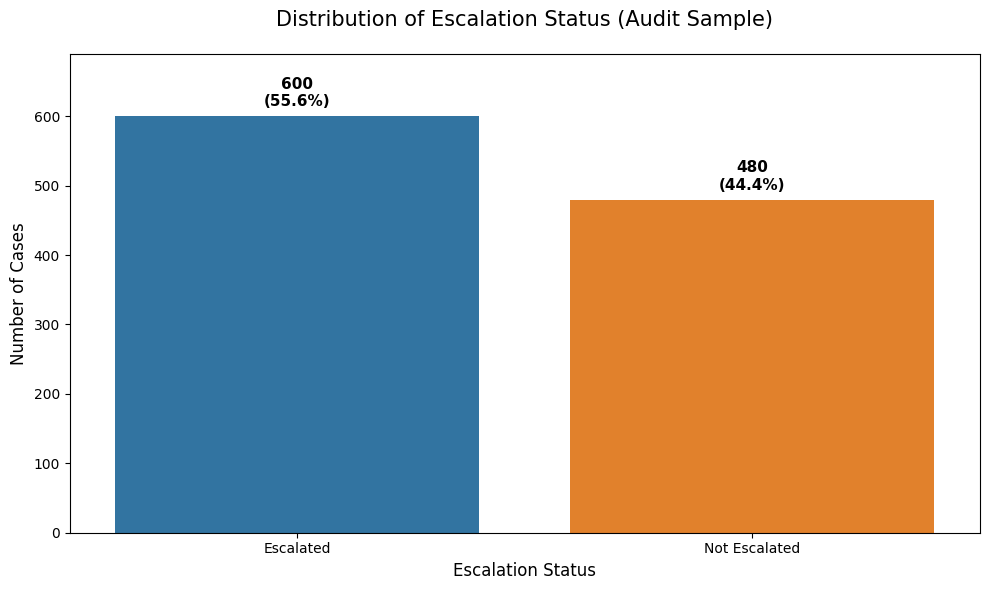

In [245]:
audit_sample_plot = audit_sample_compliance.copy()

# Create escalation flag
audit_sample_plot["escalation_flag"] = np.where(
    audit_sample_plot["ops_disposition"] == "Escalate",
    "Escalated",
    "Not Escalated"
)

# Calculate counts and percentages
escalation_counts = audit_sample_plot["escalation_flag"].value_counts(dropna=False).reset_index()
escalation_counts.columns = ["Label", "Count"]

total = escalation_counts["Count"].sum()
escalation_counts["Percentage"] = (escalation_counts["Count"] / total) * 100

# Sort descending
escalation_counts = escalation_counts.sort_values(by="Count", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Label", y="Count", data=escalation_counts, hue="Label", legend=False)

# Add annotations
for p in ax.patches:
    percentage = f'{(100 * p.get_height() / total):.1f}%'
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f'{count}\n({percentage})',
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Formatting
plt.title("Distribution of Escalation Status (Audit Sample)", fontsize=15, pad=20)
plt.xlabel("Escalation Status", fontsize=12)
plt.ylabel("Number of Cases", fontsize=12)
plt.ylim(0, escalation_counts["Count"].max() * 1.15)
plt.tight_layout()

print(escalation_counts)

In [246]:
audit_sample_compliance.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month', 'is_high', 'is_escalated',
       'under_escalation_flag', 'over_escalation_flag',
       'policy_adherence_flag', 'sop_deviation_flag_compliance',
       'documentation_present_flag_compliance', 'compliance_status_compliance',
       'evidence_missing_flag', 'escalation_integrity_flag', 'txn_count',
       'transaction_reconstruction_flag'],
      dtype='object')

In [247]:
audit_sample_compliance = audit_sample_compliance.drop(
    columns=["txn_count", "txn_count_x", "txn_count_y"],
    errors="ignore"
)

txn_count = (
    transactions_case_view.groupby("case_id")["txn_id"]
    .count()
    .reset_index()
    .rename(columns={"txn_id": "txn_count"})
)

audit_sample_compliance = audit_sample_compliance.merge(
    txn_count,
    on="case_id",
    how="left"
)

audit_sample_compliance["transaction_reconstruction_flag"] = np.where(
    (audit_sample_compliance["ops_disposition"] == "Escalate") &
    (audit_sample_compliance["txn_count"] > 0),
    1,
    np.where(audit_sample_compliance["ops_disposition"] == "Escalate", 0, np.nan)
)

## **Control Effectiveness Rating**

In [248]:
# 6. Control effectiveness
audit_sample_compliance["control_effectiveness_flag"] = np.where(
    (audit_sample_compliance["evidence_missing_flag"] == 0) &
    (audit_sample_compliance["under_escalation_flag"] == 0) &
    (audit_sample_compliance["over_escalation_flag"] == 0) &
    (audit_sample_compliance["policy_adherence_flag"] == 1),
    1,
    0
)

In [249]:
audit_sample_compliance["control_effectiveness_rating"] = np.select(
    [
        audit_sample_compliance["evidence_missing_flag"] == 1,
        audit_sample_compliance["control_effectiveness_flag"] == 1
    ],
    [
        "Unable to verify",
        "Effective"
    ],
    default="Deficient"
)

In [250]:
audit_sample_compliance.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,...,policy_adherence_flag,sop_deviation_flag_compliance,documentation_present_flag_compliance,compliance_status_compliance,evidence_missing_flag,escalation_integrity_flag,transaction_reconstruction_flag,txn_count,control_effectiveness_flag,control_effectiveness_rating
0,CASE_CUST006732_20240125,2026-03-18 14:05:08.365468,CUST006732,2024-01-25,High,Escalate,2.425532,10.316898,Significant,Significant,...,1,0,1,Compliant,0,1,1.0,6.0,1,Effective
1,CASE_CUST006164_20240111,2026-03-18 14:05:08.365468,CUST006164,2024-01-11,High,Escalate,0.750000,2.541836,Normal,Significant,...,1,0,1,Compliant,0,1,1.0,1.0,1,Effective
2,CASE_CUST008327_20240111,2026-03-18 14:05:08.365468,CUST008327,2024-01-11,High,Escalate,1.142857,2.108189,Normal,Significant,...,1,0,1,Compliant,0,1,1.0,2.0,1,Effective
3,CASE_CUST004896_20240112,2026-03-18 14:05:08.365468,CUST004896,2024-01-12,High,Escalate,2.200000,1.889363,Significant,Elevated,...,1,0,1,Compliant,0,1,1.0,5.0,1,Effective
4,CASE_CUST004251_20240129,2026-03-18 14:05:08.365468,CUST004251,2024-01-29,High,Escalate,2.086957,1.098086,Significant,Normal,...,1,0,1,Compliant,0,1,1.0,3.0,1,Effective


In [251]:
audit_sample_compliance.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month', 'is_high', 'is_escalated',
       'under_escalation_flag', 'over_escalation_flag',
       'policy_adherence_flag', 'sop_deviation_flag_compliance',
       'documentation_present_flag_compliance', 'compliance_status_compliance',
       'evidence_missing_flag', 'escalation_integrity_flag',
       'transaction_reconstruction_flag', 'txn_count',
       'control_effectiveness_flag', 'control_effectiveness_rating'],
      dtype='object')

In [252]:
control_effectiveness_rate = (
    (audit_sample_compliance["control_effectiveness_rating"] == "Effective").mean()
)

print("control_effectiveness_rate:", control_effectiveness_rate)

control_effectiveness_rate: 1.0


## **Documentation Sufficiency**

In [253]:
documentation_sufficiency_rate = (
    audit_sample_compliance["documentation_present_flag_compliance"].fillna(0).mean()
)

print("documentation_sufficiency_rate:", documentation_sufficiency_rate)

documentation_sufficiency_rate: 1.0


## **Audit Summary**

In [254]:
audit_summary = pd.DataFrame({
    "Metric": [
        "Escalation Rate",
        "Under Escalation Rate",
        "Over Escalation Rate",
        "Evidence Missing Rate",
        "Documentation Sufficiency Rate",
        "Transaction Reconstruction Rate",
        "Policy Adherence Rate",
        "Escalation Integrity Rate",
        "Effective Control Rate",
        "Unable to Verify Rate",
        "Deficient Control Rate"
    ],
    "Rate": [
        (audit_sample_compliance["ops_disposition"] == "Escalate").mean(),
        audit_sample_compliance["under_escalation_flag"].mean(),
        audit_sample_compliance["over_escalation_flag"].mean(),
        audit_sample_compliance["evidence_missing_flag"].mean(),
        audit_sample_compliance["documentation_present_flag_compliance"].fillna(0).mean(),
        audit_sample_compliance["transaction_reconstruction_flag"].mean(),
        audit_sample_compliance["policy_adherence_flag"].mean(),
        audit_sample_compliance["escalation_integrity_flag"].mean(),
        (audit_sample_compliance["control_effectiveness_rating"] == "Effective").mean(),
        (audit_sample_compliance["control_effectiveness_rating"] == "Unable to verify").mean(),
        (audit_sample_compliance["control_effectiveness_rating"] == "Deficient").mean()
    ]
})

audit_summary["Rate (%)"] = (audit_summary["Rate"] * 100).round(2)
audit_summary

,Metric,Rate,Rate (%)
0,Escalation Rate,0.555556,55.56
1,Under Escalation Rate,0.000000,0.00
2,Over Escalation Rate,0.000000,0.00
3,Evidence Missing Rate,0.000000,0.00
4,Documentation Sufficiency Rate,1.000000,100.00
5,Transaction Reconstruction Rate,1.000000,100.00
6,Policy Adherence Rate,1.000000,100.00
7,Escalation Integrity Rate,1.000000,100.00
8,Effective Control Rate,1.000000,100.00
9,Unable to Verify Rate,0.000000,0.00


### **Auditor Checking: Asses audit sample Review**

This should be done to asses if the compliance have done all their role (internal Control Effectiveness).

In [255]:
audit_sample.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month', 'is_high', 'is_escalated',
       'under_escalation_flag', 'over_escalation_flag',
       'policy_adherence_flag'],
      dtype='object')

In [256]:
audit_sample.shape

(1080, 18)

In [257]:
audit_sample[["suspiciousness_label","ops_disposition"]].value_counts()

suspiciousness_label  ops_disposition
High                  Escalate           600
Medium                Under review       360
Low                   Dismiss            120
Name: count, dtype: int64

In [258]:
escalated_cases = ops_case_log[
    ops_case_log["ops_disposition"] == "Escalate"
]

non_escalated_cases = ops_case_log[
    ops_case_log["ops_disposition"] != "Escalate"
]

In [259]:
audit_sample[["suspiciousness_label", "ops_disposition"]].isna().mean()

suspiciousness_label    0.0
ops_disposition         0.0
dtype: float64

In [260]:
audit_sample[["suspiciousness_label", "ops_disposition"]].value_counts(dropna=False)

suspiciousness_label  ops_disposition
High                  Escalate           600
Medium                Under review       360
Low                   Dismiss            120
Name: count, dtype: int64

## **Traceability Verification (Evidence-Based)**

In [261]:
audit_review_log = audit_sample_compliance.copy()

In [262]:
audit_review_log.columns

Index(['case_id', 'case_created_at', 'client_id', 'date',
       'suspiciousness_label', 'ops_disposition', 'ratio_velocity',
       'ratio_value', 'velocity_severity', 'value_severity', 'auto_red_flag',
       'ops_rules', 'month', 'is_high', 'is_escalated',
       'under_escalation_flag', 'over_escalation_flag',
       'policy_adherence_flag', 'sop_deviation_flag_compliance',
       'documentation_present_flag_compliance', 'compliance_status_compliance',
       'evidence_missing_flag', 'escalation_integrity_flag',
       'transaction_reconstruction_flag', 'txn_count',
       'control_effectiveness_flag', 'control_effectiveness_rating'],
      dtype='object')

In [263]:
audit_review_log.head()

,case_id,case_created_at,client_id,date,suspiciousness_label,ops_disposition,ratio_velocity,ratio_value,velocity_severity,value_severity,...,policy_adherence_flag,sop_deviation_flag_compliance,documentation_present_flag_compliance,compliance_status_compliance,evidence_missing_flag,escalation_integrity_flag,transaction_reconstruction_flag,txn_count,control_effectiveness_flag,control_effectiveness_rating
0,CASE_CUST006732_20240125,2026-03-18 14:05:08.365468,CUST006732,2024-01-25,High,Escalate,2.425532,10.316898,Significant,Significant,...,1,0,1,Compliant,0,1,1.0,6.0,1,Effective
1,CASE_CUST006164_20240111,2026-03-18 14:05:08.365468,CUST006164,2024-01-11,High,Escalate,0.750000,2.541836,Normal,Significant,...,1,0,1,Compliant,0,1,1.0,1.0,1,Effective
2,CASE_CUST008327_20240111,2026-03-18 14:05:08.365468,CUST008327,2024-01-11,High,Escalate,1.142857,2.108189,Normal,Significant,...,1,0,1,Compliant,0,1,1.0,2.0,1,Effective
3,CASE_CUST004896_20240112,2026-03-18 14:05:08.365468,CUST004896,2024-01-12,High,Escalate,2.200000,1.889363,Significant,Elevated,...,1,0,1,Compliant,0,1,1.0,5.0,1,Effective
4,CASE_CUST004251_20240129,2026-03-18 14:05:08.365468,CUST004251,2024-01-29,High,Escalate,2.086957,1.098086,Significant,Normal,...,1,0,1,Compliant,0,1,1.0,3.0,1,Effective


Audit verification confirms that:
- Detection and labeling logic is executed exclusively within the first line.
- Risk management reviews outcomes only at an aggregated level.
- Compliance activities are limited to documentation and process oversight.
- Internal audit performs sampling-based assurance without operational involvement.


**Internal audit Finding**

Based on sampling-based verification, the monitoring and escalation processoperates as designed. 

Escalation outcomes are traceable, consistently applied, and supported by appropriate documentation. No evidence of role overlap or control breakdown was observed within the audit scope.


## **Output dataset – 3LoD Internal Audit**

``audit_review_log``
(Audit evaluation dataset documenting control testing results, sampling validation outcomes, and cross-line consistency checks.)

This dataset does not perform anomaly detection or operational monitoring.
Its purpose is to independently assess whether the control framework across 1LoD and 2LoD is functioning effectively.

## **Output artefact:**
Audit findings report & assurance documentation.


``2LoD / 1LoD → 3LoD (Independent Assurance Transformation)``

## **2LoD / 1LoD → 3LoD (Independent Assurance Transformation)**

| Dimension                | Operational & Oversight Layers     | Internal Audit View (`audit_review_log`) | Structural Change         |
| ------------------------ | ---------------------------------- | ---------------------------------------- | ------------------------- |
| **Granularity**          | Case-level & aggregated trend      | Sampled case-level review                | Case → Sample             |
| **Rows**                 | 1,106,264 cases                    | Sampled subset                           | Risk-based sampling       |
| **Columns**              | Decision & oversight metrics       | Control testing attributes & audit notes | Assurance annotation      |
| **Baseline Fields**      | Not accessible by default          | Reviewed through documentation           | Independent validation    |
| **Computation Layer**    | None                               | Reperformance testing (sample-based)     | Control verification      |
| **Interpretation Layer** | Disposition & oversight assessment | Effectiveness evaluation                 | Assurance shift           |
| **Traceability**         | Reduced                            | Conditional traceability via sampling    | Controlled reconstruction |


## **GAP vs Raw IT – 3LoD Internal Audit**

- No unrestricted raw IT access

- Dependent on structured data requests

- Limited full population re-performance

- Reconstruction required for deep validation

- Assurance constrained by information minimisation boundaries

**Although Internal Audit retains the right to access all necessary information for assurance purposes, transaction-level access is not granted by default. Reconstruction occurs through a formal, request-based mechanism governed by role-based controls and privacy constraints. In theory, 3LoD has unrestricted access rights.**

**In practice, operational data silos, privacy controls, and organisational resistance introduce structural friction, resulting in delayed reconstruction and assurance bottlenecks.**

## **Final Table: Mapping & Share Level Informations for Simulation**

| Line of Defense                          | Function                                                       | Dataset / Artefact                                   | Key Information Included                                                                  | Share Level    | Purpose in the GRC Simulation                                                                                                                                          |
| ---------------------------------------- | -------------------------------------------------------------- | ---------------------------------------------------- | ----------------------------------------------------------------------------------------- | -------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1LoD – IT (Core Banking)**             | Maintain raw operational systems and data infrastructure.      | `transactions`, `customers`                          | Transaction records, customer attributes, timestamps, transaction channels                | **Restricted** | Serves as the primary source of truth for operational activities. Raw data remains restricted due to privacy and operational integrity requirements.                   |
| **1LoD – Data Operations**               | Data preparation and analytical enablement. No risk ownership. | `customer_day`                                       | Aggregated daily metrics, baseline transaction behavior, deviation ratios                 | **Restricted** | Transforms transaction-level data into monitoring indicators used to detect abnormal behavioural patterns without applying operational judgment.                       |
| **1LoD – Business Operations**           | Perform operational monitoring and case triage.                | `customer_day_operational`                           | Ratio indicators, severity classifications, monitoring flags                              | **Restricted** | Uses monitoring indicators to identify potentially suspicious transaction patterns and initiate operational investigation workflows.                                   |
| **1LoD – Business Operations**           | Case documentation and escalation management.                  | `ops_case_log`, `ops_case_reviewed`                  | `case_id`, suspiciousness labels, operational dispositions, rule explanations             | **Restricted** | Maintains formal records of monitoring outcomes and operational decisions such as escalation, review, or dismissal of cases.                                           |
| **1LoD – Business Operations / DataOps** | Transaction-level drill-down for escalated investigations.     | `transactions_case_view`, `transactions_case_linked` | Transaction-level records linked to case identifiers                                      | **Controlled** | Provides event-level transaction context for escalated cases, enabling deeper investigation and traceability while maintaining role-based access boundaries.           |
| **2LoD – Risk Management**               | Independent risk oversight and population-level monitoring.    | `lod2_risk_dashboard`                                | Aggregated case statistics, escalation ratios, trend indicators                           | **Shared**     | Enables risk teams to monitor systemic patterns and escalation trends without accessing detailed operational transaction data.                                         |
| **2LoD – Compliance**                    | Governance oversight and policy validation.                    | `lod2_compliance_review_log`                         | SOP deviation flags, documentation completeness, compliance status                        | **Shared**     | Reviews operational handling of cases to ensure adherence to policies, escalation procedures, and documentation standards.                                             |
| **3LoD – Internal Audit**                | Independent assurance and control effectiveness assessment.    | `audit_sample`, `audit_summary`                      | Sampled cases, escalation flags, compliance review results, control effectiveness metrics | **Restricted** | Performs independent verification of escalation decisions, traceability reconstruction, and control effectiveness testing across the monitoring and oversight process. |


| Dimension         | Raw IT      | DataOps           | Business Ops     | Risk               | Compliance              | Audit                      | Structural Effect            |
| ----------------- | ----------- | ----------------- | ---------------- | ------------------ | ----------------------- | -------------------------- | ---------------------------- |
| **Granularity**        | Event-level | Customer-day      | Indicator-level  | Aggregated summary | Documentation-based     | Conditional event access   | Abstraction gradient         |
| **Row Count**         | N₁ (transactions) | N₂ (customer-days)     | N₂ (same as DataOps view)                    | N₂             | N₂                 | Sample-based   | Event collapse               |
| **Column Count**      | C₁ (full schema)  | C₂ (engineered subset) | C₃ (operational view) | Limited        | Limited            | Conditional    | Context compression   
| **Data Sensitivity**  | Full PII    | PII removed       | No PII           | No PII             | No PII                  | Conditional                | Privacy–visibility trade-off |
| **Traceability**      | Full        | Reduced           | Case-linked only | No event-level     | No event-level          | Conditional reconstruction | Reconstruction dependency    |
| **Decision Autonomy** | Full        | Computation only  | Limited          | Oversight only     | Process validation only | Sampling-based             | Autonomy asymmetry           |
| **Computation Layer** | None        | Baseline + Ratios | None             | None               | None                    | None                       | Technical centralisation     |


## **AS-IS Process Evaluation Matrices:**

### **1. Granularity & Abstraction Matrix**

``(Data Flow Compression & Visibility Loss)``

**This matrix evaluates:**

1. How raw event-level data is abstracted

2. How much dimensional reduction occurs

3. How information visibility changes across lines

4. It measures structural transformation, not performance.

**What It Quantifies:**

### **A. Granularity Compression Ratio**

$$Granularity\ Compression = \frac{Customer\text{-}day\ records}{Transaction\ records}$$

**In this simulation:**

$$GC = \frac{1,106,264}{1,551,068} \approx 0.71$$

**Meaning:**

1. 29% structural compression foe processing efficiency
2. Governance system in the AS-IS process is sucessfully consolidate the data raw into operational level without lossing customer identity and transaction time line → Event-level activity is abstracted into aggregated behavioral indicators.

### **B. Field Reduction Ratio**

$$Field\ Reduction =\frac{BusinessOps}{Raw IT}$$

**In this simulation:**

$$Field\ Reduction =\frac{10}{13}$$


> This from the data flow and attribute dimension reduction:
> **``Raw IT (13 fields) → DataOps (12 engineered) → BusinessOps (10 visible)``**

**Meaning:**
Role-based visibility enforcement through attribute abstraction.

### **C. Visibility Loss Index (Qualitative but Structural)**

| Layer       | Event-level Access |
| ----------- | ------------------ |
| Raw IT      | Full               |
| DataOps     | Removed            |
| BusinessOps | None               |
| Risk        | None               |
| Compliance  | None               |
| Audit       | Conditional        |

> **This shows information gradient across lines.**

The first Matrices d not show model accuracy but **data abstraction depth, Information minimisation, Governance layering**


### **2. Escalation & Workload Matrix**

``(Operational Pressure & Investigation Expansion)``

**This matrix evaluates:**

1. How often aggregated indicators trigger escalation

2. How much investigation expands from abstraction back to event-level


**What It Quantifies:**

### **A. Escalation Rate**

$$Escalation\ Rate =\frac{Escalated\ Cases}{Total\ Cases}$$

**In this simulation:**

```
Number of escalated cases = 166,916

Total monitored cases = 1,106,264

Escalation Rate ≈ 15.09% 

```

**Meaning:**
15% of monitored customer-days require deeper human intervention for further judgement.

**Interpretation**

**1. Structural autonomy limitation indicator**
A significant increase in the Escalation Rate (e.g., from 5% to 20%) may signal abnormal behavioral shifts or external stress factors affecting transaction patterns.

**2. Abstraction sufficiency signal**
A persistently high escalation rate suggests potential over-sensitivity of threshold rules, increasing operational burden and potentially leading to alert fatigue.

**3. Audit Traceability**
The Escalation Rate provides transparency into governance flow by quantifying how many cases require human intervention versus those resolved through automated triage.


### **B. Amplification Ratio**

$$Amplification\ Ratio = \frac{Transaction\text{-}level\ records\ reviewed}{Escalated\ cases}$$

**In this simulation:**

```
Number of escalated cases = 166,916

Number of transaction-level records generated from escalated cases = 325,781

```
The ratio of approximately ``1.95`` indicates moderate amplification: each escalated customer-day results in nearly two transaction-level records requiring detailed review.


### **C. Transaction Reconstruction Share**

$$Transaction\ Reconstruction\ Share = \frac{Transaction\text{-}level\ records\ reviewed}{Total\ transaction\ records (case level)}$$

**In this simulation:**

```
Transaction-level records reviewed = 325,781

Traceability mapping linking transaction records to case-level= 1,551,068
```

$$\frac{325,781}{1,551,068}≈ 21%$$

**Meaning:**

``21%`` of total transaction records are indirectly reconstructed due to escalation.




### **3. Inefficiency (Structural Bottleneck) Indicators**

``(Governance Inefficiency & Dependency Loops)``

**This matrix is the most important:**
> Because this is where synthetic data later becomes relevant.


**What It Quantifies:**

### **A. Escalation Dependency Loop**

**Data FLow in the AS-IS Process Simulation:**

``customer_day → ops_case_log → (if escalate) → IT request → transactions_case_view → review
→ potential 2LoD consultation``

> That is a multi-layer dependency chain.


### **B. Handoff Count**

**Operational escalation requires:**

```
BusinessOps → IT/DataOps → Risk/Compliance

```

>Minimum 2–3 formal transitions.

Each transition introduces:

* waiting time → queue when Business Ops need further data forr deeper analysis
* coordination overhead
* waiting time accumulation (latency)


### **C. Reconstruction Dependency Ratio**

$$RDR = \frac{N_{escalated\_cases}}{N_{total\_cases\_evaluated}}$$


**In this simulation:**

$$RDR = \frac{\text{Cases Requiring Structural Reconstruction}}{\text{Total Operational Cases}}$$


```
Number of escalated cases = 166,916

Total monitored cases = 1,106,264

```
$$\frac{166,916}{1,106,264}≈ 15.09%$$

**Meaning:**

**The Reconstruction Dependency Ratio (RDR)** is derived from escalation data. However, when explaining RDR in formal documents, it is important to clarify the operational "dependence" on raw data or technical assistance.

Escalation refers to the action taken (who does it), while Reconstruction Dependency describes the condition (why it is done). This ratio illustrates Layer Abstraction Failure. The figure of 15.09% indicates that in 15% of cases, the information layer provided by the model fails to yield a direct answer, necessitating manual reconstruction by humans.


## **AS-IS Performance & Inefficiency Matrix Summary**

| Category          | Metric              | Value      | Governance Implication  |
| ----------------- | ------------------- | ---------- | ----------------------- |
| Granularity       | Compression Ratio   | 0.71       | Event abstraction → Abstraction-induced information asymmetry       |
| Data Minimisation | Field Reduction     | 13 → 10    | Role-based visibility → Contextual capability reduction  |
| Escalation        | Escalation Rate     | 15.09%     | Operational pressure → Limited decision autonomy at aggregated layer   |
| Workload          | Amplification Ratio | 1.95       | Investigation expansion → Cross-layer analytical expansion|
| Reconstruction    | Transaction Share   | 21%        | Drill-down burden → Dependency on raw data re-access      |
| Dependency        | Handoff Count       | 2–3 layers | Structural bottleneck → Inter-line coordination friction    |


## **AS-IS Simulation Limitation**
---
* Simulation-based with one case

* Deterministic rule engine → there is not showing noise

* No human behavioral modelling

* No latency measurement (structural, not temporal)

* No financial cost modelling


This simulation represents a structural modelling exercise of a single governance configuration and does not aim for statistical generalisability across institutions. The purpose is to examine structural information asymmetry and data flow abstraction rather than empirical industry performance.

The monitoring logic is implemented as a deterministic rule-based engine. Stochastic variability, human judgement overrides, and behavioural adaptation are intentionally excluded in order to isolate structural data flow characteristics.

Human cognitive processes, discretionary judgement, and inter-personal collaboration dynamics are not modelled. The focus remains on structural dependency between layers rather than behavioural effectiveness.

Bottleneck identification is conceptualised structurally rather than temporally. The simulation does not measure processing time, queue length, or operational delay. Instead, bottleneck intensity is inferred from dependency loops, handoff frequency, and reconstruction necessity.

Financial cost implications are not quantified. The analysis highlights structural inefficiency patterns without translating them into monetary impact.


**The identified bottlenecks are not due to inadequate detection, but rather to a structural dependence on raw data visibility—in line with the objectives of this research. This paves the way for evaluating whether synthetic data layers can reduce process bottlenecks without compromising privacy.**

## **Print Document**
---
**Customer-day**
Customer-day level monitoring dataset containing aggregated transaction indicators such as transaction velocity, transaction value ratios, and severity classifications used to detect suspicious transaction behaviour.

In [264]:
customer_day.to_csv(r'D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/customer_day.csv', index=False)